# **NLP Feature Engineering Part 2: Model-Based Semantic Signals**

**Project**: Airbnb Market Segmentation Analysis
**Goal**: Extend the candidate feature set built in Part 1 with model-based semantic signals (sentiment, topic modeling, and multilingual embeddings) to test whether text captures structure beyond surface-level stylometry and lexicons, using a shared, capped review sample to keep the heavier phases computationally feasible.

## 1. Imports & environment setup

In [1]:
import pandas as pd
import numpy as np
import re
import html

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# Base path configuration
BASE_PATH = Path.cwd().parent

In [3]:
DEVICE = 'mps' # torch.backends.mps.is_available()

## 2. Data Loading

In [4]:
listings_nlp = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'listings_extended.csv')
reviews_nlp = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'reviews_extended.csv')

#### 2.1 Listings dataframe

In [5]:
listings_nlp.shape

(35818, 282)

In [6]:
listings_nlp.info()

<class 'pandas.DataFrame'>
RangeIndex: 35818 entries, 0 to 35817
Columns: 282 entries, id to review_transport_density_log
dtypes: float64(170), int64(38), str(74)
memory usage: 77.1 MB


In [7]:
listings_nlp.describe(include = 'all')

,id,host_id,host_response_time,host_response_rate_raw,host_acceptance_rate_raw,host_is_superhost,host_neighbourhood,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,...,review_luxury_density_log,review_family_density_log,review_budget_density_log,review_romantic_density_log,review_authenticity_density_log,review_atmosphere_quiet_density_log,review_atmosphere_lively_density_log,description_transport_density_log,neighborhood_overview_transport_density_log,review_transport_density_log
count,3.581800e+04,3.581800e+04,35818,29444.000000,32319.000000,35818.000000,35818,35818.000000,35818.000000,35818,...,30286.000000,30286.000000,30286.000000,30286.000000,30286.000000,30286.000000,30286.000000,34854.000000,16442.000000,30286.000000
unique,NaN,NaN,5,NaN,NaN,NaN,100,NaN,NaN,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,within an hour,NaN,NaN,NaN,Unknown,NaN,NaN,I Centro Storico,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,25098,NaN,NaN,NaN,24751,NaN,NaN,17537,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,7.541191e+17,2.666308e+08,NaN,0.966612,0.926700,0.399213,NaN,0.939835,0.919063,NaN,...,0.079051,0.104405,0.338749,0.044385,0.350659,0.246099,0.397248,0.447312,0.388195,0.305969
std,5.746268e+17,2.439774e+08,NaN,0.136872,0.201959,0.489743,NaN,0.237796,0.272742,NaN,...,0.155806,0.179290,0.292853,0.098787,0.271717,0.270789,0.298284,0.577298,0.573619,0.266280
min,1.183400e+04,2.353000e+03,NaN,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.020579e+07,3.129867e+07,NaN,1.000000,0.980000,0.000000,NaN,1.000000,1.000000,NaN,...,0.000000,0.000000,0.147337,0.000000,0.184010,0.000000,0.199153,0.000000,0.000000,0.100693
50%,9.565242e+17,1.901475e+08,NaN,1.000000,1.000000,0.000000,NaN,1.000000,1.000000,NaN,...,0.020688,0.011195,0.316052,0.000000,0.342217,0.185378,0.379329,0.000000,0.000000,0.282696
75%,1.271719e+18,5.070057e+08,NaN,1.000000,1.000000,1.000000,NaN,1.000000,1.000000,NaN,...,0.096779,0.151850,0.460776,0.057309,0.472735,0.363167,0.555708,0.870875,0.790728,0.444144


#### 2.2 Reviews dataframe

In [8]:
reviews_nlp.shape

(2125661, 7)

In [9]:
reviews_nlp.info()

<class 'pandas.DataFrame'>
RangeIndex: 2125661 entries, 0 to 2125660
Data columns (total 7 columns):
 #   Column                 Dtype
---  ------                 -----
 0   listing_id             int64
 1   date                   str  
 2   reviewer_id            int64
 3   comments_clean         str  
 4   review_length          int64
 5   is_substantive_review  int64
 6   review_lang            str  
dtypes: int64(4), str(3)
memory usage: 113.5 MB


In [10]:
reviews_nlp.describe(include = 'all')

,listing_id,date,reviewer_id,comments_clean,review_length,is_substantive_review,review_lang
count,2.125661e+06,2125661,2.125661e+06,2125661,2.125661e+06,2.125661e+06,2125661
unique,NaN,5237,NaN,2058951,NaN,NaN,71
top,NaN,2025-06-15,NaN,unknown,NaN,NaN,en
freq,NaN,2978,NaN,4026,NaN,NaN,1243126
mean,2.776781e+17,NaN,1.992211e+08,NaN,2.687609e+02,9.981060e-01,NaN
std,4.492048e+17,NaN,1.838722e+08,NaN,2.405071e+02,4.347888e-02,NaN
min,1.183400e+04,NaN,4.600000e+01,NaN,0.000000e+00,0.000000e+00,NaN
25%,9.904914e+06,NaN,4.595313e+07,NaN,1.030000e+02,1.000000e+00,NaN
50%,2.902630e+07,NaN,1.349746e+08,NaN,2.050000e+02,1.000000e+00,NaN
75%,6.570888e+17,NaN,3.242151e+08,NaN,3.600000e+02,1.000000e+00,NaN


## 3. Shared Review Sample

Reviews are capped at 30 per listing via random sampling with a fixed seed, not by recency or quality, to stay representative of a listing's review history. Listings with 30 or fewer substantive reviews keep all of them. This single `reviews_sampled` dataframe is built once here and reused unchanged across sentiment, topic modeling, and embeddings, so a listing's scores across all three phases come from the same underlying text, not three independently drawn samples.

In [11]:
REVIEW_CAP = 30
RANDOM_SEED = 42

substantive_mask = reviews_nlp['is_substantive_review'] == 1
substantive_reviews = reviews_nlp.loc[substantive_mask].copy()

reviews_sampled = (
    substantive_reviews
    .sample(frac=1, random_state=RANDOM_SEED)  # shuffle the whole frame once, reproducibly
    .groupby('listing_id', group_keys=False)
    .head(REVIEW_CAP)  # first N after a full shuffle == a random sample of up to N per group
    .reset_index(drop=True)
)

print(f"substantive reviews (full corpus): {len(substantive_reviews):,}")
print(f"reviews_sampled (capped at {REVIEW_CAP}): {len(reviews_sampled):,} "
      f"({len(reviews_sampled)/len(substantive_reviews)*100:.1f}% of substantive corpus)")
print(f"listings covered: {reviews_sampled['listing_id'].nunique():,}")

reviews_per_listing_capped = reviews_sampled.groupby('listing_id').size()
print(f"\nreviews per listing after capping — min: {reviews_per_listing_capped.min()}, "
      f"median: {reviews_per_listing_capped.median()}, max: {reviews_per_listing_capped.max()}")

substantive reviews (full corpus): 2,121,635
reviews_sampled (capped at 30): 604,821 (28.5% of substantive corpus)
listings covered: 30,713

reviews per listing after capping — min: 1, median: 28.0, max: 30


## 4. Sentiment Analysis

Numeric review scores (`review_scores_*`) suffer from a ceiling effect, leaving almost no separation between listings on this axis. Review text is the only remaining source of graded variation. This section extracts a continuous sentiment signal from `reviews_sampled` via `nlptown/bert-base-multilingual-uncased-sentiment`, chosen over translation-dependent alternatives for its closer register match (product/service reviews) and native coverage of the project's main languages. Per-review star predictions are aggregated to listing level (mean/std/%negative/trend), followed by a corpus-bootstrapped complaint lexicon and lightweight aspect-anchored sentiment.

### 4.1 Language Coverage Check

Before running inference on the full sample, actual language coverage on `reviews_sampled` is checked directly. `nlptown` covers English, Dutch, German, French, Spanish, Italian; anything else falls outside its trained coverage and will be marked `unavailable`.

In [12]:
NLPTOWN_LANGS = {'en', 'nl', 'de', 'fr', 'es', 'it'}

lang_counts = reviews_sampled['review_lang'].value_counts()
lang_pct = reviews_sampled['review_lang'].value_counts(normalize=True).mul(100).round(2)

lang_coverage = pd.DataFrame({'count': lang_counts, 'pct': lang_pct})
lang_coverage['covered_by_nlptown'] = lang_coverage.index.isin(NLPTOWN_LANGS)

display(lang_coverage.head(20))

covered_pct = lang_coverage.loc[lang_coverage['covered_by_nlptown'], 'pct'].sum()
print(f"\nTotal coverage by nlptown model: {covered_pct:.1f}% of reviews_sampled")
print(f"Falls outside coverage (incl. Russian, too_short, unknown): {100 - covered_pct:.1f}%")

,count,pct,covered_by_nlptown
review_lang,,,
en,316472,52.32,True
it,69595,11.51,True
es,56033,9.26,True
fr,54753,9.05,True
too_short,40098,6.63,False
de,21677,3.58,True
pt,11978,1.98,False
nl,5104,0.84,True
ko,4673,0.77,False



Total coverage by nlptown model: 86.6% of reviews_sampled
Falls outside coverage (incl. Russian, too_short, unknown): 13.4%


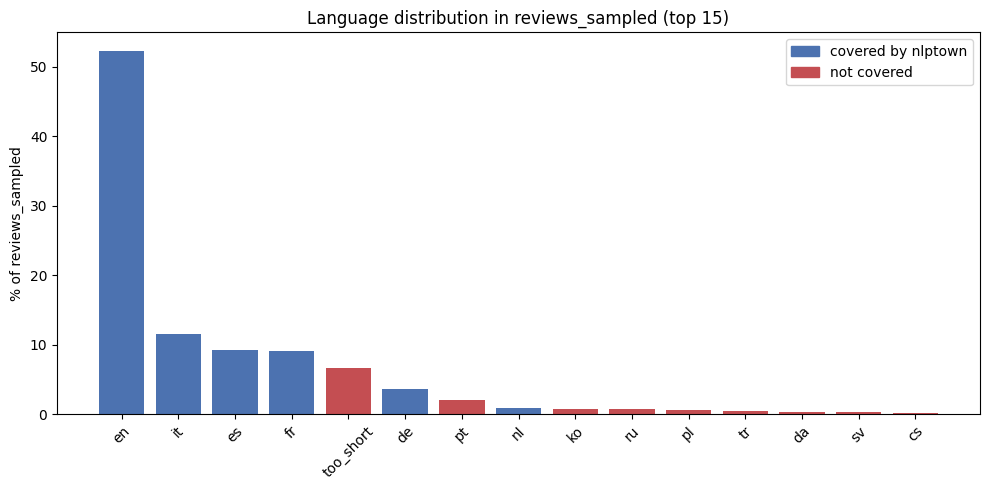

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
top15 = lang_coverage.head(15)
colors_lang = ['#4c72b0' if covered else '#c44e52' for covered in top15['covered_by_nlptown']]
ax.bar(top15.index, top15['pct'], color=colors_lang)
ax.set_ylabel('% of reviews_sampled')
ax.set_title('Language distribution in reviews_sampled (top 15)')
ax.tick_params(axis='x', rotation=45)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4c72b0', label='covered by nlptown'),
                    Patch(color='#c44e52', label='not covered')])
plt.tight_layout()
plt.show()

**Observations:**

86.6% coverage confirms `nlptown` is a solid choice without needing a second model. The single largest "not covered" bucket isn't a missing language at all: `too_short` (6.63%) reflects the same detection-reliability limit already documented throughout this project (texts under 5 words), not a gap in the sentiment model's training. Among genuine language gaps, Portuguese is the largest at just 1.98%, followed by Russian at 0.73%, both too small to justify adding a second model with an incompatible output scale just to cover them. All languages outside `nlptown`'s six are marked `unavailable`, consistent with every other language-limited method in this project.

### 4.2 Model Loading & Label Verification

Before trusting any star-weight mapping, the model's actual `id2label` ordering is checked directly on the loaded object.

In [14]:
import os
os.environ['HF_HUB_DISABLE_XET'] = '1'  # known, currently-broken Xet CAS backend — fall back to plain HTTP download

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "nlptown/bert-base-multilingual-uncased-sentiment"
HF_CACHE_DIR = BASE_PATH / 'models' / 'huggingface_cache'  

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir=HF_CACHE_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, cache_dir=HF_CACHE_DIR).to(DEVICE)
model.eval()

print(model.config.id2label)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2761.72it/s]


{0: '1 star', 1: '2 stars', 2: '3 stars', 3: '4 stars', 4: '5 stars'}


### 4.3 Sentiment Inference

Per-review sentiment is computed via expected value over the model's softmax probabilities (Σ i × P(star_i)), which uses the model's full confidence distribution instead of collapsing it to a single hard class, giving a genuinely continuous score for listing-level mean/std aggregation. The same continuous score is also thresholded into a `negative`/`neutral`/`positive` category, so both the star-comparison narrative (vs. `review_scores_rating`'s ceiling effect) and the standard %negative framing come from one model, one pass, not two separate methods.

Inference runs in chunks of 20,000 reviews, saved to disk incrementally with a `review_index` column tying each score back to its exact row in `reviews_sampled`.

In [15]:
STAR_WEIGHTS = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0]).to(DEVICE) 
model_fp16 = model.half()

def predict_sentiment_batch_fast(texts, batch_size=128, max_length=256):
    n = len(texts)
    order = sorted(range(n), key=lambda i: len(texts[i]))
    sorted_texts = [texts[i] for i in order]

    scores_sorted = [None] * n
    for start in range(0, n, batch_size):
        batch = sorted_texts[start:start + batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(DEVICE)
        with torch.inference_mode():
            logits = model_fp16(**inputs).logits
        probs = F.softmax(logits.float(), dim=-1)
        batch_scores = (probs * STAR_WEIGHTS).sum(dim=-1).cpu().tolist()
        for j, score in enumerate(batch_scores):
            scores_sorted[start + j] = score

    scores = [None] * n
    for sorted_idx, orig_idx in enumerate(order):
        scores[orig_idx] = scores_sorted[sorted_idx]
    return scores

def star_to_category(score, neg_max=2.5, pos_min=3.5):
    """Threshold a continuous star score into negative/neutral/positive."""
    if score <= neg_max:
        return 'negative'
    elif score >= pos_min:
        return 'positive'
    return 'neutral'

In [16]:
import os
import time

SENTIMENT_CHUNK_SIZE = 20_000
SENTIMENT_OUTPUT_DIR = BASE_PATH / 'data' / 'sentiment_chunks'
SENTIMENT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

n_chunks = (len(reviews_sampled) + SENTIMENT_CHUNK_SIZE - 1) // SENTIMENT_CHUNK_SIZE
print(f"{len(reviews_sampled):,} reviews -> {n_chunks} chunks of up to {SENTIMENT_CHUNK_SIZE:,} each")

for chunk_idx in range(n_chunks):
    chunk_path = SENTIMENT_OUTPUT_DIR / f'chunk_{chunk_idx:03d}.csv'
    if chunk_path.exists():
        continue 

    start_idx = chunk_idx * SENTIMENT_CHUNK_SIZE
    end_idx = min(start_idx + SENTIMENT_CHUNK_SIZE, len(reviews_sampled))
    chunk = reviews_sampled.iloc[start_idx:end_idx]

    chunk_start_time = time.time()
    scores = predict_sentiment_batch_fast(chunk['comments_clean'].tolist(), batch_size=128)
    chunk_elapsed = time.time() - chunk_start_time

    result = pd.DataFrame({
        'review_index': chunk.index, 
        'listing_id': chunk['listing_id'].values,
        'sentiment_star_score': scores,
    })
    result.to_csv(chunk_path, index=False)

    print(f"chunk {chunk_idx + 1}/{n_chunks} done in {chunk_elapsed/60:.1f} min "
          f"({(chunk_idx + 1) * SENTIMENT_CHUNK_SIZE / len(reviews_sampled) * 100:.1f}% overall)")

604,821 reviews -> 31 chunks of up to 20,000 each


In [17]:
SENTIMENT_OUTPUT_DIR = BASE_PATH / 'data' / 'sentiment_chunks'

chunk_files = sorted(SENTIMENT_OUTPUT_DIR.glob('chunk_*.csv'))
print(f"{len(chunk_files)} chunk files")

sentiment_results = pd.concat([pd.read_csv(f) for f in chunk_files], ignore_index=True)
print(f"total sentiment predictions: {len(sentiment_results):,}")
print(f"len of reviews_sampled: {len(reviews_sampled):,}")

assert len(sentiment_results) == len(reviews_sampled), "row count mismatch — investigate before merging"

31 chunk files
total sentiment predictions: 604,821
len of reviews_sampled: 604,821


In [18]:
# align sentiment_results to reviews_sampled via the saved review_index,
sentiment_results_sorted = sentiment_results.set_index('review_index').sort_index()
index_match = sentiment_results_sorted.index.equals(reviews_sampled.index.sort_values())
print(f"review_index fully covers reviews_sampled: {index_match}")

listing_id_check = (sentiment_results_sorted.loc[reviews_sampled.index, 'listing_id'].values == reviews_sampled['listing_id'].values).all()
print(f"listing_id alignment via review_index confirmed: {listing_id_check}")

review_index fully covers reviews_sampled: True
listing_id alignment via review_index confirmed: True


In [19]:
reviews_sampled['sentiment_star_score'] = sentiment_results_sorted.loc[reviews_sampled.index, 'sentiment_star_score'].values
reviews_sampled['sentiment_category'] = reviews_sampled['sentiment_star_score'].apply(star_to_category)

print(reviews_sampled[['listing_id', 'comments_clean', 'sentiment_star_score', 'sentiment_category']].head())
print(f"\nmissing sentiment scores: {reviews_sampled['sentiment_star_score'].isna().sum()}")

            listing_id                                     comments_clean  \
0  1075061930712172415  logement meublé avec beaucoup de raffinement e...   
1             29233493                                thank you! perfect.   
2   846441513382078199  the house is very cozy and tidy. we had a grea...   
3             12752762  非常好！房东非常热情，关于早上机场大巴的建议非常重要，房间每天打扫，早餐充足，响应迅速，床铺...   
4             18488106  stefano was a great host! he was flexible with...   

   sentiment_star_score sentiment_category  
0              4.232066           positive  
1              4.924446           positive  
2              4.389911           positive  
3              4.575414           positive  
4              4.887683           positive  

missing sentiment scores: 0


### 4.4 Listing-Level Aggregation

Four features are aggregated from the per-review scores in `reviews_sampled`: mean sentiment (overall tone), standard deviation (how much guests disagree — a listing with wildly mixed reviews is a different signal than one with uniformly moderate ones), percent negative (share of reviews below the negative threshold), and trend (whether sentiment is improving or declining over time). All four are computed only from each listing's valid (non-`unavailable`) reviews; listings with zero valid reviews get `NaN` throughout, consistent with the coverage gap just established.

Trend is computed as the slope of a simple linear regression of sentiment score against review order (sorted by date, oldest first) within each listing — a positive slope means sentiment has been improving over the listing's review history, negative means declining. This is left undefined (`NaN`) for listings with fewer than 3 valid, dated reviews, since a trend line through 1-2 points is not a meaningful signal.

In [20]:
reviews_sampled['sentiment_lang_covered'] = reviews_sampled['review_lang'].isin(NLPTOWN_LANGS)

reviews_sampled.loc[~reviews_sampled['sentiment_lang_covered'], 'sentiment_star_score'] = np.nan
reviews_sampled.loc[~reviews_sampled['sentiment_lang_covered'], 'sentiment_category'] = 'unavailable'

listing_review_counts = reviews_sampled.groupby('listing_id').size()
listing_sentiment_available = reviews_sampled.groupby('listing_id')['sentiment_star_score'].apply(lambda x: x.notna().sum())

n_listings_total = listing_review_counts.shape[0]
n_listings_zero_coverage = (listing_sentiment_available == 0).sum()
n_listings_full = (listing_sentiment_available == listing_review_counts).sum() 
n_listings_partial = n_listings_total - n_listings_zero_coverage - n_listings_full

print(f"total listings: {n_listings_total:,}")
print(f"listings with zero valid sentiment scores: {n_listings_zero_coverage:,} ({n_listings_zero_coverage/n_listings_total*100:.2f}%)")
print(f"listings with partial coverage: {n_listings_partial:,} ({n_listings_partial/n_listings_total*100:.1f}%)")
print(f"listings with full coverage (100% of their own sampled reviews): {n_listings_full:,} ({n_listings_full/n_listings_total*100:.1f}%)")

total listings: 30,713
listings with zero valid sentiment scores: 423 (1.38%)
listings with partial coverage: 23,725 (77.2%)
listings with full coverage (100% of their own sampled reviews): 6,565 (21.4%)


1.4% of listings end up with zero valid sentiment scores, nearly all of them listings with very few sampled reviews to begin with, where the small sample size made an all-unsupported-language draw plausible by chance. The remaining 98.6% retain at least one valid score, split between full coverage (21.4%, every sampled review valid) and partial coverage (77.2%, some but not all reviews valid), handled by aggregation the same way every other partially-available NLP feature in this project is, computed on whatever valid data exists. The 1.4% zero-coverage listings will carry `NaN` across every sentiment aggregate that follows, a small, acknowledged limitation of a single-language-family model applied to a genuinely multilingual corpus.

In [21]:
from scipy.stats import linregress

reviews_sampled['date'] = pd.to_datetime(reviews_sampled['date'])

TREND_SIGNIFICANCE_ALPHA = 0.05

def compute_sentiment_trend(group):
    """Slope + significance of sentiment score over review order (oldest to newest).
    Requires at least 3 valid, dated reviews to be meaningful. Returns both slope
    and p_value in one regression call."""
    valid = group.dropna(subset=['sentiment_star_score', 'date']).sort_values('date')
    if len(valid) < 3:
        return pd.Series({'sentiment_trend': np.nan, 'sentiment_trend_pvalue': np.nan})
    x = np.arange(len(valid))
    slope, _, _, p_value, _ = linregress(x, valid['sentiment_star_score'].values)
    return pd.Series({'sentiment_trend': slope, 'sentiment_trend_pvalue': p_value})

def classify_trend(row, alpha=TREND_SIGNIFICANCE_ALPHA):
    """Categorical trend: only calls a direction if the slope is statistically
    distinguishable from zero — a small, noisy sample defaults to 'stable'."""
    if pd.isna(row['sentiment_trend']) or pd.isna(row['sentiment_trend_pvalue']):
        return 'unavailable'
    if row['sentiment_trend_pvalue'] >= alpha:
        return 'stable'
    return 'improving' if row['sentiment_trend'] > 0 else 'declining'

sentiment_agg = reviews_sampled.groupby('listing_id').agg(
    sentiment_mean=('sentiment_star_score', 'mean'),
    sentiment_std=('sentiment_star_score', 'std'),
    n_valid_sentiment=('sentiment_star_score', 'count'),
)

sentiment_agg['sentiment_pct_negative'] = reviews_sampled.groupby('listing_id')['sentiment_category'].apply(
    lambda x: (x == 'negative').sum() / (x != 'unavailable').sum() if (x != 'unavailable').sum() > 0 else np.nan
)
sentiment_agg['sentiment_pct_positive'] = reviews_sampled.groupby('listing_id')['sentiment_category'].apply(
    lambda x: (x == 'positive').sum() / (x != 'unavailable').sum() if (x != 'unavailable').sum() > 0 else np.nan
)
sentiment_agg['sentiment_pct_neutral'] = reviews_sampled.groupby('listing_id')['sentiment_category'].apply(
    lambda x: (x == 'neutral').sum() / (x != 'unavailable').sum() if (x != 'unavailable').sum() > 0 else np.nan
)

trend_results = reviews_sampled.groupby('listing_id').apply(compute_sentiment_trend)
sentiment_agg = sentiment_agg.join(trend_results)
sentiment_agg['sentiment_trend_category'] = sentiment_agg.apply(classify_trend, axis=1)

print(f"listings with sentiment_mean computed: {sentiment_agg['sentiment_mean'].notna().sum():,} / {len(sentiment_agg):,}")
print(f"listings with sentiment_trend computed: {sentiment_agg['sentiment_trend'].notna().sum():,} / {len(sentiment_agg):,}")
print(f"\nsentiment_trend_category breakdown:")
print(sentiment_agg['sentiment_trend_category'].value_counts())
display(sentiment_agg.describe())

listings with sentiment_mean computed: 30,290 / 30,713
listings with sentiment_trend computed: 26,441 / 30,713

sentiment_trend_category breakdown:
sentiment_trend_category
stable         24979
unavailable     4272
declining       1017
improving        445
Name: count, dtype: int64


,sentiment_mean,sentiment_std,n_valid_sentiment,sentiment_pct_negative,sentiment_pct_positive,sentiment_pct_neutral,sentiment_trend,sentiment_trend_pvalue
count,30290.000000,28044.000000,30713.000000,30290.000000,30290.000000,30290.000000,26441.000000,26441.000000
mean,4.467076,0.435478,17.049263,0.020327,0.943050,0.036622,-0.009633,0.475599
std,0.313154,0.266247,10.372313,0.079813,0.122335,0.090825,0.115945,0.291343
min,1.061326,0.000453,0.000000,0.000000,0.000000,0.000000,-1.812240,0.000086
25%,4.384948,0.253484,6.000000,0.000000,0.928571,0.000000,-0.015824,0.217819
50%,4.532019,0.370545,21.000000,0.000000,1.000000,0.000000,-0.003113,0.462194
75%,4.636652,0.563253,26.000000,0.000000,1.000000,0.040000,0.007318,0.728527
max,4.981588,2.663572,30.000000,1.000000,1.000000,1.000000,1.631617,0.999969


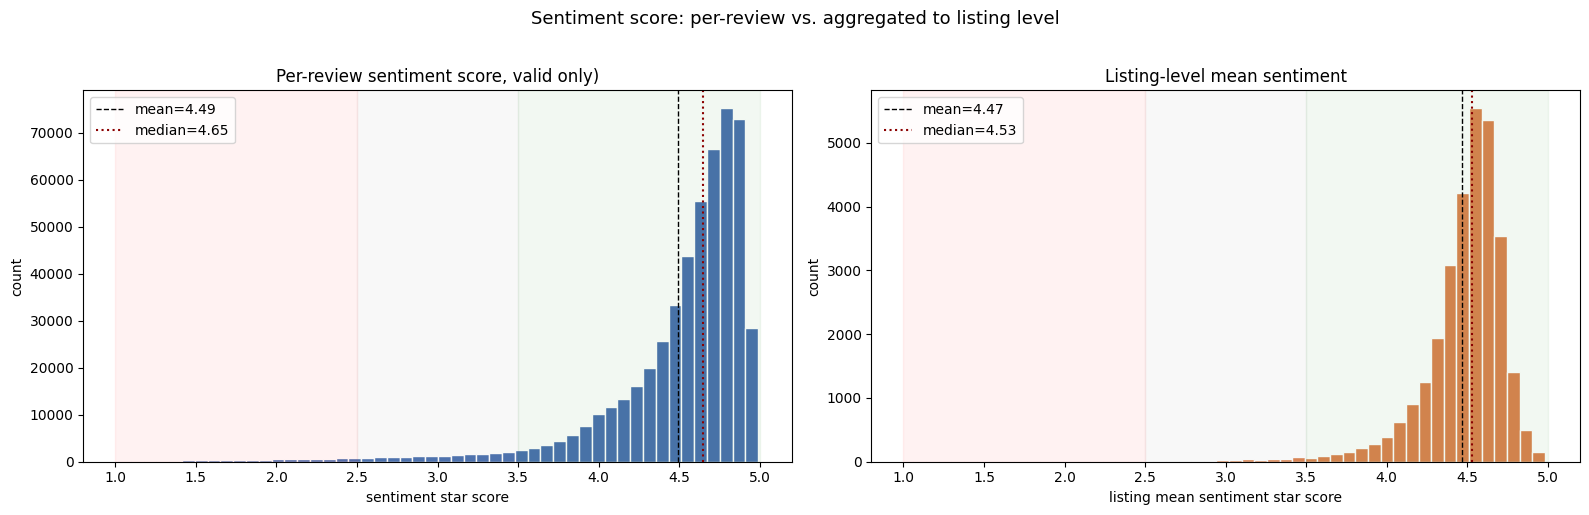

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left: per-review, raw
valid_scores = reviews_sampled['sentiment_star_score'].dropna()
axes[0].hist(valid_scores, bins=50, color='#4c72b0', edgecolor='white')
axes[0].axvline(valid_scores.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={valid_scores.mean():.2f}')
axes[0].axvline(valid_scores.median(), color='darkred', linestyle=':', linewidth=1.5, label=f'median={valid_scores.median():.2f}')
axes[0].axvspan(1, 2.5, color='red', alpha=0.05)
axes[0].axvspan(2.5, 3.5, color='grey', alpha=0.05)
axes[0].axvspan(3.5, 5, color='green', alpha=0.05)
axes[0].set_xlabel('sentiment star score')
axes[0].set_ylabel('count')
axes[0].set_title(f'Per-review sentiment score, valid only)')
axes[0].legend()

# right: listing-level mean, same color-coded background bands
listing_means = sentiment_agg['sentiment_mean'].dropna()
axes[1].hist(listing_means, bins=50, color='#dd8452', edgecolor='white')
axes[1].axvline(listing_means.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={listing_means.mean():.2f}')
axes[1].axvline(listing_means.median(), color='darkred', linestyle=':', linewidth=1.5, label=f'median={listing_means.median():.2f}')
axes[1].axvspan(1, 2.5, color='red', alpha=0.05)
axes[1].axvspan(2.5, 3.5, color='grey', alpha=0.05)
axes[1].axvspan(3.5, 5, color='green', alpha=0.05)
axes[1].set_xlabel('listing mean sentiment star score')
axes[1].set_ylabel('count')
axes[1].set_title(f'Listing-level mean sentiment')
axes[1].legend()

plt.suptitle('Sentiment score: per-review vs. aggregated to listing level', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The per-review → listing-level comparison shows the smoothing effect expected from averaging up to 30 reviews per listing: the per-review distribution has real weight in the red zone and a long left tail, while the listing-level mean distribution is visibly narrower and almost entirely clear of that zone. This is the same aggregation-smoothing pattern already documented for `review_mtld`/`review_readability` earlier, as individual bad experiences get diluted into a listing's overall profile, which is expected at this level of aggregation.

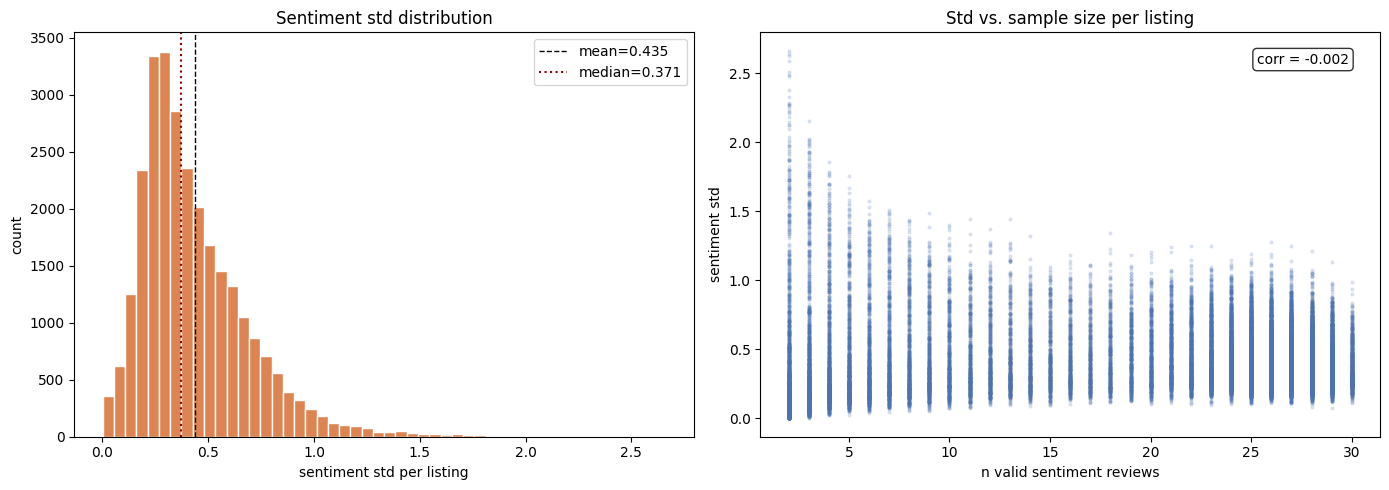

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribution of std itself
std_data = sentiment_agg['sentiment_std'].dropna()
axes[0].hist(std_data, bins=50, color='#dd8452', edgecolor='white')
axes[0].axvline(std_data.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={std_data.mean():.3f}')
axes[0].axvline(std_data.median(), color='darkred', linestyle=':', linewidth=1.5, label=f'median={std_data.median():.3f}')
axes[0].set_xlabel('sentiment std per listing')
axes[0].set_ylabel('count')
axes[0].set_title(f'Sentiment std distribution')
axes[0].legend()

# std vs. n_valid_sentiment 
plot_data = sentiment_agg.dropna(subset=['sentiment_std', 'n_valid_sentiment'])
axes[1].scatter(plot_data['n_valid_sentiment'], plot_data['sentiment_std'], s=4, alpha=0.15, color='#4c72b0')
axes[1].set_xlabel('n valid sentiment reviews')
axes[1].set_ylabel('sentiment std')
axes[1].set_title('Std vs. sample size per listing')

corr = plot_data['n_valid_sentiment'].corr(plot_data['sentiment_std'])
axes[1].text(0.95, 0.95, f'corr = {corr:.3f}', transform=axes[1].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

`sentiment_std` is right-skewed with a near-zero linear correlation to sample size, but the scatter itself tells a more precise story: it's a clear wedge/funnel shape, with std ranging from 0 to 2.6+ at low n (2-5 reviews) and narrowing to roughly 0-1.2 by n=30. Pearson correlation misses this because it's a shrinking-*variance*-of-the-estimate effect, not a linear shift in std's average level. A listing with 3 reviews can land anywhere in that wide range by chance, while a listing with 30 reviews can't.

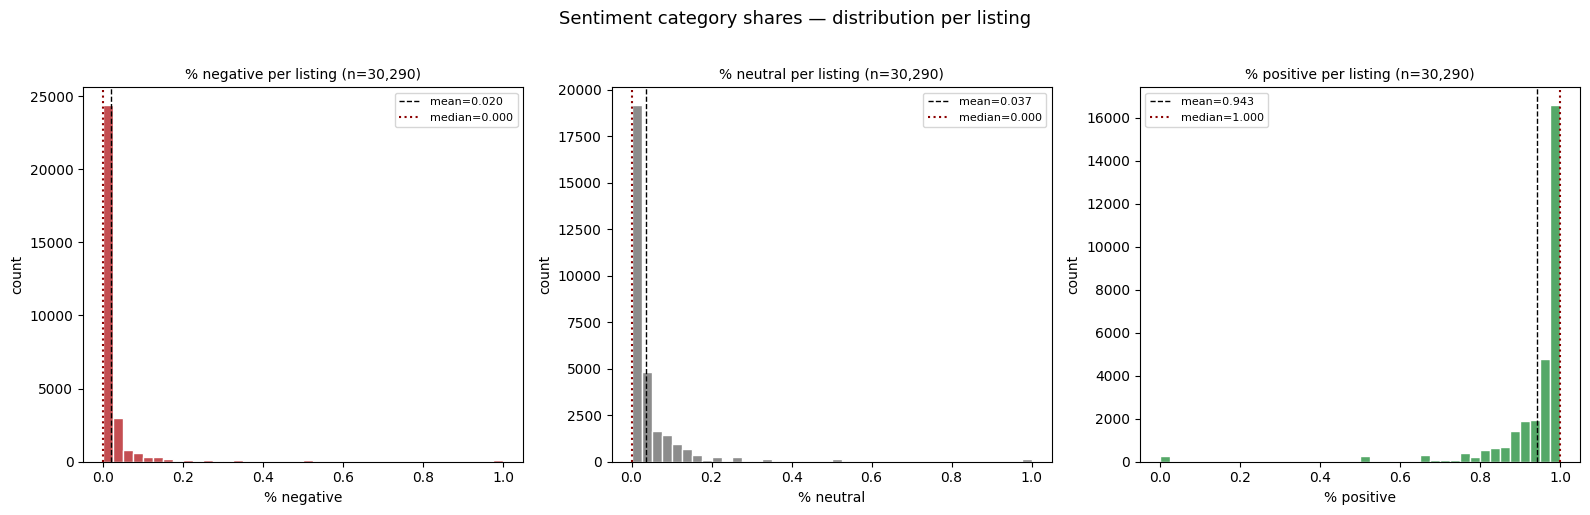

,mean,median,pct_zero,pct_one
sentiment_pct_negative,0.020,0.0,79.361,0.378
sentiment_pct_neutral,0.037,0.0,62.449,0.423
sentiment_pct_positive,0.943,1.0,0.834,53.984


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pct_cols = [
    ('sentiment_pct_negative', '% negative', '#c44e52'),
    ('sentiment_pct_neutral', '% neutral', '#8c8c8c'),
    ('sentiment_pct_positive', '% positive', '#55a868'),
]

for ax, (col, title, color) in zip(axes, pct_cols):
    data = sentiment_agg[col].dropna()
    ax.hist(data, bins=40, color=color, edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={data.mean():.3f}')
    ax.axvline(data.median(), color='darkred', linestyle=':', linewidth=1.5, label=f'median={data.median():.3f}')
    ax.set_xlabel(title)
    ax.set_ylabel('count')
    ax.set_title(f'{title} per listing (n={len(data):,})', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Sentiment category shares — distribution per listing', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

pct_summary = pd.DataFrame({
    col: {
        'mean': sentiment_agg[col].mean(),
        'median': sentiment_agg[col].median(),
        'pct_zero': (sentiment_agg[col] == 0).mean() * 100,
        'pct_one': (sentiment_agg[col] == 1).mean() * 100,
    }
    for col, _, _ in pct_cols
}).T

display(pct_summary.round(3))

The three category shares confirm the corpus is overwhelmingly positive: `sentiment_pct_positive` has a median of 1.0 and 54% of listings sit exactly there, while `pct_negative` and `pct_neutral` are heavily zero-inflated (79.3% and 62/5% zero respectively). This isn't a flaw in the method, as guest reviews are a well-documented positively-skewed genre, but it does mean these three columns are strong candidates for the binary flags or tiered binning already.

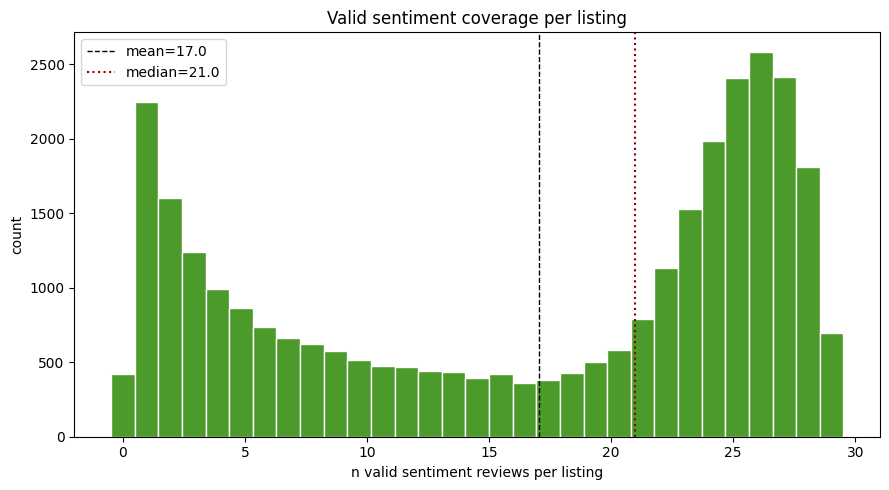

listings with 0 valid reviews: 423 (1.4%)


In [25]:
fig, ax = plt.subplots(figsize=(9, 5))

n_valid_data = sentiment_agg['n_valid_sentiment']

ax.hist(n_valid_data, bins=31, color='#4c9a2a', edgecolor='white', align='left')
ax.axvline(n_valid_data.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={n_valid_data.mean():.1f}')
ax.axvline(n_valid_data.median(), color='darkred', linestyle=':', linewidth=1.5, label=f'median={n_valid_data.median():.1f}')
ax.set_xlabel('n valid sentiment reviews per listing')
ax.set_ylabel('count')
ax.set_title(f'Valid sentiment coverage per listing')
ax.legend()
plt.tight_layout()
plt.show()

print(f"listings with 0 valid reviews: {(n_valid_data == 0).sum():,} ({(n_valid_data == 0).mean()*100:.1f}%)")

`n_valid_sentiment` has a mildly bimodal shape. This reflects two distinct listing populations: those where language coverage or review volume was thin to begin with, and those where nearly the full 30-review sample survived the language filter intact.

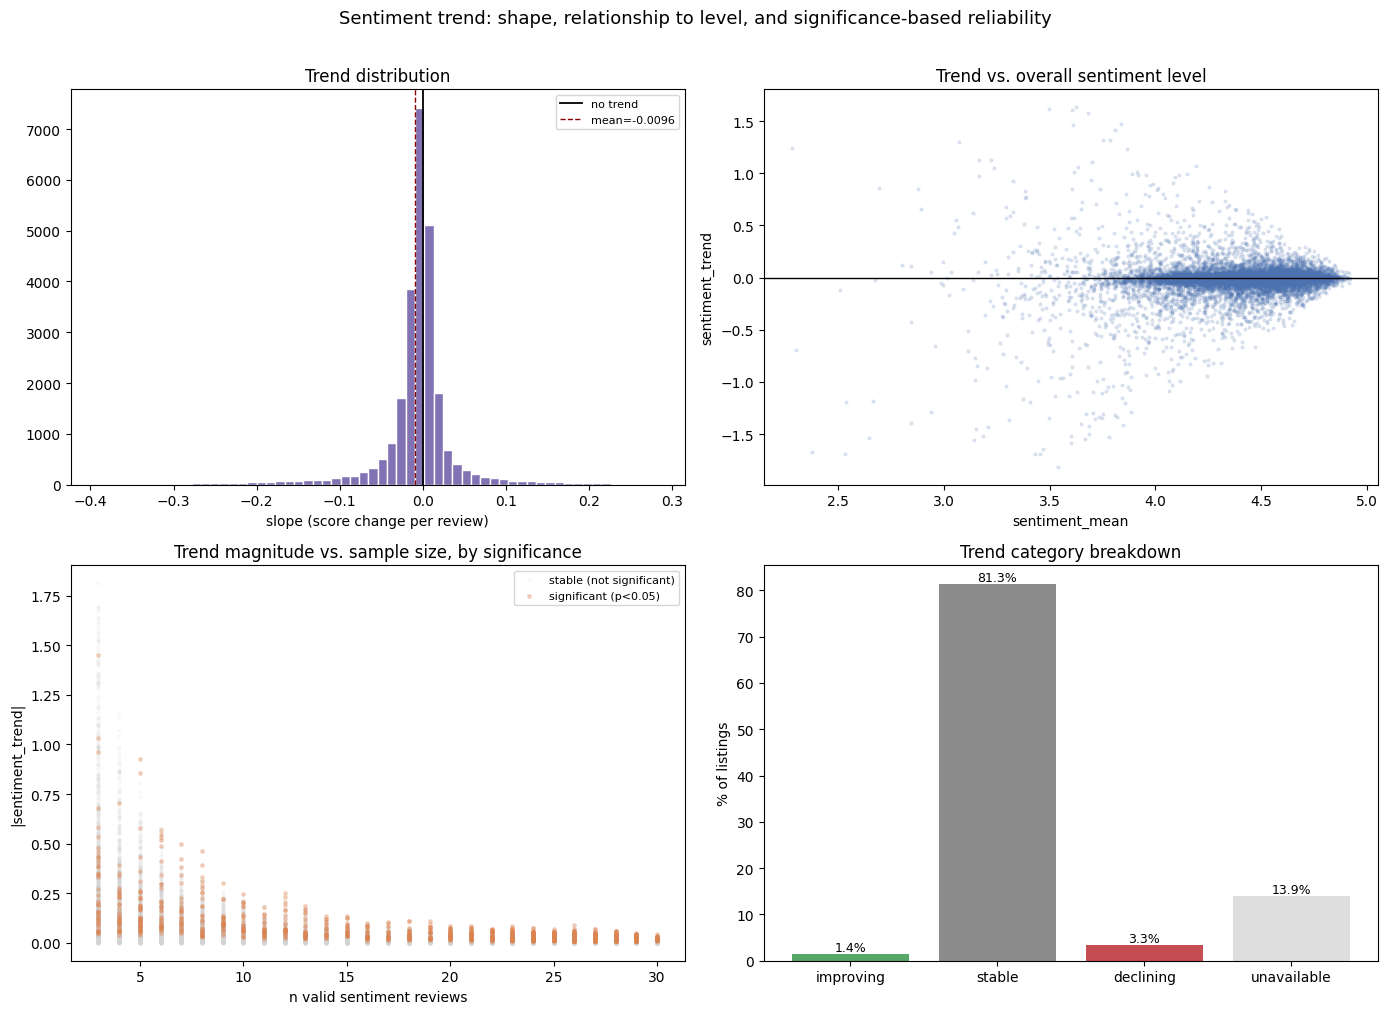

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

trend_data = sentiment_agg['sentiment_trend'].dropna()

# 1. distribution
lower, upper = trend_data.quantile(0.01), trend_data.quantile(0.99)
clipped = trend_data[(trend_data >= lower) & (trend_data <= upper)]
axes[0, 0].hist(clipped, bins=60, color='#8172b3', edgecolor='white')
axes[0, 0].axvline(0, color='black', linewidth=1.3, label='no trend')
axes[0, 0].axvline(trend_data.mean(), color='darkred', linestyle='--', linewidth=1, label=f'mean={trend_data.mean():.4f}')
axes[0, 0].set_xlabel('slope (score change per review)')
axes[0, 0].set_title('Trend distribution')
axes[0, 0].legend(fontsize=8)

# 2. trend vs. overall sentiment level
plot_data = sentiment_agg.dropna(subset=['sentiment_trend', 'sentiment_mean'])
axes[0, 1].scatter(plot_data['sentiment_mean'], plot_data['sentiment_trend'], s=4, alpha=0.15, color='#4c72b0')
axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].set_xlabel('sentiment_mean')
axes[0, 1].set_ylabel('sentiment_trend')
axes[0, 1].set_title('Trend vs. overall sentiment level')

# 3. trend magnitude vs. sample size, colored by significance
plot_data2 = sentiment_agg.dropna(subset=['sentiment_trend', 'n_valid_sentiment', 'sentiment_trend_category'])
sig_mask = plot_data2['sentiment_trend_category'].isin(['improving', 'declining'])
axes[1, 0].scatter(plot_data2.loc[~sig_mask, 'n_valid_sentiment'], plot_data2.loc[~sig_mask, 'sentiment_trend'].abs(),
                    s=4, alpha=0.1, color='lightgrey', label='stable (not significant)')
axes[1, 0].scatter(plot_data2.loc[sig_mask, 'n_valid_sentiment'], plot_data2.loc[sig_mask, 'sentiment_trend'].abs(),
                    s=6, alpha=0.3, color='#dd8452', label='significant (p<0.05)')
axes[1, 0].set_xlabel('n valid sentiment reviews')
axes[1, 0].set_ylabel('|sentiment_trend|')
axes[1, 0].set_title('Trend magnitude vs. sample size, by significance')
axes[1, 0].legend(fontsize=8)

# 4. category breakdown
cat_counts = sentiment_agg['sentiment_trend_category'].value_counts().reindex(
    ['improving', 'stable', 'declining', 'unavailable']
).fillna(0)
cat_pct = cat_counts / cat_counts.sum() * 100
colors_cat = ['#55a868', '#8c8c8c', '#c44e52', '#dedede']
axes[1, 1].bar(cat_pct.index, cat_pct.values, color=colors_cat)
axes[1, 1].set_ylabel('% of listings')
axes[1, 1].set_title('Trend category breakdown')
for i, v in enumerate(cat_pct.values):
    axes[1, 1].text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Sentiment trend: shape, relationship to level, and significance-based reliability', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

`sentiment_trend` sits close to zero on average, consistent with most listings having no strong directional history. Raw slope magnitude follows a funnel pattern against sample size, as the |slope| reaches 1.75+ at n=3 and compresses to under ~0.25 by n=30, so a regression through very few points can produce a large, misleading slope purely from noise. To separate a genuine trend from this small-sample artifact, each listing's slope is paired with its regression p-value, and only slopes distinguishable from zero (p<0.05) are labeled `improving`/`declining` and everything else defaults to `stable`. The resulting breakdown is heavily `stable`, with `improving` and `declining` as a small, statistically defensible minority, and `unavailable` for listings with fewer than 3 valid, dated reviews.

### 4.5 Validation Against Numeric Review Scores

This subsection tests whether text-derived sentiment reveals variation that `review_scores_rating`'s ceiling effect hides?

In [27]:
# merge sentiment_agg and listings_nlp
existing_sentiment_cols = [c for c in sentiment_agg.columns if c in listings_nlp.columns]
if existing_sentiment_cols:
    listings_nlp = listings_nlp.drop(columns=existing_sentiment_cols)

listings_nlp = listings_nlp.merge(sentiment_agg, left_on='id', right_index=True, how='left')

n_total = len(listings_nlp)
n_with_sentiment = listings_nlp['sentiment_mean'].notna().sum()
n_without = n_total - n_with_sentiment

print(f"total listings: {n_total:,}")
print(f"with sentiment_mean: {n_with_sentiment:,} ({n_with_sentiment/n_total*100:.1f}%)")
print(f"without (NaN): {n_without:,} ({n_without/n_total*100:.1f}%)")

total listings: 35,818
with sentiment_mean: 30,290 (84.6%)
without (NaN): 5,528 (15.4%)


In [28]:
# ceiling check
ceiling_check = listings_nlp['review_scores_rating_raw'].quantile([0.75, 0.90, 0.95, 0.97, 0.99, 1.0])
display(ceiling_check.to_frame('review_scores_rating_raw'))

pct_at_max = (listings_nlp['review_scores_rating_raw'] == listings_nlp['review_scores_rating_raw'].max()).mean() * 100
print(f"\nlistings at the exact maximum: {pct_at_max:.1f}%")

,review_scores_rating_raw
0.75,4.97
0.90,5.00
0.95,5.00
0.97,5.00
0.99,5.00
1.00,5.00



listings at the exact maximum: 19.7%


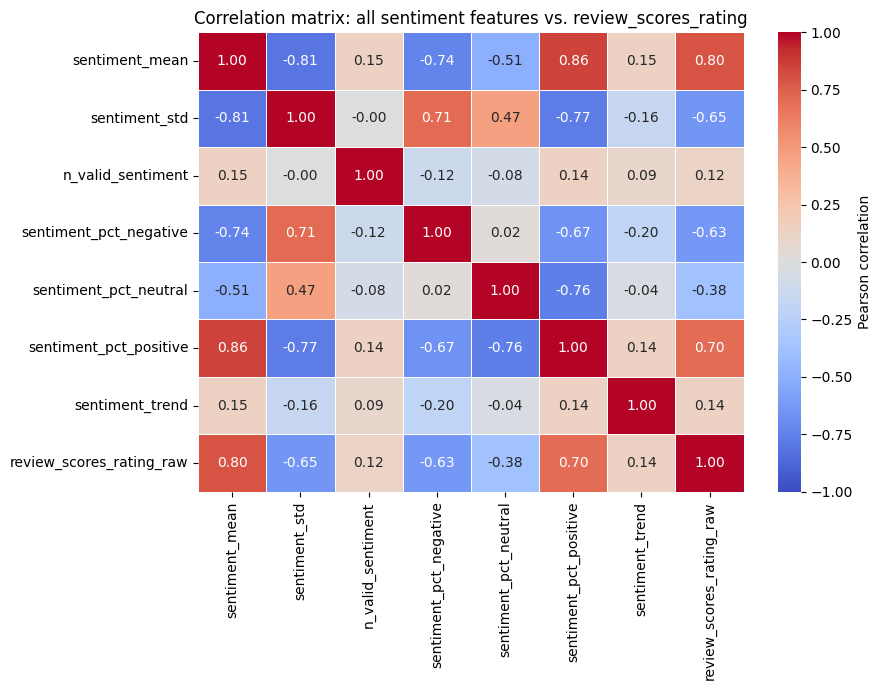

In [29]:
# correlation check
sentiment_vars = [
    'sentiment_mean', 'sentiment_std', 'n_valid_sentiment',
    'sentiment_pct_negative', 'sentiment_pct_neutral', 'sentiment_pct_positive',
    'sentiment_trend', 'review_scores_rating_raw'
]

corr_matrix = listings_nlp[sentiment_vars].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0,
            linewidths=0.5, cbar_kws={'label': 'Pearson correlation'}, ax=ax)
ax.set_title('Correlation matrix: all sentiment features vs. review_scores_rating')
plt.tight_layout()
plt.show()

The heatmap confirms `review_scores_rating` correlates most strongly with `sentiment_mean` and `sentiment_pct_positive`, moderately with `sentiment_pct_negative` and `sentiment_std`, and only weakly with `sentiment_trend` and `n_valid_sentiment`, as they are structurally unrelated to a listing's quality level.

The internal structure among the sentiment variables themselves is informative in its own right. `sentiment_std` correlates negatively with `sentiment_mean` and positively with `sentiment_pct_negative`, which is mechanically expected, since a listing pinned near the ceiling has little room left to vary, while a listing with mixed reviews both scores lower on average and disagrees more. `sentiment_pct_neutral` stands out as behaving differently from `pct_negative`: it correlates only weakly with `review_scores_rating` and barely at all with `sentiment_mean` or `pct_negative`, consistent with "neutral" capturing lukewarm-but-not-complaining reviews rather than functioning as a softer version of negative one.

`sentiment_trend`'s near-total independence from every other sentiment variable reinforces the earlier finding: with 81% of listings landing in the conservative `stable` category, trend captures a narrow, largely orthogonal slice of information that the level-based metrics don't touch at all.

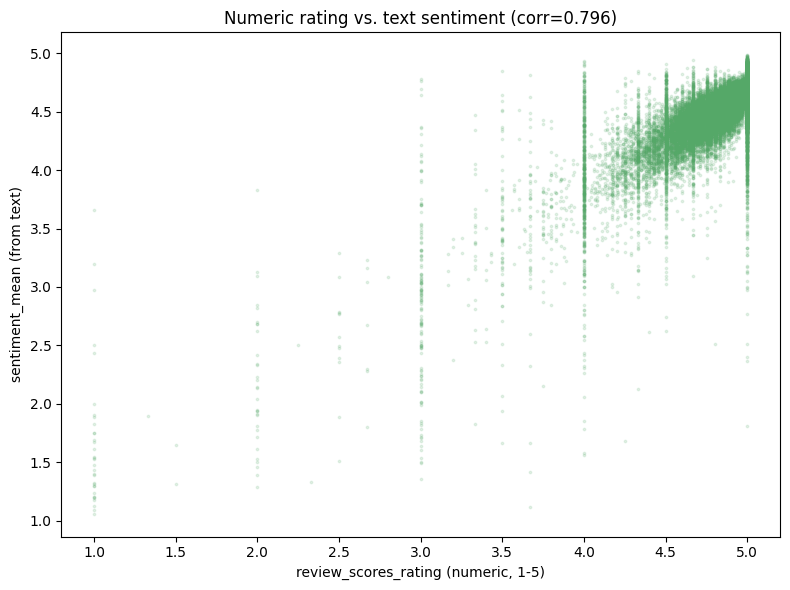

In [30]:
# scatter - reviews_score_rating vs sentiment_mean
plot_data = listings_nlp.dropna(subset=['review_scores_rating_raw', 'sentiment_mean'])
corr = plot_data['review_scores_rating_raw'].corr(plot_data['sentiment_mean'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(plot_data['review_scores_rating_raw'], plot_data['sentiment_mean'], s=3, alpha=0.15, color='#55a868')
ax.set_xlabel('review_scores_rating (numeric, 1-5)')
ax.set_ylabel('sentiment_mean (from text)')
ax.set_title(f'Numeric rating vs. text sentiment (corr={corr:.3f})')
plt.tight_layout()
plt.show()

The direct correlation between `review_scores_rating` and `sentiment_mean` is stronger than initially expected. 0.796, not the weak-to-moderate range originally anticipated. It does mean the overall correlation coefficient alone can't be the primary evidence for the thesis: it's driven heavily by the extreme low end of the rating scale (1-3), where both numeric rating and text sentiment agree strongly that something went badly wrong, which is expected and reassuring. The real test is the vertical spread visible at each rating value, especially at rating=5.0, where `sentiment_mean` ranges all the way from below 2.0 up to 5.0 despite the numeric score showing zero variance.

12,605 listings with review_scores_rating >= 4.9 (numeric ceiling)
sentiment_mean within this group — std=0.164, range=[1.81, 4.98], IQR=[4.56, 4.71]


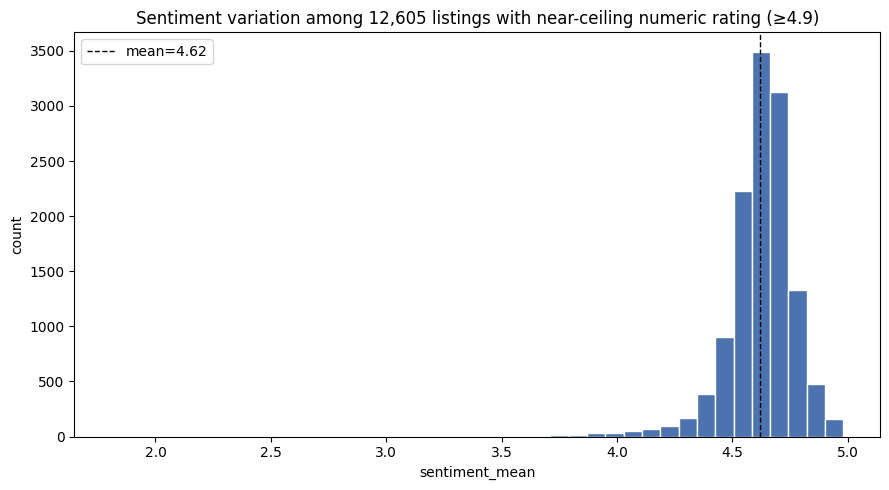

In [31]:
# sentiment variation whihin listings with review_scores_rating > 75th percentile
CEILING_THRESHOLD = 4.9
near_ceiling = listings_nlp[listings_nlp['review_scores_rating_raw'] >= CEILING_THRESHOLD].dropna(subset=['sentiment_mean'])

print(f"{len(near_ceiling):,} listings with review_scores_rating >= {CEILING_THRESHOLD} (numeric ceiling)")
print(f"sentiment_mean within this group — std={near_ceiling['sentiment_mean'].std():.3f}, "
      f"range=[{near_ceiling['sentiment_mean'].min():.2f}, {near_ceiling['sentiment_mean'].max():.2f}], "
      f"IQR=[{near_ceiling['sentiment_mean'].quantile(0.25):.2f}, {near_ceiling['sentiment_mean'].quantile(0.75):.2f}]")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(near_ceiling['sentiment_mean'], bins=40, color='#4c72b0', edgecolor='white')
ax.axvline(near_ceiling['sentiment_mean'].mean(), color='black', linestyle='--', linewidth=1,
           label=f"mean={near_ceiling['sentiment_mean'].mean():.2f}")
ax.set_xlabel('sentiment_mean')
ax.set_ylabel('count')
ax.set_title(f'Sentiment variation among {len(near_ceiling):,} listings with near-ceiling numeric rating (≥{CEILING_THRESHOLD})')
ax.legend()
plt.tight_layout()
plt.show()

Restricting to the 12,605 listings already pinned at the numeric ceiling (rating ≥ 4.9), where the numeric score has essentially nothing left to say,`sentiment_mean` shows real, non-trivial spread: mean 4.62, with a visible left tail reaching down toward 3.5-4.0 and a handful of listings even lower. This is the direct, concrete confirmation that text sentiment recovers meaningful variation among listings the numeric score treats as identical. The spread is modest in absolute terms, as most mass still sits in a fairly narrow 4.3-5.0 band, but modest, real variation where the alternative is *zero* variation is exactly the kind of signal a clustering algorithm can use that `review_scores_rating` cannot provide.

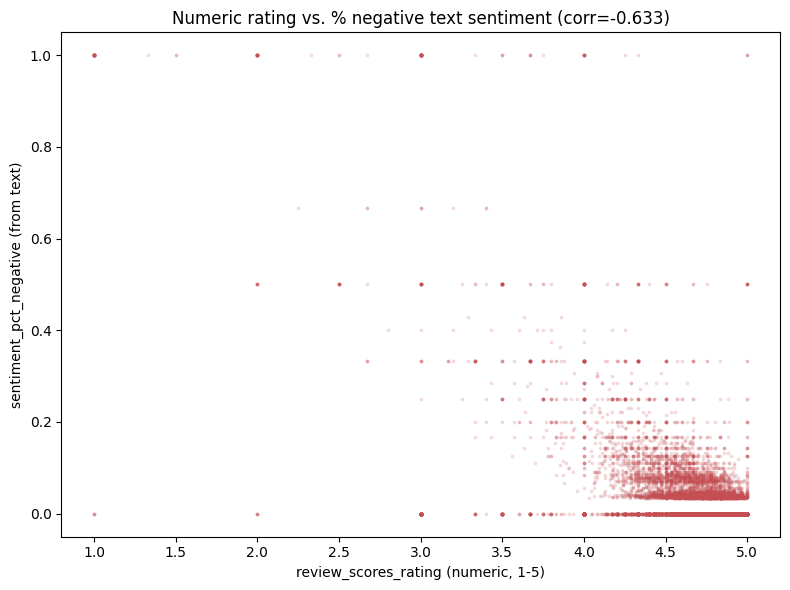

In [32]:
# connection between % negative and review_scores_rating
plot_data2 = listings_nlp.dropna(subset=['review_scores_rating_raw', 'sentiment_pct_negative'])
corr_neg = plot_data2['review_scores_rating_raw'].corr(plot_data2['sentiment_pct_negative'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(plot_data2['review_scores_rating_raw'], plot_data2['sentiment_pct_negative'], s=3, alpha=0.15, color='#c44e52')
ax.set_xlabel('review_scores_rating (numeric, 1-5)')
ax.set_ylabel('sentiment_pct_negative (from text)')
ax.set_title(f'Numeric rating vs. % negative text sentiment (corr={corr_neg:.3f})')
plt.tight_layout()
plt.show()

The cross-check against `sentiment_pct_negative` confirms the expected direction, as higher numeric ratings correspond to a lower share of text-negative reviews, with a similar moderate-strong magnitude to the mean's correlation. The scatter shows the same reassuring pattern as `sentiment_mean`: broad agreement at the extremes (near-zero negative share for most high-rated listings, higher share at low ratings), but real scatter in between, including listings with a meaningfully elevated negative share despite a decent numeric rating, plausibly capturing dissatisfaction that gets rated tolerantly but described critically in text, a distinction the numeric score alone cannot make.

In [33]:
# merge each individual review with its listing's raw numeric rating
review_level_check = reviews_sampled.merge(
    listings_nlp[['id', 'review_scores_rating_raw']],
    left_on='listing_id', right_on='id', how='left'
)

HIGH_RATING_THRESHOLD = 4.8
eligible_mask = review_level_check['review_scores_rating_raw'] >= HIGH_RATING_THRESHOLD
disagreement_mask = eligible_mask & (review_level_check['sentiment_category'] == 'negative')

disagreement_reviews = review_level_check.loc[disagreement_mask]
print(f"{len(disagreement_reviews):,} reviews from high-rated listings (rating >= {HIGH_RATING_THRESHOLD}) "
      f"classified as negative sentiment")
print(f"({len(disagreement_reviews) / eligible_mask.sum() * 100:.2f}% of all reviews from high-rated listings)")

1,490 reviews from high-rated listings (rating >= 4.8) classified as negative sentiment
(0.40% of all reviews from high-rated listings)


In [34]:
pd.set_option('display.max_colwidth', 300)
sample_size = min(15, len(disagreement_reviews))
display(disagreement_reviews[
    ['listing_id', 'review_scores_rating_raw', 'sentiment_star_score', 'comments_clean']
].sample(sample_size, random_state=42))

,listing_id,review_scores_rating_raw,sentiment_star_score,comments_clean
363146,1184032513201161635,4.82,2.158339,"1 nacht aushaltbar, leider nicht länger und nicht nochmal. preis leistung für mich nicht in ordnung."
109546,41872405,4.86,1.885655,"although this place is in a great location to many of rome’s attractions and amenities, it is in serious need of a deep cleaning and facelift. furniture, walls, cabinets were dirty and worn out. although the beds were comfortable and more like queen size, you get turned off by how stained and wo..."
101070,24889521,4.82,2.263455,tbh i am very disappointed after trying different airbnb 6 times when i travel to rome. and this one i had high expectation. the 4 stars review is just my personal habit. good point: location is perfect if u wanna walk to most of the attractions. things to improve: noise- the place is one floor ...
299782,1181936838311815205,4.90,2.478189,"nicolò was a thoughtful and attentive host. the flat was spotless, well equipped and felt genuinely cared for. small touches like clear instructions and quick communication made the stay seamless. location was ideal with everything within walking distance — the metro is a 5 minute walk with link..."
161258,10700775,4.90,1.993022,es caro bien ubicado mala atención al cliente
423107,1366218,4.88,1.089071,"unfortunately, this is the most negative review i’ve ever given. the place is highly misrepresented. upon arrival, cleaners were still working, and the property needed a significant upgrade. for the high price paid, the quality was extremely poor—i couldn’t stay longer than five minutes. traveli..."
163854,42319464,4.84,2.465031,"location is great but do not expect a well taken care of space - terribly stained couch, for example. photos do not match the current state of the apartment."
553868,607674258805074435,4.82,1.976323,"to say this apartment is unreal is underselling it! it is smack bang in the middle of rome next to the trevi fountain! everything is in walking distance including the colesseum, spanish steps and all the main shopping of the centre. there are restaurants and bars everywhere surrounding you. the ..."
87309,51549073,4.82,1.789076,"al nostro arrivo ci siamo resi immediatamente conto che l'appartamento fosse sporco e l'abbiamo fatto presente. i muri sono sporchi, presenza di muffa, ragnatele, ambienti maleodoranti e bui, bagni puliti solo in apparenza, copriwater danneggiati, cucina unta ove impossibile preparare anche solo..."
603879,989837440397408005,4.94,2.287890,"we had a great week at maria's flat. she was very friendly, flexible with check in and responsive. the place has everything you need for a comfy stay, and it is nicer than the pictures. there is a big outdoors area for the warm months and central heating for the cold months. an expresso machine,..."


A direct read of 15 disagreement reviews (numeric rating ≥4.8, `sentiment_category = negative`) confirmed the bulk of the signal is genuine (hosts not responding, listing-description mismatches, broken amenities), but also surfaced a real limitation: 4-5 of the 15 were model misreads rather than hidden complaints (hyperbolic praise, a complaint about Airbnb's review process rather than the stay, a pickpocketing incident the reviewer explicitly disclaimed as unrelated to the host).

Since the full disagreement pool is only ~1,500 reviews, a much larger, systematic sample is realistic without a full manual read-through: 150 reviews are classified via the GPT-3.5-turbo infrastructure. A single structured, batched prompt asking the model to label each review as a genuine complaint or a likely sentiment-model misread (sarcasm, hyperbole, disclaimed blame, off-topic negativity), returning parseable JSON. This narrows the confidence interval enough to state an actual, citable error-rate estimate for `sentiment_pct_negative`'s disagreement signal.

In [35]:
from dotenv import load_dotenv
from openai import OpenAI, OpenAIError, RateLimitError, AuthenticationError, APIError
import json

load_dotenv('../config/.env')
api_key = os.environ.get('OPENAI_API_KEY')
if api_key is None:
    raise ValueError("OPENAI_API_KEY not found — check config/.env in the project root")

client = OpenAI(api_key=api_key)
api_exceptions = {
    RateLimitError: "Quota exceeded.",
    AuthenticationError: "Invalid API key.",
    APIError: "Problem with OpenAI server.",
    OpenAIError: "OpenAI returned an error.",
}

def strip_json_fences(text):
    text = text.strip()
    text = re.sub(r'^```(?:json)?\s*', '', text)
    text = re.sub(r'\s*```$', '', text)
    return text.strip()

In [36]:
def build_classification_prompt(reviews_batch):
    header = (
        "For each numbered guest review below, the review comes from a listing with a very high "
        "star rating (4.8+), but a separate sentiment model flagged the review's TEXT as negative. "
        "Classify each review as either:\n"
        "- \"genuine\": the text describes a real, specific complaint or problem with the stay "
        "(unresponsive host, broken amenity, listing mismatch, noise, etc.)\n"
        "- \"misread\": the text is not actually a complaint about the stay — e.g. sarcasm, "
        "hyperbolic praise, a complaint unrelated to the listing itself (like Airbnb's review process), "
        "or a negative event the reviewer explicitly says was NOT the host's fault\n"
        "Return ONLY valid JSON, no commentary, mapping each review number to its label:\n"
        '{"1": "genuine", "2": "misread", ...}\n\n'
    )
    body = "\n".join(f"{i+1}. {text}" for i, text in enumerate(reviews_batch))
    return header + body

def classify_disagreement_batch(client, reviews_batch, model="gpt-3.5-turbo"):
    prompt = build_classification_prompt(reviews_batch)
    raw_text = None
    try:
        response = client.responses.create(model=model, input=prompt, temperature=0)
        raw_text = strip_json_fences(response.output_text)
        return json.loads(raw_text)
    except tuple(api_exceptions.keys()) as e:
        print(api_exceptions[type(e)])
        return None
    except json.JSONDecodeError as e:
        print(f"Response wasn't valid JSON: {e}")
        if raw_text:
            print(raw_text)
        return None

In [37]:
DISAGREEMENT_SAMPLE_SIZE = 150
BATCH_SIZE_LLM = 50  # reviews per API call, keeps prompts within context limits

classification_sample = disagreement_reviews.sample(
    min(DISAGREEMENT_SAMPLE_SIZE, len(disagreement_reviews)), random_state=42
).reset_index(drop=True)

all_labels = {}
texts = classification_sample['comments_clean'].tolist()

for start in range(0, len(texts), BATCH_SIZE_LLM):
    batch = texts[start:start + BATCH_SIZE_LLM]
    result = classify_disagreement_batch(client, batch)
    if result is None:
        print(f"batch starting at {start} failed — stopping, inspect before retrying")
        break
    for local_idx, label in result.items():
        all_labels[start + int(local_idx) - 1] = label
    print(f"batch {start}-{start+len(batch)-1}: {len(result)} labels received")

classification_sample['llm_label'] = classification_sample.index.map(all_labels)
print(f"\nlabeled: {classification_sample['llm_label'].notna().sum()} / {len(classification_sample)}")
print(classification_sample['llm_label'].value_counts())

batch 0-49: 50 labels received
batch 50-99: 50 labels received
batch 100-149: 50 labels received

labeled: 150 / 150
llm_label
genuine    108
misread     42
Name: count, dtype: int64


In [38]:
# compute the confidence interval with the systematic sample
from scipy import stats

labeled = classification_sample.dropna(subset=['llm_label'])
n = len(labeled)
k = (labeled['llm_label'] == 'misread').sum()
p_hat = k / n
lo, hi = stats.binomtest(k, n).proportion_ci(confidence_level=0.95, method='exact')

print(f"n={n}, misread={k} ({p_hat:.1%})")
print(f"95% exact CI: [{lo:.1%}, {hi:.1%}]")
print(f"applied to {len(disagreement_reviews):,} disagreement reviews: [{lo*len(disagreement_reviews):.0f}, {hi*len(disagreement_reviews):.0f}]")

n=150, misread=42 (28.0%)
95% exact CI: [21.0%, 35.9%]
applied to 1,490 disagreement reviews: [313, 535]


**Observations:**

LLM-assisted classification of 150 disagreement reviews, drawn from the 1,490 total, puts the misread rate at 28% (42/150), with a 95% exact confidence interval of [21.0%, 35.9%]. Applied to the full disagreement pool, this suggests roughly 313-535 of the 1,490 reviews are model misreads (sarcasm, hyperbole, disclaimed blame) rather than genuine hidden complaints, with the majority representing real friction guests described in text but forgave in their star rating.

This confirms `sentiment_pct_negative` carries a real, non-trivial noise component, as roughly a quarter of its "negative" signal among high-rated listings is a false read, but the majority of the disagreement signal remains genuine, so the feature is not discarded on this basis. The finding is documented here as a quantified, honest limitation of the sentiment pipeline, not as grounds for a new feature or correction; `sentiment_pct_negative` is retained in the feature set as-is.

### 4.6 Sentiment Analysis Summary


This section built a text-derived sentiment signal to test whether review text recovers variation that `review_scores_rating`'s ceiling effect hides, working through five stages:

- **Model selection & verification**: `nlptown/bert-base-multilingual-uncased-sentiment` chosen for domain fit (product/service reviews) and native coverage of six languages; actual coverage on `reviews_sampled` confirmed at 86.6%, and the model's `id2label` ordering verified directly before trusting any star-weight mapping.

- **Inference**: per-review sentiment computed as a continuous score via expected value over the model's softmax probabilities, run in 20,000-review chunks with a `review_index` column added.

- **Listing-level aggregation**: eight features built from the per-review scores — `sentiment_mean`, `sentiment_std`, `n_valid_sentiment`, three category shares (`pct_negative`/`neutral`/`positive`), and a significance-tested `sentiment_trend`/`sentiment_trend_category` (slope paired with its regression p-value, so only listings with a statistically distinguishable trend are labeled `improving`/`declining`; the rest default to `stable`). Reviews outside the model's language coverage were retroactively marked `unavailable`, leaving zero valid coverage for only 1.4% of listings.

- **Validation against numeric scores**: the central thesis held up under direct test among the 12,605 listings already pinned at the numeric ceiling (rating ≥4.9), `sentiment_mean` still shows real, non-trivial spread, and the independent `sentiment_pct_negative` cross-check pointed the same direction (corr=-0.633 with numeric rating) without simply duplicating `sentiment_mean`.

- **Reliability check on the disagreement signal**: reviews from high-rated listings (≥4.8) that the model scored as negative were examined directly. First via a 15-review manual read, then via a systematic, LLM-assisted classification of 150 reviews using the GPT-3.5-turbo infrastructure. This narrowed the estimate to a defensible 28% misread rate, confirming most of the disagreement signal is genuine guest-described friction the numeric score forgave, with a real but minority share attributable to sentiment-model noise (sarcasm, hyperbole, disclaimed blame).

## 5. Topic Modeling

Sentiment captured *how* listings are perceived. This section asks *what* hosts and guests actually talk about, testing whether host-written descriptions emphasize different themes than what guests report experiencing.

Two corpora are modeled separately (`reviews_sampled` and `description_cleaned`), as comparing what each side emphasizes is the point, and pooling them would erase that distinction from the outset. Granularity follows the same pattern established for sentiment: computed per document, then aggregated to listing level as topic shares.

The main limitation here is that the core, defensible baseline is TF-IDF + NMF, restricted to English text.

### 5.1 Corpus Preparation

TF-IDF has no notion of meaning, only literal word overlap. Mixing languages would risk NMF discovering "language clusters" rather than genuine content topics, so both corpora are restricted to English text before modeling.

In [39]:
# English-only subsets for the TF-IDF+NMF baseline
reviews_en = reviews_sampled.loc[reviews_sampled['review_lang'] == 'en', ['listing_id', 'comments_clean']].copy()
descriptions_en = listings_nlp.loc[
    listings_nlp['description_lang'] == 'en', ['id', 'description_cleaned']
].copy()

print(f"English reviews: {len(reviews_en):,} ({len(reviews_en)/len(reviews_sampled)*100:.1f}% of reviews_sampled)")
print(f"English descriptions: {len(descriptions_en):,} ({len(descriptions_en)/len(listings_nlp)*100:.1f}% of listings)")

English reviews: 316,472 (52.3% of reviews_sampled)
English descriptions: 34,750 (97.0% of listings)


`description_cleaned` is 97.0% English already, so this restriction costs almost nothing there. Reviews lose roughly half the sample (52.3%). This asymmetry is the direct motivation for treating BERTopic as a genuine stretch goal later: a multilingual embedding backbone could recover the half of the review corpus this baseline sets aside.

### 5.2 Reviews

#### 5.2.1 Vectorization: TF-IDF

Before any topic-modeling algorithm can work with text, each document needs to become a vector of numbers. TF-IDF (term frequency–inverse document frequency) weights each word in each document by how often it appears there and how rare it is across the whole corpus, so a word common in one specific review but rare corpus-wide scores high, while a word appearing in nearly every review contributes little regardless of repetition. `min_df=5` and `max_df=0.5` drop terms too rare (fewer than 5 documents) or too generic (over half the corpus) to be informative; `ngram_range=(1,2)` includes two-word phrases alongside single words, to catch short expressions like "check in" a single-word model would miss.

In [40]:
# stopword_sets and tokenize_words were defined in Part 1 (02_feature_engineering.ipynb)
import re
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

LEXICON_LANGS = {'en': 'english', 'it': 'italian', 'fr': 'french', 'es': 'spanish', 'de': 'german', 'ru': 'russian'}
stopword_sets = {code: set(stopwords.words(name)) for code, name in LEXICON_LANGS.items()}

_WORD_TOKEN_RE = re.compile(r"\w+", re.UNICODE)
def tokenize_words(text):
    return _WORD_TOKEN_RE.findall(str(text).lower())

for code, words in stopword_sets.items():
    print(f"{code}: {len(words)} stopwords")

en: 198 stopwords
it: 279 stopwords
fr: 157 stopwords
es: 313 stopwords
de: 232 stopwords
ru: 151 stopwords


In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

english_stopwords = list(stopword_sets['en']) 
def build_tfidf(texts, stopwords=english_stopwords):
    vectorizer = TfidfVectorizer(
        stop_words=stopwords,
        min_df=5,          # drop words appearing in fewer than 5 documents (too rare/noisy)
        max_df=0.5,        # drop words appearing in over 50% of documents (too generic)
        ngram_range=(1, 2),  # unigrams + bigrams, to capture short phrases like "check in"
    )
    matrix = vectorizer.fit_transform(texts)
    return vectorizer, matrix

tfidf_vec_reviews, tfidf_matrix_reviews = build_tfidf(reviews_en['comments_clean'])
print(f"reviews TF-IDF matrix: {tfidf_matrix_reviews.shape[0]:,} docs x {tfidf_matrix_reviews.shape[1]:,} terms")

reviews TF-IDF matrix: 316,472 docs x 203,637 terms


#### 5.2.2 Model Selection: NMF & Coherence

NMF (non-negative matrix factorization) is the topic-discovery mechanism: it factors the TF-IDF matrix (documents × words) into two smaller matrices — documents × topics and topics × words, with every value constrained non-negative, keeping results interpretable as "this document is a mix of these topics". NMF is used over LDA as the primary hypothesis, since NMF is empirically more stable on short documents (median review length ~205 characters). This is validated via coherence score across a range of topic counts rather than assumed outright.

Coherence measures whether a topic's top words actually co-occur across the corpus. The objective way to pick a topic count (k), the same role a scree plot plays for choosing PCA components elsewhere in this project. UMass coherence is used specifically and is implemented directly from the same TF-IDF matrix already built.

A first pass runs coherence selection and inspects the resulting topics directly, without any topic-specific stopword tuning beyond the base English list, establishing an honest baseline before deciding whether, and how, to intervene.

In [42]:
from scipy.sparse import csc_matrix
from sklearn.decomposition import NMF

def umass_coherence(topics, doc_term_matrix, vocab, epsilon=1):
    """Hand-rolled UMass coherence (Mimno et al. 2011), computed directly from
    the sklearn document-term matrix already built — no gensim dependency needed.
    For each pair of top words in a topic, measures how often they co-occur
    across documents relative to the earlier word's own document frequency.
    Averaged across all topics; higher (closer to 0) = more coherent."""
    binary_matrix = csc_matrix((doc_term_matrix > 0).astype(int))
    doc_freq = np.asarray(binary_matrix.sum(axis=0)).flatten()
    vocab_index = {w: i for i, w in enumerate(vocab)}

    topic_scores = []
    for topic_words in topics:
        idx = [vocab_index[w] for w in topic_words if w in vocab_index]
        pair_scores = []
        for i in range(1, len(idx)):
            for j in range(i):
                wi, wj = idx[i], idx[j]
                d_wj = doc_freq[wj]
                if d_wj == 0:
                    continue
                co_doc_freq = binary_matrix[:, wi].multiply(binary_matrix[:, wj]).sum()
                pair_scores.append(np.log((co_doc_freq + epsilon) / d_wj))
        if pair_scores:
            topic_scores.append(np.mean(pair_scores))
    return np.mean(topic_scores) if topic_scores else np.nan

def get_nmf_topics(nmf_model, feature_names, n_top_words=10):
    topics = []
    for component in nmf_model.components_:
        top_idx = component.argsort()[-n_top_words:][::-1]
        topics.append([feature_names[i] for i in top_idx])
    return topics

def select_k_via_coherence(tfidf_matrix, feature_names, k_range=(5, 8, 10, 12, 15, 20)):
    results = []
    for k in k_range:
        nmf = NMF(n_components=k, random_state=42, max_iter=500)
        nmf.fit(tfidf_matrix)
        topics = get_nmf_topics(nmf, feature_names)
        score = umass_coherence(topics, tfidf_matrix, feature_names)
        results.append({'k': k, 'coherence': score})
        print(f"k={k}: coherence={score:.4f}")
    return pd.DataFrame(results)

In [43]:
coherence_results = select_k_via_coherence(tfidf_matrix_reviews, tfidf_vec_reviews.get_feature_names_out())

k=5: coherence=-2.0496
k=8: coherence=-2.3508
k=10: coherence=-2.3038
k=12: coherence=-2.4478
k=15: coherence=-2.6975
k=20: coherence=-2.8392


In [44]:
for k in [5, 10, 15]:
    nmf = NMF(n_components=k, random_state=42, max_iter=500)
    nmf.fit(tfidf_matrix_reviews)
    topics = get_nmf_topics(nmf, tfidf_vec_reviews.get_feature_names_out())
    print(f"\n{'='*20} k={k} {'='*20}")
    for i, words in enumerate(topics):
        print(f"topic {i}: {', '.join(words)}")


==================== k=5 ====================
topic 0: apartment, us, rome, walk, restaurants, close, well, easy, also, metro
topic 1: great, great location, location, great host, host, apartment great, location great, place great, apartment, great apartment
topic 2: place, great place, place stay, great, stay, stay rome, place great, rome, nice place, place clean
topic 3: nice, good, nice place, good location, really, clean, nice apartment, host, location, really nice
topic 4: stay, would, recommend, definitely, highly, highly recommend, would definitely, perfect, amazing, host

==================== k=10 ====================
topic 0: us, apartment, well, rome, check, everything, comfortable, time, clean, also
topic 1: great, great location, location, great host, host, apartment great, location great, apartment, place great, great apartment
topic 2: place, great place, place stay, great, place great, stay, rome, stay rome, place clean, nice place
topic 3: nice, nice place, nice apartm

Coherence favors the smallest k tested (k=5) and decreases roughly monotonically as k grows. UMass coherence is documented in the topic-modeling literature as systematically biased toward fewer topics, since broader topics pull in more common vocabulary, which naturally co-occurs across more documents regardless of genuine semantic relatedness. The qualitative output confirms the score can't be trusted alone here: at every tested k, 3-7 of the topics found are not distinct content topics, but variants of the same generic praise ("great"/"nice"/"good"/"perfect" + "place"/"location"/"apartment"), fragmenting the corpus by which compliment word a guest happened to use rather than what they're actually talking about. This tracks directly with the Sentiment Analysis section finding that the review corpus is overwhelmingly positive (`sentiment_pct_positive`).

#### 5.2.3 Filtering Generic Filler & Choosing k

A combined stopword pass removes two categories of filler surfaced by the raw run: pure praise intensifiers ("great," "nice," "perfect," "highly," "recommend"...) and generic accommodation nouns that attach to nearly every review regardless of subject ("place," "location," "stay"). Genuinely content-bearing descriptors ("clean," "comfortable," "spacious," "responsive") are deliberately kept, since they describe *what* was good, not just *that* something was.

In [45]:
FILLER_STOPWORDS = {
    # generic praise/intensifiers 
    'great', 'nice', 'good', 'perfect', 'amazing', 'wonderful',
    'excellent', 'awesome', 'fantastic', 'best',
    'highly', 'definitely', 'recommend', 'really', 'super', 'would',
    # generic accommodation nouns 
    'place', 'location', 'stay', 'beautiful', 'lovely',
    'us', 'also', 'even', 'one', 'like', 'made', 'gave', 'well',
}

english_stopwords_filtered = list(set(english_stopwords) | FILLER_STOPWORDS)
print(f"stopwords: {len(english_stopwords)} base + {len(FILLER_STOPWORDS)} filler "
      f"= {len(english_stopwords_filtered)} total")

tfidf_vec_reviews, tfidf_matrix_reviews = build_tfidf(reviews_en['comments_clean'], stopwords=english_stopwords_filtered)
print(f"reviews TF-IDF matrix: {tfidf_matrix_reviews.shape[0]:,} docs x {tfidf_matrix_reviews.shape[1]:,} terms")

stopwords: 198 base + 29 filler = 227 total
reviews TF-IDF matrix: 316,472 docs x 189,703 terms


In [46]:
coherence_results = select_k_via_coherence(tfidf_matrix_reviews, tfidf_vec_reviews.get_feature_names_out())

k=5: coherence=-3.0400
k=8: coherence=-2.9071
k=10: coherence=-3.1559
k=12: coherence=-3.0631
k=15: coherence=-3.2552
k=20: coherence=-3.3071


In [47]:
for k in [8, 10, 15]:
    nmf = NMF(n_components=k, random_state=42, max_iter=500)
    nmf.fit(tfidf_matrix_reviews)
    topics = get_nmf_topics(nmf, tfidf_vec_reviews.get_feature_names_out())
    print(f"\n{'='*20} k={k} {'='*20}")
    for i, words in enumerate(topics):
        print(f"topic {i}: {', '.join(words)}")


==================== k=8 ====================
topic 0: close, easy, walk, metro, station, restaurants, check, city, get, area
topic 1: host, responsive, helpful, friendly, responsive host, host responsive, host helpful, helpful host, friendly host, apartment host
topic 2: apartment, apartment clean, host apartment, spacious, apartment host, clean apartment, spacious apartment, apartment spacious, apartment close, located
topic 3: clean, comfortable, clean comfortable, apartment clean, spacious, clean apartment, room, clean spacious, room clean, spacious clean
topic 4: thank, back, come, come back, much, thank much, time, home, enjoyed, loved
topic 5: everything, everything needed, needed, need, everything need, close everything, apartment everything, close, clean everything, everything clean
topic 6: distance, walking, walking distance, within, within walking, restaurants, attractions, many, distance many, distance vatican
topic 7: rome, time, visit, time rome, visit rome, visiting, v

Coherence drops further after filtering. The words previously inflating co-occurrence are exactly what was removed, so the score now measures genuine topic separation rather than shared filler.

The qualitative check reveals two problems that behave oppositely as k changes. At smaller k, topics *conflate* separate concepts, as at k=8/10, one topic mixes general walkability with check-in ease ("close, walk, metro... check, get"). At larger k, topics instead *duplicate*, as at k=15, "host responsiveness" appears three times (topics 1, 8, 13) with no real content difference between the copies. This asymmetry decides which k to pick: duplication is cheap to fix after modeling, while conflation can only be fixed by increasing k.

k=15 is chosen because it's the point where the conflation problem disappears, as transport separates cleanly from check-in ease, and further splits into three genuinely distinct sub-themes (general walkability/quiet, walking distance to attractions, metro/train). Accepting three redundant "host" topics as the cheaper trade-off.

| Final topic | Source NMF topics (k=15) | Label |
|---|---|---|
| 1 | 14 | Metro/train access |
| 2 | 6 | Walking distance to attractions |
| 3 | 0 | General walkability/neighborhood quiet |
| 4 | 1, 8, 13 (merged) | Host responsiveness/friendliness |
| 5 | 2, 3 (merged) | Apartment cleanliness/spaciousness |
| 6 | 12 | Bed/sleep comfort |
| 7 | 11 | Check-in ease/communication |
| 8 | 5 | Well-equipped ("everything needed") |
| 9 | 9 | Guest gratitude |
| 10 | 10 | Intent to return |
| 11 | 7 | Trip-to-Rome framing |
| 12 | 4 | General enjoyment |

#### 5.2.4 Final Topic Model & Listing-Level Aggregation

The final model fits NMF at k=15 on the filtered TF-IDF matrix, then merges the three duplicate "host" topics and two duplicate "apartment quality" topics identified above, yielding 12 final content topics. Each review is assigned its dominant merged topic, then aggregated to listing level as a topic share.

In [48]:
K_FINAL = 15
nmf_final = NMF(n_components=K_FINAL, random_state=42, max_iter=500)
doc_topic_weights = nmf_final.fit_transform(tfidf_matrix_reviews)

topic_merge_map = {
    0: 'walkability_quiet',
    1: 'host_responsiveness',
    2: 'apartment_quality',
    3: 'apartment_quality',
    4: 'general_enjoyment',
    5: 'well_equipped',
    6: 'walking_distance_attractions',
    7: 'trip_framing',
    8: 'host_responsiveness',
    9: 'guest_gratitude',
    10: 'intent_return',
    11: 'checkin_ease',
    12: 'bed_comfort',
    13: 'host_responsiveness',
    14: 'metro_train',
}

weights_df = pd.DataFrame(doc_topic_weights, columns=[topic_merge_map[i] for i in range(K_FINAL)])
merged_weights = weights_df.T.groupby(weights_df.columns).sum().T

print(f"merged {K_FINAL} raw NMF topics -> {merged_weights.shape[1]} final content topics")
print(sorted(merged_weights.columns.tolist()))

merged 15 raw NMF topics -> 12 final content topics
['apartment_quality', 'bed_comfort', 'checkin_ease', 'general_enjoyment', 'guest_gratitude', 'host_responsiveness', 'intent_return', 'metro_train', 'trip_framing', 'walkability_quiet', 'walking_distance_attractions', 'well_equipped']


In [49]:
# assign each review its single dominant topic, then aggregate to listing-level shares
reviews_en = reviews_en.reset_index(drop=True)
reviews_en['dominant_topic'] = merged_weights.idxmax(axis=1).values

topic_counts = reviews_en['dominant_topic'].value_counts()
topic_pct = reviews_en['dominant_topic'].value_counts(normalize=True).mul(100)

topic_summary = pd.DataFrame({
    'count': topic_counts,
    'percentage': topic_pct.round(2)
})

print(topic_summary)

                              count  percentage
dominant_topic                                 
host_responsiveness           66362       20.97
apartment_quality             60203       19.02
walkability_quiet             38541       12.18
metro_train                   22645        7.16
walking_distance_attractions  19881        6.28
well_equipped                 18620        5.88
checkin_ease                  18605        5.88
general_enjoyment             16825        5.32
trip_framing                  16475        5.21
intent_return                 14003        4.42
bed_comfort                   13428        4.24
guest_gratitude               10884        3.44


`host_responsiveness` (21.0%) and `apartment_quality` (19.0%) dominate the distribution. It is expected since these are the two labels formed by merging three and two raw NMF topics respectively. Their numerical weight is built into the merge, not a fresh signal about guest priorities.

In [50]:
# language-coverage check
listings_with_english_reviews = reviews_en['listing_id'].nunique()
total_listings = listings_nlp['id'].nunique()
print(f"listings with >=1 English review: {listings_with_english_reviews:,} / {total_listings:,} "
      f"({listings_with_english_reviews/total_listings*100:.1f}%)")

listings with >=1 English review: 27,838 / 35,818 (77.7%)


In [51]:
# listing-level topic shares
topic_shares = pd.crosstab(reviews_en['listing_id'], reviews_en['dominant_topic'], normalize='index')
topic_shares.columns = [f'topic_{c}_share' for c in topic_shares.columns]

print(f"listings with topic shares computed: {len(topic_shares):,}")
display(topic_shares.describe())

listings with topic shares computed: 27,838


,topic_apartment_quality_share,topic_bed_comfort_share,topic_checkin_ease_share,topic_general_enjoyment_share,topic_guest_gratitude_share,topic_host_responsiveness_share,topic_intent_return_share,topic_metro_train_share,topic_trip_framing_share,topic_walkability_quiet_share,topic_walking_distance_attractions_share,topic_well_equipped_share
count,27838.000000,27838.000000,27838.000000,27838.000000,27838.000000,27838.000000,27838.000000,27838.000000,27838.000000,27838.000000,27838.000000,27838.000000
mean,0.183313,0.041933,0.060551,0.051049,0.035114,0.222226,0.044806,0.078459,0.047308,0.121618,0.053853,0.059770
std,0.185732,0.095993,0.114579,0.103232,0.088221,0.210523,0.102203,0.138481,0.097843,0.163443,0.100348,0.114612
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.071429,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.157895,0.000000,0.000000,0.000000,0.000000,0.190476,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000
75%,0.266667,0.058824,0.090909,0.076923,0.050000,0.312500,0.062500,0.111111,0.071429,0.173913,0.083333,0.086957
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [52]:
# merge into listings_nlp
existing_topic_cols = [c for c in topic_shares.columns if c in listings_nlp.columns]
if existing_topic_cols:
    listings_nlp = listings_nlp.drop(columns=existing_topic_cols)

listings_nlp = listings_nlp.merge(topic_shares, left_on='id', right_index=True, how='left')

n_with_topics = listings_nlp[topic_shares.columns[0]].notna().sum()
print(f"listings with topic_shares after merge: {n_with_topics:,} / {len(listings_nlp):,} "
      f"({n_with_topics/len(listings_nlp)*100:.1f}%)")

listings with topic_shares after merge: 27,838 / 35,818 (77.7%)


In [53]:
# does zero coverage concentrate in low-review-count listings, same check as sentiment's 1.4% zero-coverage?
english_review_counts = reviews_en.groupby('listing_id').size()
all_listing_ids = listings_nlp['id']
zero_coverage_ids = set(all_listing_ids) - set(english_review_counts.index)

listing_total_reviews = reviews_sampled.groupby('listing_id').size()
zero_coverage_total_reviews = listing_total_reviews.reindex(zero_coverage_ids).dropna()

print(f"listings with zero English reviews: {len(zero_coverage_ids):,}")
print(f"their total (any-language) review count — mean: {zero_coverage_total_reviews.mean():.1f}, "
      f"median: {zero_coverage_total_reviews.median():.1f}")
print(f"vs. overall reviews_sampled — mean: {listing_total_reviews.mean():.1f}, "
      f"median: {listing_total_reviews.median():.1f}")

listings with zero English reviews: 7,980
their total (any-language) review count — mean: 2.3, median: 2.0
vs. overall reviews_sampled — mean: 19.7, median: 28.0


/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_19198/3557604496.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  listings_nlp['n_english_reviews'] = listings_nlp['id'].map(english_review_counts)


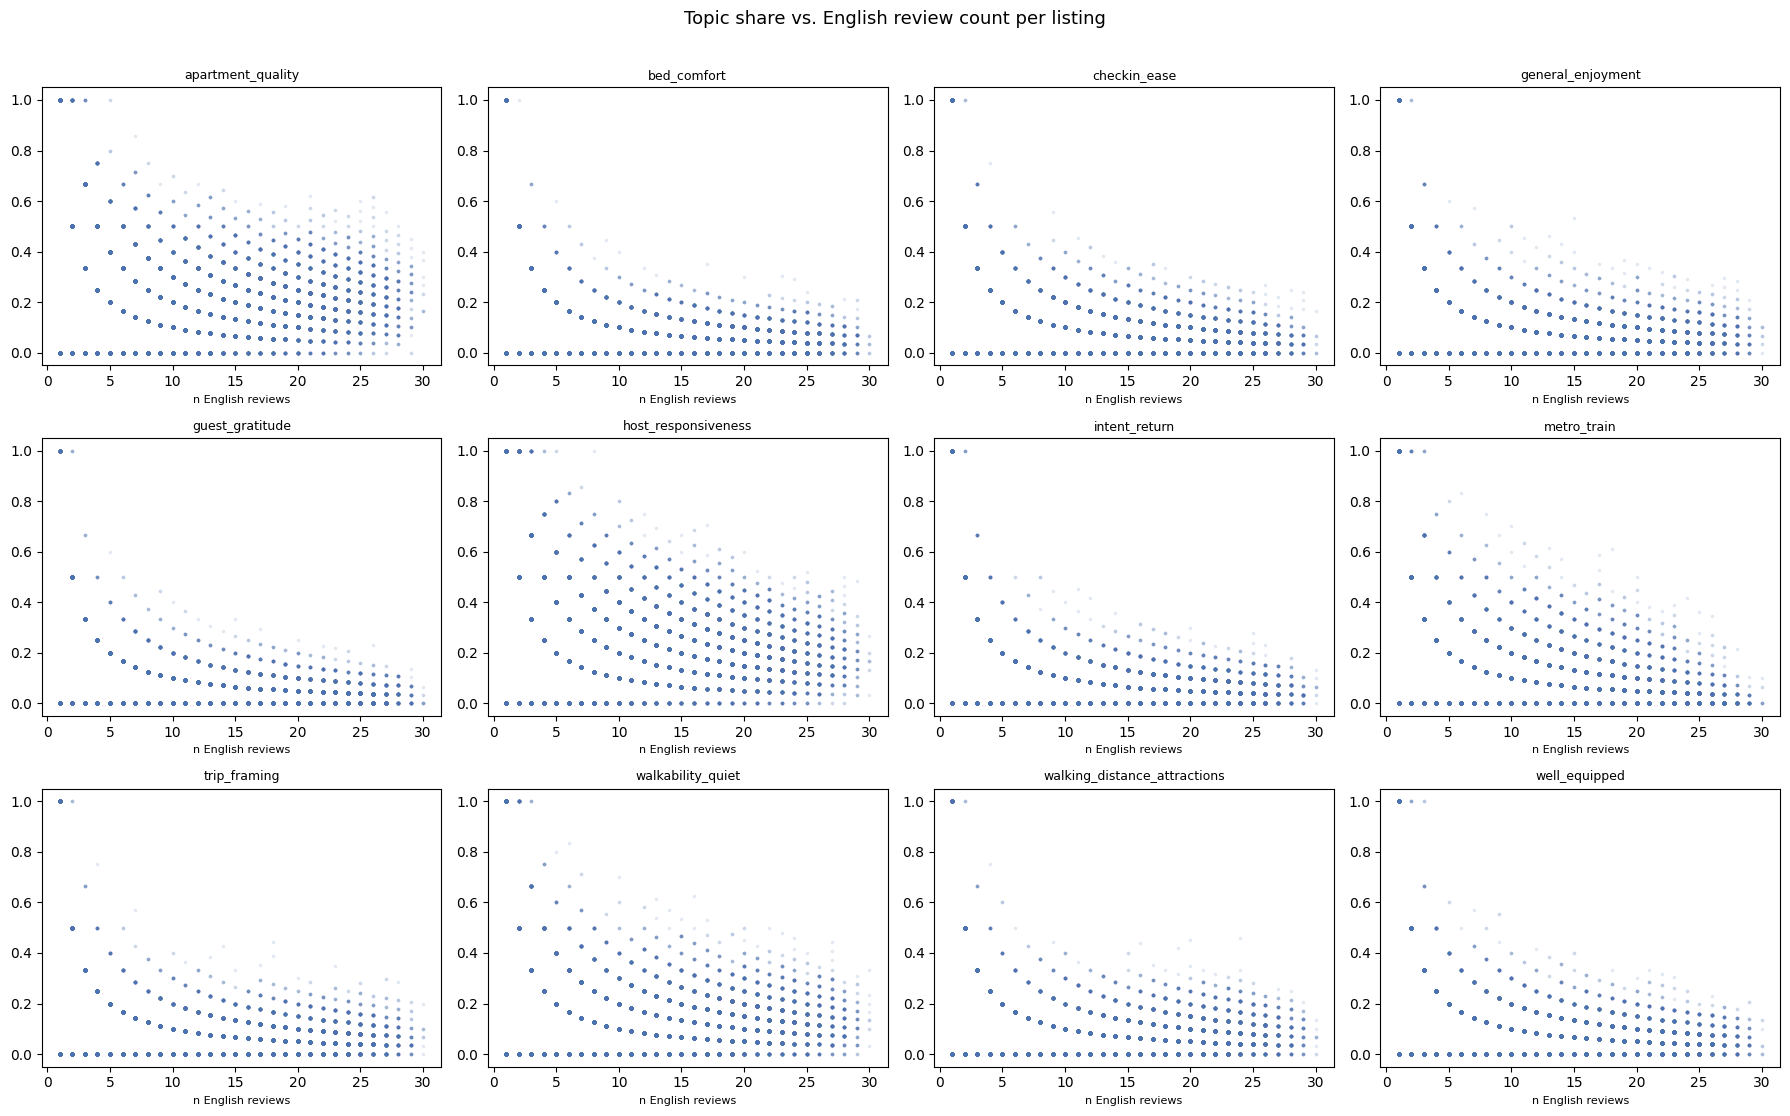

In [54]:
# check if the topic-share zero-inflation is driven by n_english_reviews
listings_nlp['n_english_reviews'] = listings_nlp['id'].map(english_review_counts)

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()
topic_cols = [c for c in listings_nlp.columns if c.startswith('topic_') and c.endswith('_share')]

for ax, col in zip(axes, topic_cols):
    plot_data = listings_nlp.dropna(subset=[col, 'n_english_reviews'])
    ax.scatter(plot_data['n_english_reviews'], plot_data[col], s=3, alpha=0.1, color='#4c72b0')
    ax.set_title(col.replace('topic_', '').replace('_share', ''), fontsize=9)
    ax.set_xlabel('n English reviews', fontsize=8)

plt.suptitle('Topic share vs. English review count per listing', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Observations:**

77.7% of listings retain at least one English review and get computed topic shares. The remaining 22.3% (7,980 listings) trace to the same small-sample mechanism already documented for sentiment coverage. These listings have a median of just 2.0 total reviews (any language), against 28.0 for `reviews_sampled` overall, making an all-non-English draw plausible by chance rather than reflecting a genuine language gap specific to this method.

Topic shares vs. English review count show the same funnel/wedge shape already established for `sentiment_std`: with n reviews, a share can only take values that are multiples of 1/n, so listings with very few English reviews can land anywhere from 0 to 1, while listings near the 30-review cap compress toward a narrower, more stable band.

### 5.3 Description

The same TF-IDF + NMF + UMass coherence pipeline applies, reusing `build_tfidf`/`select_k_via_coherence`/`get_nmf_topics` from §5.1. `descriptions_en` was already prepared in §5.1's corpus-preparation step.

#### 5.3.1 Vectorization & Raw Baseline

In [55]:
tfidf_vec_desc, tfidf_matrix_desc = build_tfidf(descriptions_en['description_cleaned'])
print(f"descriptions TF-IDF matrix: {tfidf_matrix_desc.shape[0]:,} docs x {tfidf_matrix_desc.shape[1]:,} terms")

descriptions TF-IDF matrix: 34,750 docs x 41,944 terms


In [56]:
coherence_results_desc = select_k_via_coherence(tfidf_matrix_desc, tfidf_vec_desc.get_feature_names_out())

k=5: coherence=-1.2064
k=8: coherence=-1.1989
k=10: coherence=-1.3485
k=12: coherence=-1.3495
k=15: coherence=-1.4677
k=20: coherence=-1.3810


In [57]:
for k in [5, 10, 15]:
    nmf = NMF(n_components=k, random_state=42, max_iter=500)
    nmf.fit(tfidf_matrix_desc)
    topics = get_nmf_topics(nmf, tfidf_vec_desc.get_feature_names_out())
    print(f"\n{'='*20} k={k} {'='*20}")
    for i, words in enumerate(topics):
        print(f"topic {i}: {', '.join(words)}")


==================== k=5 ====================
topic 0: minutes, metro, station, walk, meters, san, stop, bus, center, minute
topic 1: room, bed, double, bathroom, living, living room, kitchen, bedroom, equipped, sofa
topic 2: located place, centrally located, centrally, peaceful centrally, relax peaceful, place, peaceful, relax, located, close everything
topic 3: heart, piazza, city, perfect, located, stay, heart rome, historic, steps, ideal
topic 4: whole family, whole, relax whole, family, family quiet, quiet accommodation, relax, accommodation, quiet, stylish

==================== k=10 ====================
topic 0: minutes, station, metro, walk, bus, center, termini, san, stop, restaurants
topic 1: bed, double, living, room, living room, bedroom, sofa, sofa bed, kitchen, large
topic 2: located place, peaceful centrally, centrally located, centrally, relax peaceful, peaceful, place, relax, located, simple peaceful
topic 3: city, perfect, heart, stay, ideal, comfort, experience, eter

Coherence sits noticeably higher than the raw review baseline, consistent with marketing text being more structured and topically focused than conversational reviews. The qualitative output shows the same filler problem, but in a different register: not sentiment-adjacent praise words like "great"/"nice," but generic marketing positioning ("centrally located," "peaceful," "perfect," "ideal") and vocabulary already covered by Part 1's tone lexicons ("family," "quiet," "stylish," which is literally a member of the `luxury` lexicon there). Leaving them in would let topic modeling rediscover signal this project already has a dedicated, validated method for.

#### 5.3.2 Filtering Marketing Filler & Final Model

In [58]:
DESC_FILLER_STOPWORDS = {
    # generic marketing positioning 
    'perfect', 'ideal', 'enjoy', 'space', 'accommodation', 'offers', 'strategic',
    'located', 'easy', 'access', 'heart', 'experience', 'modern', 'comfort',
    'close', 'everything', 'place', 'stay', 'centrally', 'downtown',
    'eternal', 'welcome', 'unforgettable', 'spend', 'thanks', 'group', 'roman', 'one', 'home',
    'vacation', 'relaxing', 'elegant', 'make',
    # idiom fragments
    'stone', 'throw', 'kick', 'calm', 'back',
    # fragmented boilerplate 
    'due', 'entire', 'central', 'location', 'local',
    # already covered by Part 1 tone lexicons / structural features
    'family', 'quiet', 'peaceful', 'relax', 'stylish', 'whole',
}

english_stopwords_desc_filtered = list(set(english_stopwords) | DESC_FILLER_STOPWORDS)
print(f"stopwords: {len(english_stopwords)} base + {len(DESC_FILLER_STOPWORDS)} filler "
      f"= {len(english_stopwords_desc_filtered)} total")

tfidf_vec_desc, tfidf_matrix_desc = build_tfidf(descriptions_en['description_cleaned'], stopwords=english_stopwords_desc_filtered)
print(f"descriptions TF-IDF matrix: {tfidf_matrix_desc.shape[0]:,} docs x {tfidf_matrix_desc.shape[1]:,} terms")

stopwords: 198 base + 49 filler = 247 total
descriptions TF-IDF matrix: 34,750 docs x 38,046 terms


In [59]:
coherence_results_desc = select_k_via_coherence(tfidf_matrix_desc, tfidf_vec_desc.get_feature_names_out())

k=5: coherence=-1.1732
k=8: coherence=-1.4261
k=10: coherence=-1.4019
k=12: coherence=-1.5053
k=15: coherence=-1.5800
k=20: coherence=-1.7520


In [60]:
for k in [8, 10, 12, 15]:
    nmf = NMF(n_components=k, random_state=42, max_iter=500)
    nmf.fit(tfidf_matrix_desc)
    topics = get_nmf_topics(nmf, tfidf_vec_desc.get_feature_names_out())
    print(f"\n{'='*20} k={k} {'='*20}")
    for i, words in enumerate(topics):
        print(f"topic {i}: {', '.join(words)}")


==================== k=8 ====================
topic 0: bed, living, double, living room, bedroom, room, sofa, sofa bed, kitchen, large
topic 1: minutes, station, metro, walk, san, termini, colosseum, minute, stop, 10
topic 2: piazza, navona, piazza navona, di, piazza di, spagna, del, di spagna, trevi, via
topic 3: air, conditioning, air conditioning, fi, wi, wi fi, tv, equipped, free, machine
topic 4: vatican, peter, st, st peter, museums, vatican museums, peter basilica, basilica, angelo, ottaviano
topic 5: city, well, center, historic, trastevere, connected, area, well connected, cozy, restaurants
topic 6: attractions, main, main attractions, tourist attractions, tourist, attractions city, distance, walking distance, walking, main tourist
topic 7: private, room, private bathroom, bathroom, room private, rooms, double, double room, suite, shared

==================== k=10 ====================
topic 0: bed, living, double, living room, bedroom, room, sofa, sofa bed, kitchen, large
top

Coherence drops after filtering, as the words removed were exactly what inflated co-occurrence artificially, so the score now reflects genuine topic separation. k=15 is chosen over k=12 because it resolves real conflation still present at k=12: "building character" (floor/elevator/renovated) and "multi-bedroom" (two bedrooms/bathrooms) only emerge as distinct topics at k=15, folded into other topics below it. The one duplicate at k=15, "near main attractions" and "walking distance to attractions" is merged. Four other transport-adjacent topics (general neighborhood liveliness, walking minutes, exact metro distance in meters, Termini/train/airport) are kept separate, capturing genuinely different angles on the same broad theme.

| Final topic | Source NMF topics (k=15) | Label |
|---|---|---|
| 1 | 2 | Piazza di Spagna / Trevi Fountain |
| 2 | 9 | Navona / Pantheon / Campo de' Fiori |
| 3 | 12 | San Giovanni / Colosseum |
| 4 | 4 | Vatican / museums |
| 5 | 0 | Bedroom layout |
| 6 | 13 | Multi-bedroom, large units |
| 7 | 7 | Room type (private/shared) |
| 8 | 3 | Amenities (wifi/AC/TV) |
| 9 | 5 | Building character (floor/elevator/renovated) |
| 10 | 1 | Neighborhood liveliness |
| 11 | 6, 10 (merged) | Near attractions (general) |
| 12 | 8 | Walking minutes |
| 13 | 11 | Metro distance (meters) |
| 14 | 14 | Termini / train / airport |

#### 5.3.3 Listing-Level Features

Unlike reviews, each listing contributes exactly one description, so there's no aggregation across multiple documents. This makes two representations available at no extra cost: the continuous NMF weight vector (how much a description emphasizes each of the 14 final topics) and a single categorical `dominant_topic` (which theme leads, directly comparable in shape to reviews' `dominant_topic`).

In [61]:
K_FINAL_DESC = 15
nmf_final_desc = NMF(n_components=K_FINAL_DESC, random_state=42, max_iter=500)
doc_topic_weights_desc = nmf_final_desc.fit_transform(tfidf_matrix_desc)

topic_merge_map_desc = {
    0: 'bedroom_layout', 1: 'neighborhood_liveliness', 2: 'piazza_spagna_trevi',
    3: 'amenities_wifi_ac_tv', 4: 'vatican_museums', 5: 'building_character',
    6: 'near_attractions_general', 7: 'room_type_private_shared', 8: 'walk_minutes',
    9: 'navona_pantheon_campo_fiori', 10: 'near_attractions_general',
    11: 'metro_distance_meters', 12: 'san_giovanni_colosseum',
    13: 'multi_bedroom_large', 14: 'termini_train_airport',
}

weights_df_desc = pd.DataFrame(doc_topic_weights_desc, columns=[topic_merge_map_desc[i] for i in range(K_FINAL_DESC)])
merged_weights_desc = weights_df_desc.T.groupby(weights_df_desc.columns).sum().T

descriptions_en = descriptions_en.reset_index(drop=True)
descriptions_en['dominant_topic'] = merged_weights_desc.idxmax(axis=1).values

desc_topic_counts = descriptions_en['dominant_topic'].value_counts()
desc_topic_pct = descriptions_en['dominant_topic'].value_counts(normalize=True).mul(100)
display(pd.DataFrame({'count': desc_topic_counts, 'percentage': desc_topic_pct.round(2)}))

,count,percentage
dominant_topic,,
building_character,5527,15.91
amenities_wifi_ac_tv,3561,10.25
room_type_private_shared,3434,9.88
termini_train_airport,2854,8.21
near_attractions_general,2679,7.71
neighborhood_liveliness,2627,7.56
multi_bedroom_large,2505,7.21
vatican_museums,2179,6.27
bedroom_layout,1959,5.64


In [62]:
weight_sums = merged_weights_desc.sum(axis=1)
normalized_weights_desc = merged_weights_desc.div(weight_sums.replace(0, np.nan), axis=0)
normalized_weights_desc.columns = [f'desc_topic_{c}_weight' for c in normalized_weights_desc.columns]
normalized_weights_desc['id'] = descriptions_en['id'].values

dominant_topic_desc = descriptions_en.set_index('id')['dominant_topic'].rename('desc_dominant_topic')
desc_topic_features = normalized_weights_desc.set_index('id').join(dominant_topic_desc)

existing_desc_cols = [c for c in desc_topic_features.columns if c in listings_nlp.columns]
if existing_desc_cols:
    listings_nlp = listings_nlp.drop(columns=existing_desc_cols)
listings_nlp = listings_nlp.merge(desc_topic_features, left_on='id', right_index=True, how='left')

n_with_desc_topics = listings_nlp['desc_dominant_topic'].notna().sum()
print(f"listings with description topic features: {n_with_desc_topics:,} / {len(listings_nlp):,} "
      f"({n_with_desc_topics/len(listings_nlp)*100:.1f}%)")

listings with description topic features: 34,750 / 35,818 (97.0%)


In [63]:
weight_cols = [c for c in listings_nlp.columns if c.startswith('desc_topic_') and c.endswith('_weight')]
weight_summary = pd.DataFrame({
    col: {'mean': listings_nlp[col].mean(), 'median': listings_nlp[col].median(),
          'pct_zero': (listings_nlp[col] == 0).mean() * 100}
    for col in weight_cols
}).T
display(weight_summary.round(3))

,mean,median,pct_zero
desc_topic_amenities_wifi_ac_tv_weight,0.080,0.000,48.196
desc_topic_bedroom_layout_weight,0.063,0.001,46.362
desc_topic_building_character_weight,0.170,0.099,18.884
desc_topic_metro_distance_meters_weight,0.058,0.003,45.628
desc_topic_multi_bedroom_large_weight,0.077,0.011,42.138
desc_topic_navona_pantheon_campo_fiori_weight,0.034,0.000,60.620
desc_topic_near_attractions_general_weight,0.063,0.002,43.707
desc_topic_neighborhood_liveliness_weight,0.091,0.030,35.348
desc_topic_piazza_spagna_trevi_weight,0.050,0.000,56.790
desc_topic_room_type_private_shared_weight,0.094,0.014,40.898


`dominant_topic` distribution (15.91% `building_character` down to 3.55% `walk_minutes`) is meaningfully more balanced than reviews', as no single topic dominates the way merged `host_responsiveness`/`apartment_quality` did there.

All 14 continuous weight columns are zero-inflated (18.9%-61.5% zero), as a single ~50-150 word description realistically emphasizes only 1-3 of 14 possible themes, so most topic weights being exactly zero for most listings is the natural shape of the data, the same zero-inflation pattern already documented throughout this project's tone lexicons and sentiment category shares.

### 5.4 Validation & Diagnostics

#### 5.4.1 Content Validity: Description Topics vs. Landmark Gazetteer

A sharper test than "landmark-named topics mention landmarks more" (which could pass even if the topics are semantically muddled): for each of the four landmark-named topics, do the *specific* landmarks Part 1's gazetteer found in that listing's description actually match the landmark the topic is named for? If `piazza_spagna_trevi`-dominated listings mostly mention Trevi Fountain/Spanish Steps specifically (not landmarks in general), that's real, surgical confirmation the topic captures genuine content, not an artifact.

In [64]:
import ast

def parse_landmark_tags(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return []

listings_nlp['description_landmark_tags_parsed'] = listings_nlp['description_landmark_tags'].apply(parse_landmark_tags)

LANDMARK_TOPICS = {'piazza_spagna_trevi', 'vatican_museums', 'san_giovanni_colosseum', 'navona_pantheon_campo_fiori'}

landmark_topic_tags = {}
for topic in sorted(LANDMARK_TOPICS):
    mask = listings_nlp['desc_dominant_topic'] == topic
    tags = listings_nlp.loc[mask, 'description_landmark_tags_parsed'].explode().dropna()
    landmark_topic_tags[topic] = tags.value_counts().head(5)
    print(f"\n{topic} (n={mask.sum():,}) — top actual landmark tags:")
    print(landmark_topic_tags[topic])


navona_pantheon_campo_fiori (n=1,257) — top actual landmark tags:
description_landmark_tags_parsed
piazza_navona         906
campo_de_fiori        446
vatican_city          205
castel_sant_angelo    157
colosseum             125
Name: count, dtype: int64

piazza_spagna_trevi (n=1,815) — top actual landmark tags:
description_landmark_tags_parsed
piazza_di_spagna     979
trevi_fountain       788
piazza_del_popolo    537
colosseum            397
vatican_city         302
Name: count, dtype: int64

san_giovanni_colosseum (n=1,599) — top actual landmark tags:
description_landmark_tags_parsed
colosseum               744
santa_maria_maggiore    238
vatican_city            100
circus_maximus           78
esquiline_hill           55
Name: count, dtype: int64

vatican_museums (n=2,179) — top actual landmark tags:
description_landmark_tags_parsed
vatican_city           1684
st_peter_s_basilica     597
castel_sant_angelo      350
piazza_navona           150
colosseum               107
Name: count,

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_19198/2191298978.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  listings_nlp['description_landmark_tags_parsed'] = listings_nlp['description_landmark_tags'].apply(parse_landmark_tags)


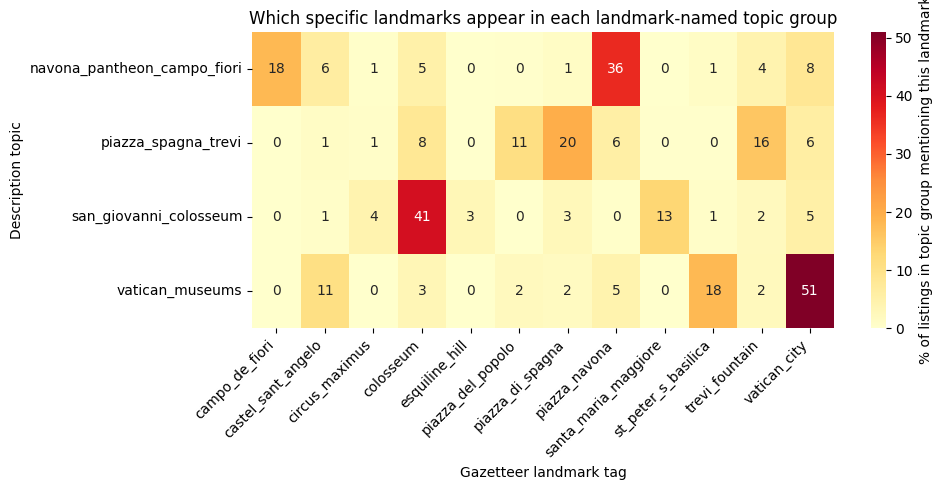

In [65]:
all_top_tags = sorted(set(tag for s in landmark_topic_tags.values() for tag in s.index))

heatmap_data = pd.DataFrame(index=sorted(LANDMARK_TOPICS), columns=all_top_tags, dtype=float)
for topic in LANDMARK_TOPICS:
    mask = listings_nlp['desc_dominant_topic'] == topic
    tags = listings_nlp.loc[mask, 'description_landmark_tags_parsed'].explode().dropna()
    tag_pct = tags.value_counts(normalize=True) * 100
    for tag in all_top_tags:
        heatmap_data.loc[topic, tag] = tag_pct.get(tag, 0)

fig, ax = plt.subplots(figsize=(max(10, len(all_top_tags)*0.6), 5))
sns.heatmap(heatmap_data.astype(float), annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label': '% of listings in topic group mentioning this landmark'}, ax=ax)
ax.set_title('Which specific landmarks appear in each landmark-named topic group')
ax.set_xlabel('Gazetteer landmark tag')
ax.set_ylabel('Description topic')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observations:**

Every landmark-named topic lights up brightest on its own corresponding gazetteer tag, not a neighboring or unrelated one: `san_giovanni_colosseum` peaks at Colosseum (41%, the single brightest cell on the map), `vatican_museums` at Vatican City (51%, the map's overall maximum) with St. Peter's Basilica a sensible secondary peak (11%, geographically adjacent), `piazza_spagna_trevi` splits fairly evenly between Piazza di Spagna and Trevi Fountain (both real, walkable neighbors of each other), and `navona_pantheon_campo_fiori` peaks at Piazza Navona specifically (18%). This is a direct, surgical confirmation that NMF recovered genuine geographic content, not an artifact of shared vocabulary — the topic model was never told which landmarks exist; it discovered clusters purely from word co-occurrence, and those clusters turned out to align with an entirely independent, Wikidata-sourced ground truth built in Part 1.

Off-diagonal values are consistently low but non-zero and directionally sensible: Colosseum appears as the second-largest signal in three of the four topic groups (18%, 8%, and 5% outside its own row), plausible given it's Rome's single most iconic, most frequently mentioned landmark regardless of which specific neighborhood a listing is actually in. Vatican City shows the same pattern in reverse, appearing as background noise across multiple groups. The two most universally recognizable landmarks in the corpus leak modestly into every topic, exactly the kind of noise expected from short, keyword-dense marketing text rather than a sign the topics are poorly separated.

#### 5.4.2 Host Framing vs. Guest Experience

The section's central thesis, tested directly: does what a host emphasizes in the description predict what guests actually talk about? A row-normalized cross-tab shows, for each host marketing theme, the full distribution of what guests discuss instead of collapsing it to a single match/mismatch statistic.

In [66]:
review_topic_share_cols = [c for c in listings_nlp.columns if c.startswith('topic_') and c.endswith('_share')]
has_review_topics = listings_nlp[review_topic_share_cols].notna().all(axis=1)

dominant_topic_raw = (
    listings_nlp.loc[has_review_topics, review_topic_share_cols]
    .idxmax(axis=1)
    .str.replace('topic_', '', regex=False)
    .str.replace('_share', '', regex=False)
)

listings_nlp['review_dominant_topic'] = dominant_topic_raw.reindex(listings_nlp.index)

print(f"listings with review_dominant_topic: {listings_nlp['review_dominant_topic'].notna().sum():,}")

listings with review_dominant_topic: 27,838


/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_19198/1258267968.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  listings_nlp['review_dominant_topic'] = dominant_topic_raw.reindex(listings_nlp.index)


In [67]:
joint_coverage = listings_nlp[['desc_dominant_topic', 'review_dominant_topic']].notna().all(axis=1).sum()
print(f"listings with both desc_dominant_topic and review_dominant_topic: {joint_coverage:,}")

listings with both desc_dominant_topic and review_dominant_topic: 27,031


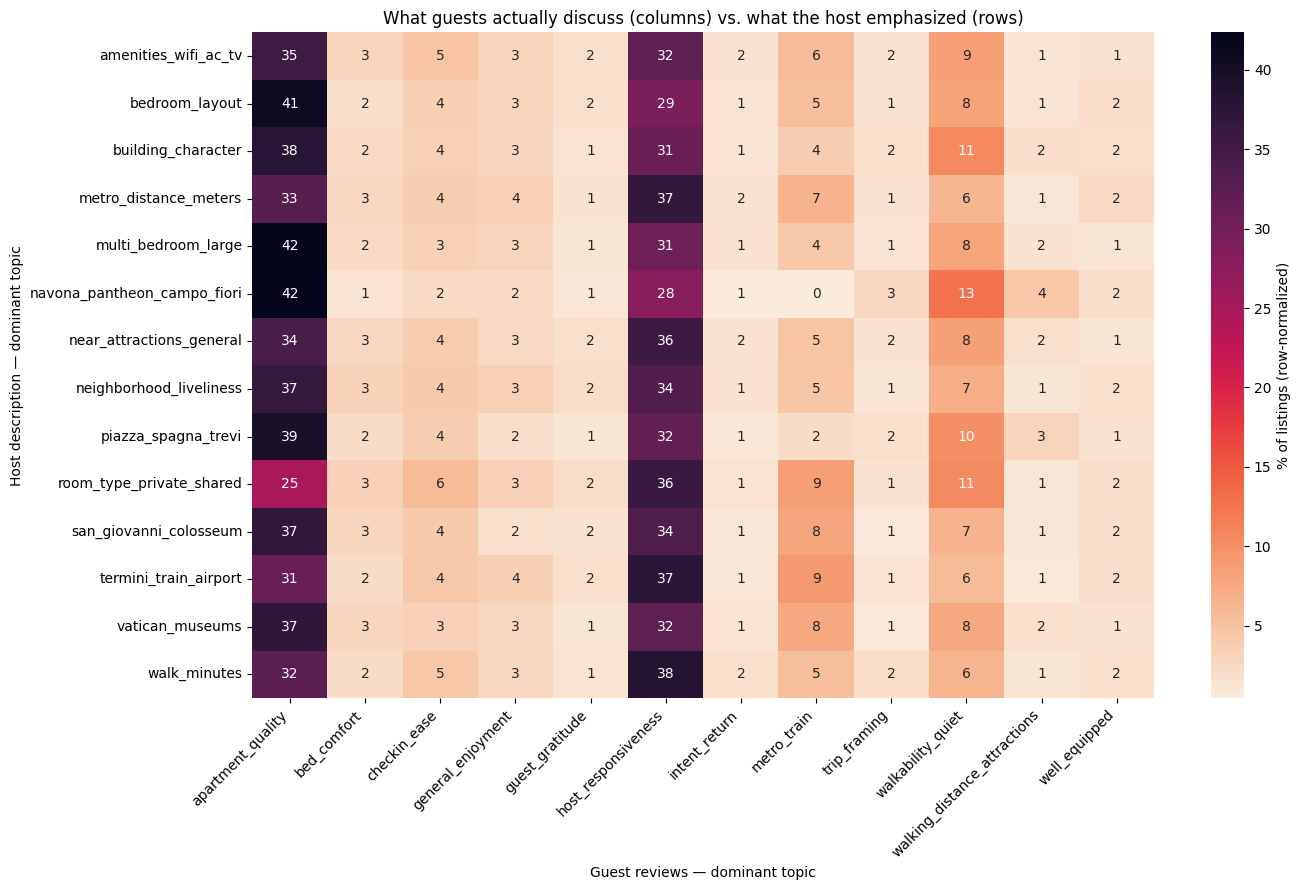

In [68]:
cross_tab = pd.crosstab(listings_nlp['desc_dominant_topic'], listings_nlp['review_dominant_topic'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(cross_tab, annot=True, fmt='.0f', cmap='rocket_r', cbar_kws={'label': '% of listings (row-normalized)'}, ax=ax)
ax.set_title('What guests actually discuss (columns) vs. what the host emphasized (rows)')
ax.set_xlabel('Guest reviews — dominant topic')
ax.set_ylabel('Host description — dominant topic')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_19198/4259373541.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='review_dominant_topic', y='sentiment_mean', order=order, ax=ax, palette='viridis')


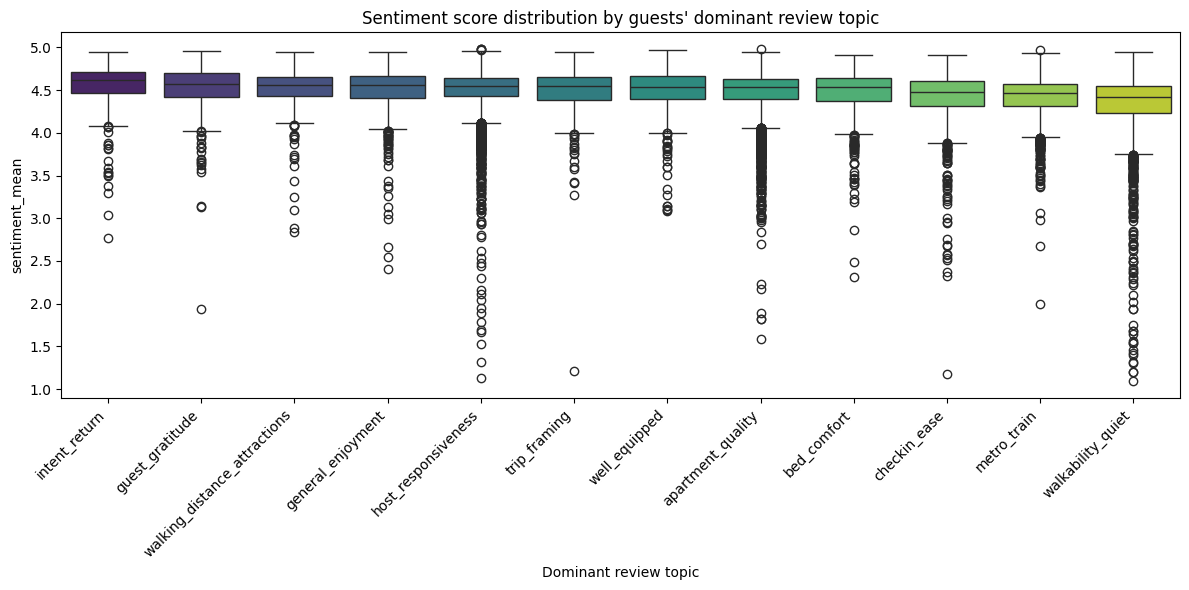

In [69]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_data = listings_nlp.dropna(subset=['review_dominant_topic', 'sentiment_mean'])
order = plot_data.groupby('review_dominant_topic')['sentiment_mean'].median().sort_values(ascending=False).index
sns.boxplot(data=plot_data, x='review_dominant_topic', y='sentiment_mean', order=order, ax=ax, palette='viridis')
ax.set_title("Sentiment score distribution by guests' dominant review topic")
ax.set_xlabel('Dominant review topic')
ax.set_ylabel('sentiment_mean')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observations:**

The row-normalized cross-tab shows no clean, direct link between what a host emphasizes in their description and what guests' single dominant review topic turns out to be and every row peaks in the same two columns (`apartment_quality`, `host_responsiveness`) regardless of the host's actual framing. This traces back to a mechanism flagged previously: because these two labels are merges of two and three raw NMF topics respectively, they carry a systematically higher base rate as a `dominant_topic` outcome for nearly any listing, which likely masks weaker but real correlations between host framing and guest focus rather than indicating none exists.

`sentiment_mean` by dominant review topic shows topic and sentiment behaving largely as designed. Medians cluster tightly (~4.4-4.65) across nearly every topic, consistent with the corpus-wide positive skew. The one topic with a visibly wider, denser negative-outlier spread is `host_responsiveness`, plausible given the topic groups both delighted and frustrated guests under the same subject-matter label (NMF clusters by *what* is discussed, not sentiment polarity), so complaints about an unresponsive host land in the same bucket as praise for a helpful one. `walkability_quiet` has the lowest median and reaches the lowest outliers, plausibly reflecting genuine noise complaints as a distinct negative-review category.

#### 5.4.3 Internal Structure

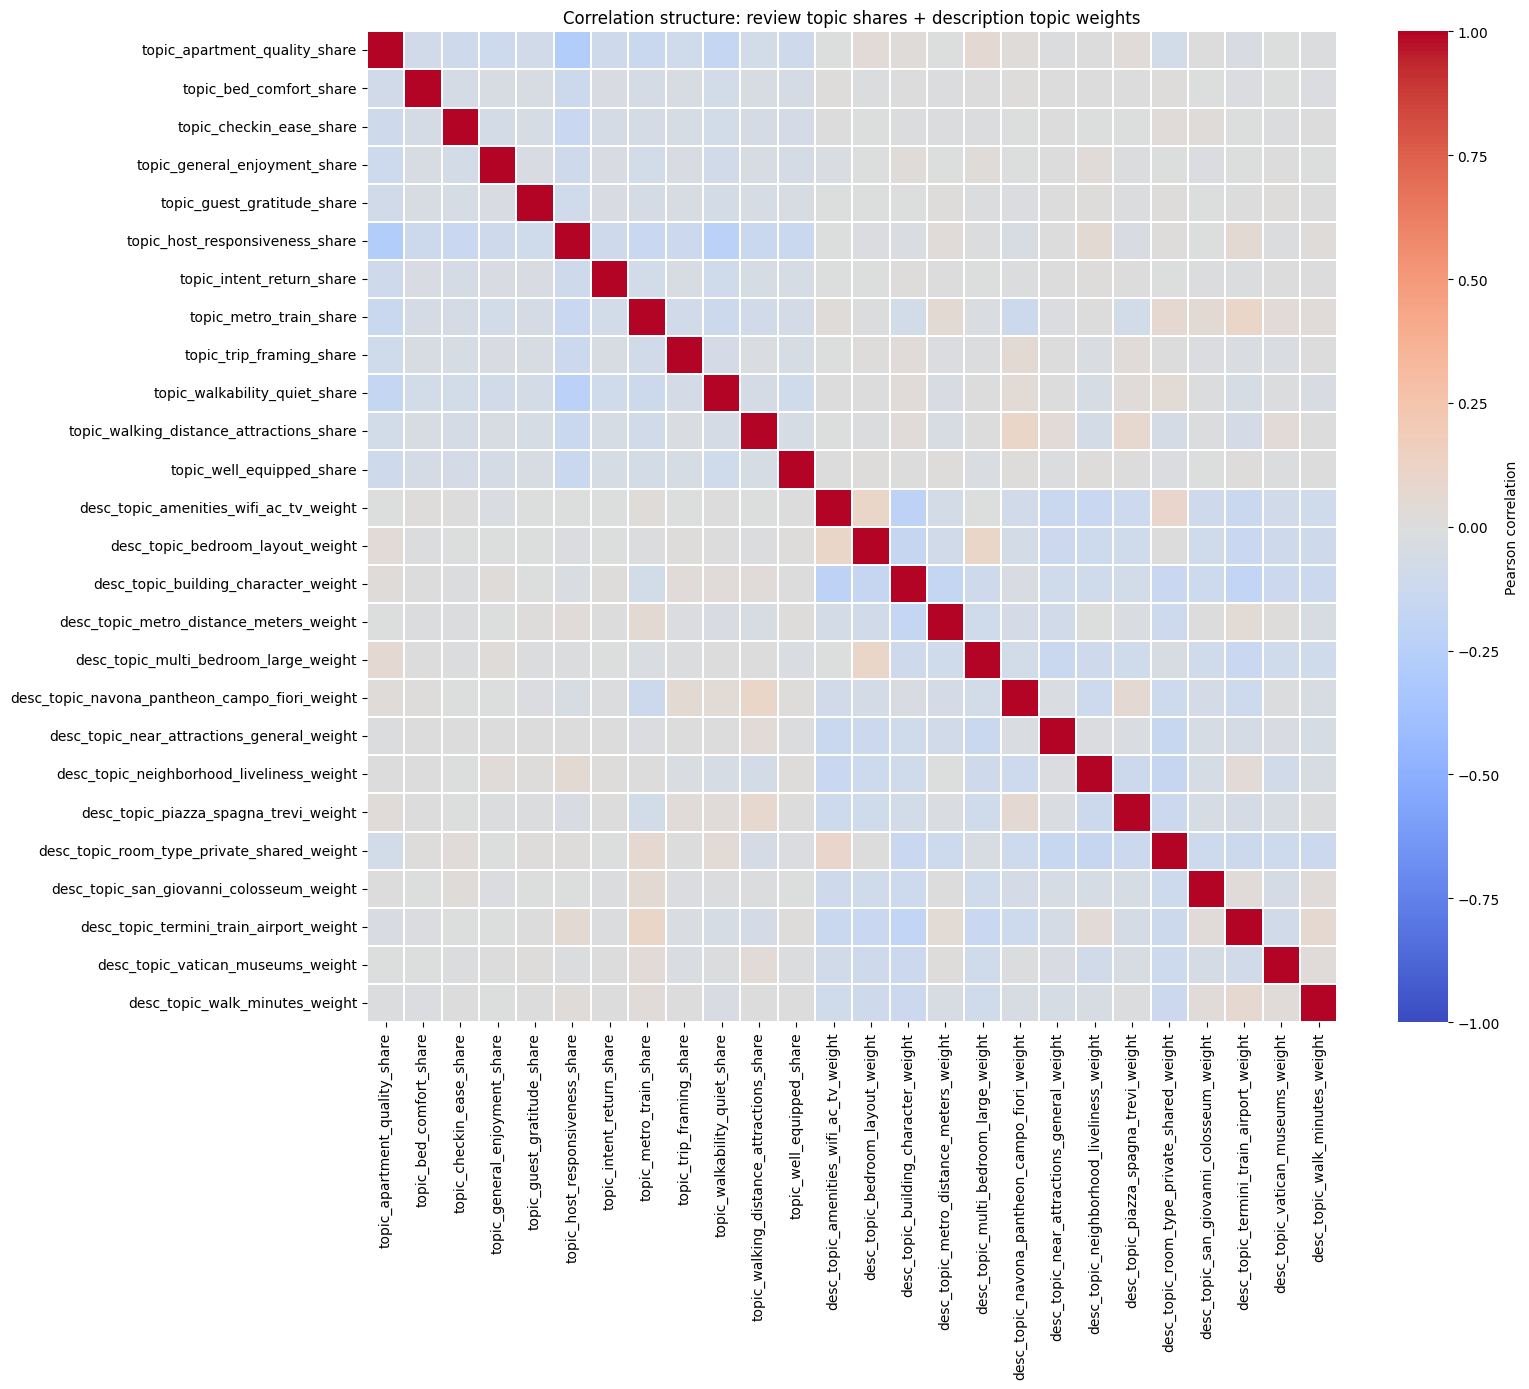

In [70]:
topic_feature_cols = (
    [c for c in listings_nlp.columns if c.startswith('topic_') and c.endswith('_share')] +
    [c for c in listings_nlp.columns if c.startswith('desc_topic_') and c.endswith('_weight')]
)

corr_matrix = listings_nlp[topic_feature_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            annot=False, linewidths=0.3, cbar_kws={'label': 'Pearson correlation'}, ax=ax)
ax.set_title('Correlation structure: review topic shares + description topic weights')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

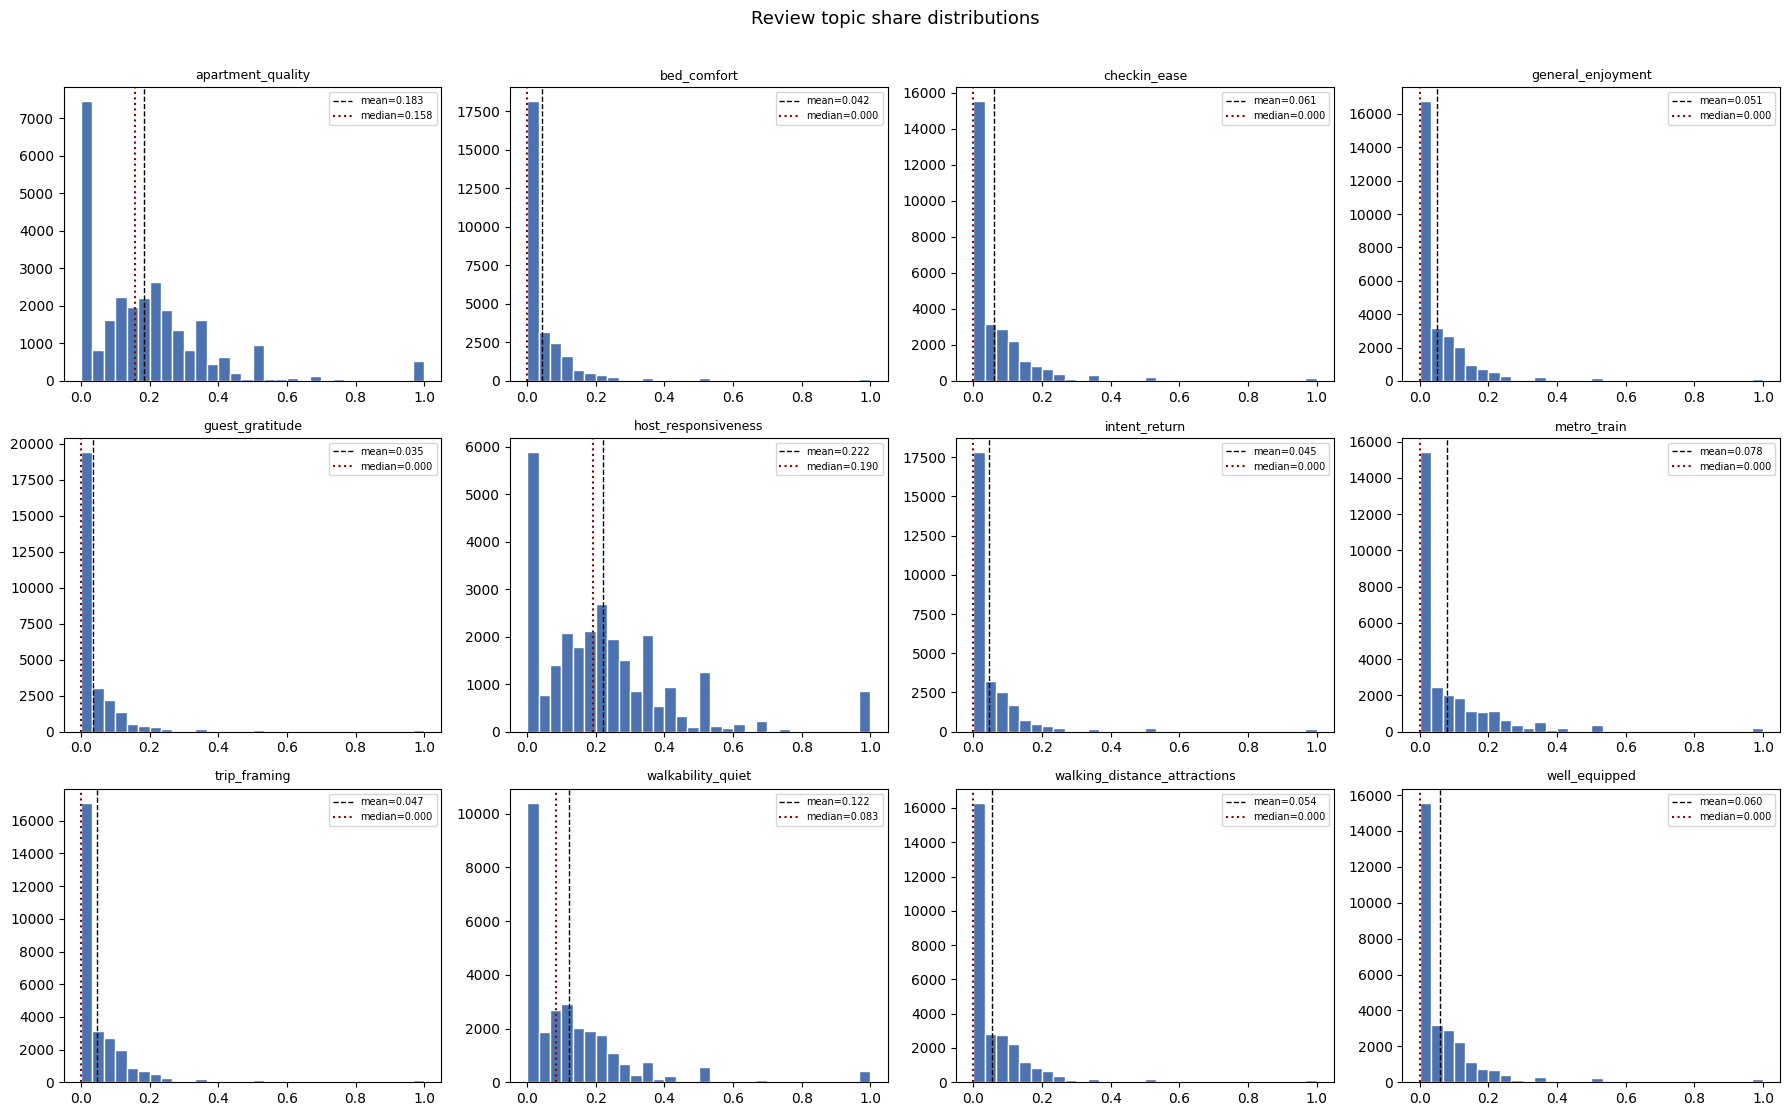

In [71]:
review_share_cols = [c for c in listings_nlp.columns if c.startswith('topic_') and c.endswith('_share')]

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

for ax, col in zip(axes, review_share_cols):
    data = listings_nlp[col].dropna()
    ax.hist(data, bins=30, color='#4c72b0', edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={data.mean():.3f}')
    ax.axvline(data.median(), color='darkred', linestyle=':', linewidth=1.5, label=f'median={data.median():.3f}')
    ax.set_title(col.replace('topic_', '').replace('_share', ''), fontsize=9)
    ax.legend(fontsize=7)

for ax in axes[len(review_share_cols):]:
    ax.set_visible(False)

plt.suptitle('Review topic share distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

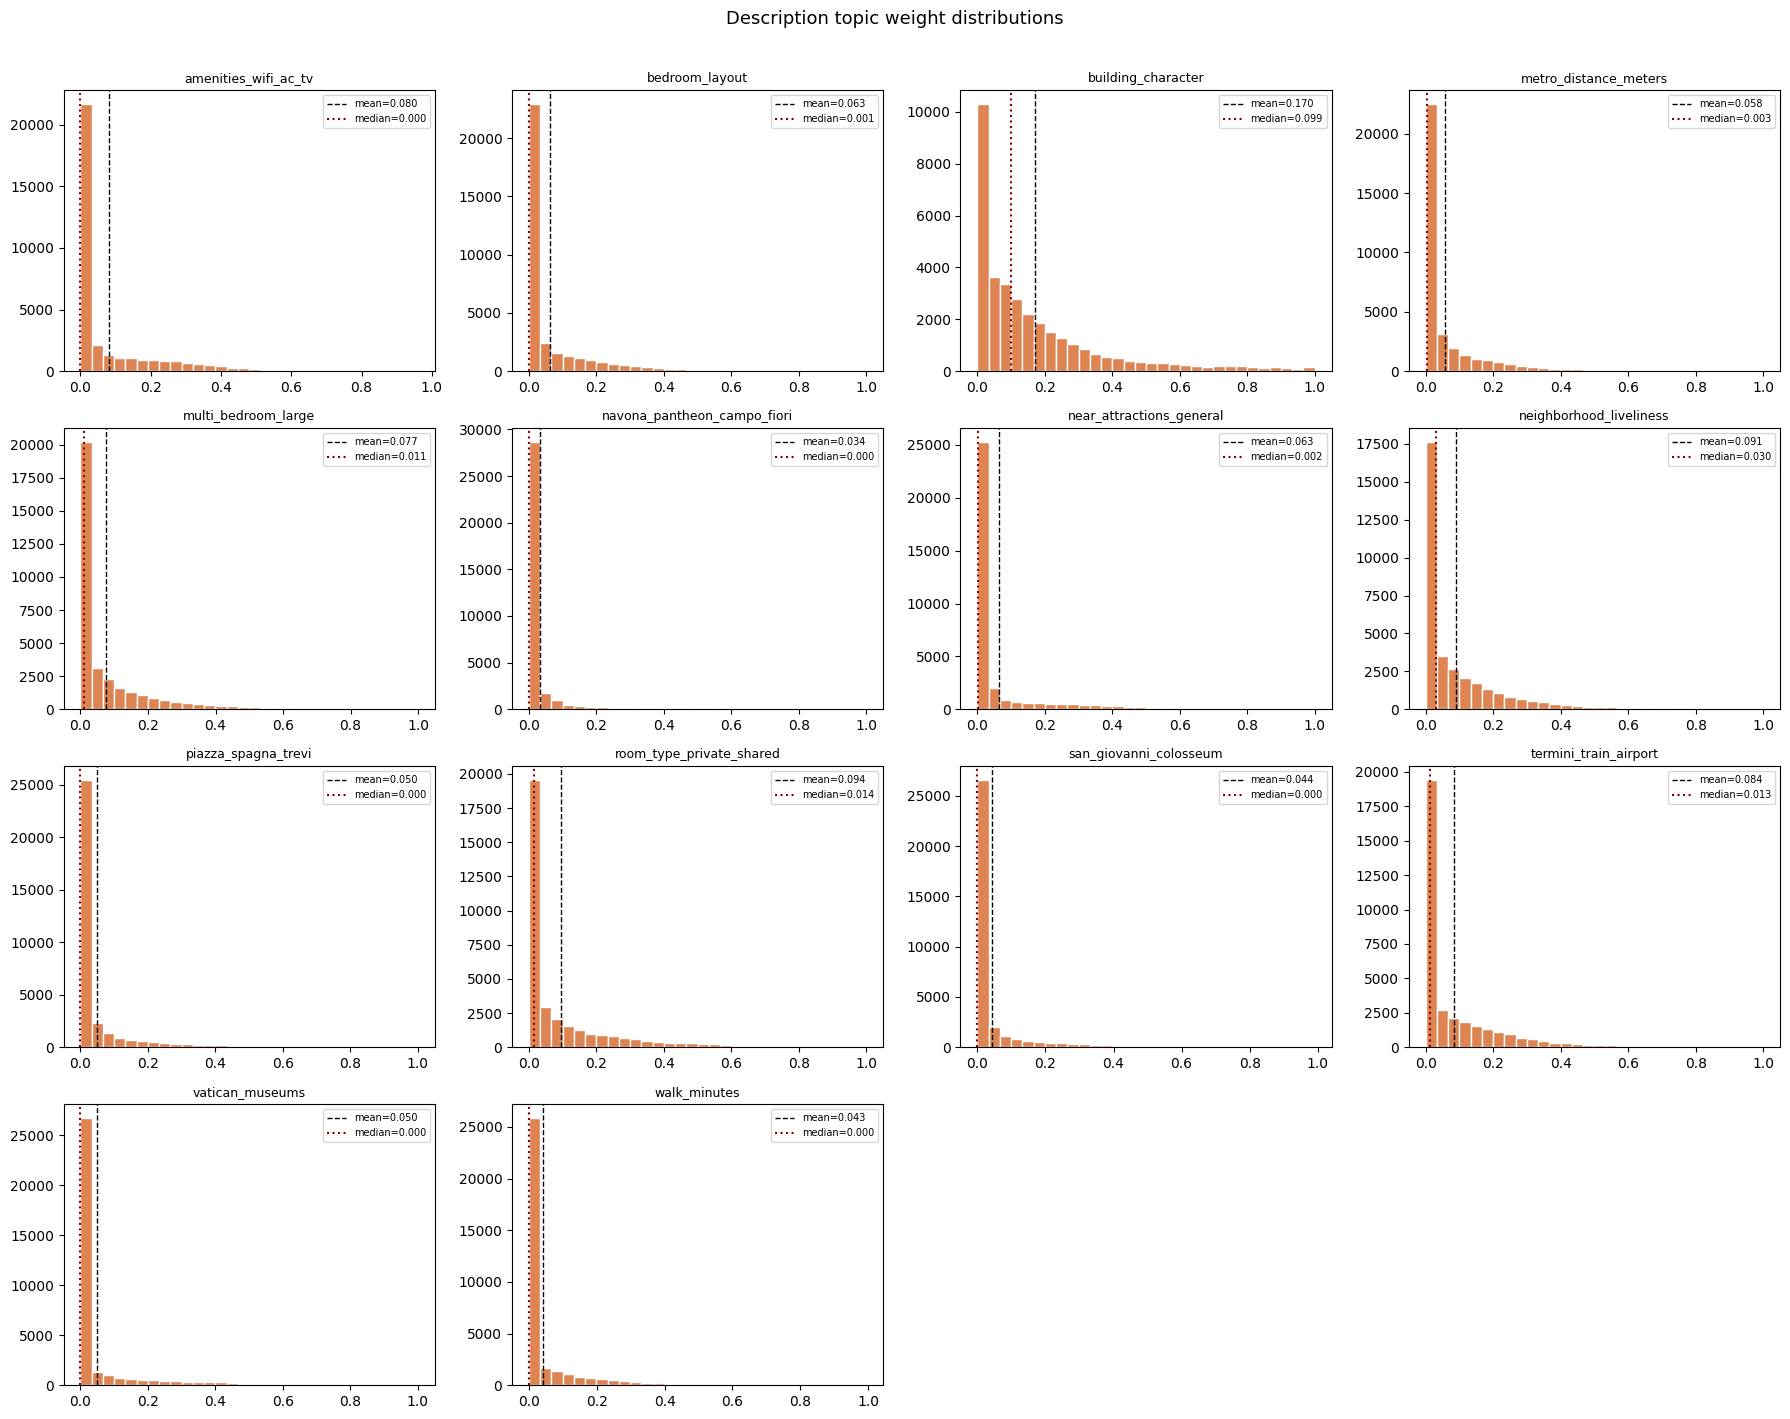

In [72]:
desc_weight_cols = [c for c in listings_nlp.columns if c.startswith('desc_topic_') and c.endswith('_weight')]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for ax, col in zip(axes, desc_weight_cols):
    data = listings_nlp[col].dropna()
    ax.hist(data, bins=30, color='#dd8452', edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={data.mean():.3f}')
    ax.axvline(data.median(), color='darkred', linestyle=':', linewidth=1.5, label=f'median={data.median():.3f}')
    ax.set_title(col.replace('desc_topic_', '').replace('_weight', ''), fontsize=9)
    ax.legend(fontsize=7)

for ax in axes[len(desc_weight_cols):]:
    ax.set_visible(False)

plt.suptitle('Description topic weight distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Observations:**

Both feature sets are heavily zero-inflated, consistent with every other density/share variable already documented in this project, but the *shape* of that zero-inflation differs meaningfully between the two corpora for structural reasons.

Review topic shares (median 0.000) are zero-inflated for 9 of 12 topics; only `apartment_quality` (0.158), `host_responsiveness` (0.190), and `walkability_quiet` (0.083) carry a genuinely non-zero central tendency, unsurprising for the first two, since both are merges of multiple raw NMF components and inherit a correspondingly higher base rate. Several histograms show a visible spike exactly at 1.0 (`host_responsiveness`, `intent_return`, `trip_framing`, `walkability_quiet`), which are the same small-*n* funnel effect already established in §5.2's scatter plots: a listing with very few English reviews can land at a share of exactly 1.0 by chance alone, and the discrete, stepped look of these histograms overall (visible individual bars rather than a smooth curve) is a direct fingerprint of shares being fractions of a small integer count (1/3, 1/2, 2/3...).

Description topic weights are zero-inflated even more uniformly, as 13 of 14 topics sit at median 0.000, with `building_character` (0.099) being the exception, consistent with its already-largest share of `dominant_topic` (15.91%). Unlike reviews, none of these curves show a ceiling spike at 1.0, and every decay is smooth rather than stepped: since each weight is a continuous NMF output over a single ~50-150 word document, there's no small-sample quantization to produce discrete jumps.

Both sets of variables are strong candidates for the same zero-inflation treatment already applied throughout this project (binary flags or tiered binning per column).

### 5.5 Topic Modelling Conclusion

This section built two independent topic models to test whether host-written framing emphasizes different themes than what guests actually report experiencing, working through four stages:

- **Corpus preparation**: both corpora restricted to English text, since TF-IDF has no notion of meaning and would otherwise risk NMF discovering language clusters rather than content topics. This cost descriptions almost nothing (97.0% English already) but excluded roughly half of reviews (52.3%), which is an explicit, stated limitation, and the direct motivation for treating a multilingual BERTopic pass as a stretch goal.

- **Reviews**: an iterative filtering process. The raw run was dominated by generic praise ("great"/"nice"/"good"/"perfect") fragmenting the corpus by compliment word rather than content, traced directly to §4's finding that the corpus is overwhelmingly positive, meaning sentiment tone was already captured elsewhere and didn't need rediscovering here. After filtering, k=15 was chosen over the coherence-favored k=8 specifically because UMass coherence is documented as systematically biased toward smaller k, and the qualitative topics confirmed it: lower k conflated genuinely distinct concepts (transport bundled with check-in ease), a problem only fixable by increasing k, while k=15's cost was cheaper-to-fix duplication (host responsiveness split into three near-identical topics). Merging duplicates yielded 12 final content topics, aggregated to listing-level shares for 77.7% of listings. The remaining 22.3% traced to the same small-review-count mechanism already established for sentiment coverage.

- **Descriptions**: the same pipeline, adapted to a structurally different corpus with higher baseline coherence (more focused marketing register), but its own filler category unique to short marketing text: idiom fragments that shatter into disconnected words under n-gram tokenization and get mistaken for coherent topics. The final model (k=15, one duplicate merged) yielded 14 topics, computed for 97.0% of listings, which is a cleaner coverage than reviews since a description is either present in English or not, with no sampling randomness. Because each listing has exactly one description, both a continuous topic-weight vector and a categorical `dominant_topic` were retained.

- **Validation**: three independent checks. Landmark-named description topics passed a direct, surgical content-validity test, as each one's dominant NMF theme aligned with the *specific* landmark Part 1's independently-built, Wikidata-sourced gazetteer found in the same listings (e.g., `san_giovanni_colosseum` peaking at 41% on the Colosseum tag specifically), confirming NMF recovered genuine geography from word co-occurrence alone. The section's central thesis (host framing predicting guest focus) did not hold up cleanly under a row-normalized cross-tab: every host topic's guests defaulted to the same two merged, high-base-rate review topics, an artifact of the merge step's uneven topic sizes rather than confirmed evidence the thesis is false. Internal correlation structure showed no redundancy needing further reduction, and distribution shape differed instructively between corpora: reviews' topic shares show a discrete, stepped pattern (a direct fingerprint of being fractions of small per-listing review counts) while description weights decay relatively smoothly.

## 6. Embeddings

Sentiment captured *how* listings are perceived, Topic Modeling (§5) captured *what* hosts and guests talk about, but only in English. This section asks the same underlying research question: "does text carry structure beyond the tabular feature set?" through a genuinely multilingual lens, using `paraphrase-multilingual-MiniLM-L12-v2` to embed the full `reviews_sampled` corpus, not just its English half.

Two downstream products come from the same embeddings, serving different purposes: a PCA-reduced numeric feature block and a separate UMAP + HDBSCAN categorical "text persona" label. Validation here differs from every prior section: the method exists specifically to find structure the existing tone/topic/sentiment features don't already capture, so the right check is cluster profiling against those existing variables.

### 6.1 Model Loading & Environment Setup

In [73]:
from sentence_transformers import SentenceTransformer

EMBED_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"

embed_model = SentenceTransformer(EMBED_MODEL_NAME, cache_folder=str(HF_CACHE_DIR), device=DEVICE)

print(f"model loaded: {EMBED_MODEL_NAME}")
print(f"embedding dimension: {embed_model.get_embedding_dimension()}")
print(f"max sequence length (tokens): {embed_model.max_seq_length}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6583.95it/s]


model loaded: paraphrase-multilingual-MiniLM-L12-v2
embedding dimension: 384
max sequence length (tokens): 128


### 6.2 Embedding Inference

Unlike sentiment or topic modeling, embeddings run on the *entire* `reviews_sampled` corpus regardless of language. This is the one method in this project with no language-coverage caveat, the direct payoff of choosing a multilingual model. Inference follows the same chunked, resumable pattern established for sentiment, with the same `review_index` safeguard.

In [74]:
EMBED_CHUNK_SIZE = 20_000
EMBED_OUTPUT_DIR = BASE_PATH / 'data' / 'embedding_chunks'
EMBED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

n_chunks = (len(reviews_sampled) + EMBED_CHUNK_SIZE - 1) // EMBED_CHUNK_SIZE
print(f"{len(reviews_sampled):,} reviews -> {n_chunks} chunks of up to {EMBED_CHUNK_SIZE:,} each")

for chunk_idx in range(n_chunks):
    chunk_path = EMBED_OUTPUT_DIR / f'chunk_{chunk_idx:03d}.npz'
    if chunk_path.exists():
        continue

    start_idx = chunk_idx * EMBED_CHUNK_SIZE
    end_idx = min(start_idx + EMBED_CHUNK_SIZE, len(reviews_sampled))
    chunk = reviews_sampled.iloc[start_idx:end_idx]

    chunk_start_time = time.time()
    embeddings = embed_model.encode(
        chunk['comments_clean'].tolist(),
        batch_size=128,
        show_progress_bar=False,
        convert_to_numpy=True,
    )
    chunk_elapsed = time.time() - chunk_start_time

    np.savez_compressed(chunk_path, review_index=chunk.index.values, embeddings=embeddings)

    print(f"chunk {chunk_idx + 1}/{n_chunks} done in {chunk_elapsed/60:.1f} min "
          f"({(chunk_idx + 1) * EMBED_CHUNK_SIZE / len(reviews_sampled) * 100:.1f}% overall)")

604,821 reviews -> 31 chunks of up to 20,000 each


In [75]:
EMBED_OUTPUT_DIR = BASE_PATH / 'data' / 'embedding_chunks'
chunk_files = sorted(EMBED_OUTPUT_DIR.glob('chunk_*.npz'))
print(f"{len(chunk_files)} chunk files")

all_review_indices = []
all_embeddings = []
for f in chunk_files:
    data = np.load(f)
    all_review_indices.append(data['review_index'])
    all_embeddings.append(data['embeddings'])

review_indices = np.concatenate(all_review_indices)
embeddings_matrix = np.vstack(all_embeddings)

print(f"total embeddings: {embeddings_matrix.shape[0]:,} x {embeddings_matrix.shape[1]} dims")
print(f"len of reviews_sampled: {len(reviews_sampled):,}")

assert embeddings_matrix.shape[0] == len(reviews_sampled), "row count mismatch — investigate before proceeding"

order = np.argsort(review_indices)
review_indices_sorted = review_indices[order]
embeddings_sorted = embeddings_matrix[order]

index_match = np.array_equal(review_indices_sorted, reviews_sampled.index.sort_values().values)
print(f"review_index fully covers reviews_sampled: {index_match}")

31 chunk files
total embeddings: 604,821 x 384 dims
len of reviews_sampled: 604,821
review_index fully covers reviews_sampled: True


### 6.3 Listing-Level Aggregation

Per-review embeddings are averaged into a single 384-dimensional vector per listing by embedding each review independently, then mean-pooling the resulting vectors. A companion `n_embedded_reviews` count is kept alongside, mirroring `n_valid_sentiment`'s role: no `unavailable` category is needed here, since embeddings carry no language restriction, but a listing's vector is naturally less stable when averaged over just 1-2 reviews than over 30.

In [76]:
# explicit positional alignment via reindex
position_lookup = pd.Series(np.arange(len(review_indices)), index=review_indices)
reorder_positions = position_lookup.reindex(reviews_sampled.index).values

assert not np.isnan(reorder_positions).any(), "some reviews_sampled rows have no matching embedding"
reorder_positions = reorder_positions.astype(int)

embeddings_aligned = embeddings_matrix[reorder_positions]
print(f"aligned embeddings: {embeddings_aligned.shape}")

aligned embeddings: (604821, 384)


In [77]:
embed_cols = [f'emb_{i}' for i in range(embeddings_aligned.shape[1])]
embed_df = pd.DataFrame(embeddings_aligned, columns=embed_cols, index=reviews_sampled.index)
embed_df['listing_id'] = reviews_sampled['listing_id'].values

listing_embeddings = embed_df.groupby('listing_id')[embed_cols].mean()
n_embedded_reviews = embed_df.groupby('listing_id').size().rename('n_embedded_reviews')
listing_embeddings = listing_embeddings.join(n_embedded_reviews)

print(f"listing-level embeddings: {listing_embeddings.shape[0]:,} listings x {len(embed_cols)} dims")
print(f"n_embedded_reviews — min: {n_embedded_reviews.min()}, median: {n_embedded_reviews.median()}, max: {n_embedded_reviews.max()}")

listing-level embeddings: 30,713 listings x 384 dims
n_embedded_reviews — min: 1, median: 28.0, max: 30


In [78]:
total_listings = listings_nlp['id'].nunique()
print(f"listings with embeddings: {listing_embeddings.shape[0]:,} / {total_listings:,} "
      f"({listing_embeddings.shape[0]/total_listings*100:.1f}%)")

listings with embeddings: 30,713 / 35,818 (85.7%)


85.7% coverage requires no new investigation, as it reconciles exactly with the 5,105 listings already identified as having zero reviews in `reviews_sampled` at all. With no language restriction on embeddings, this is the only source of missing coverage, confirming the two methods' coverage gaps stem from the same underlying cause.

### 6.4 PCA: Numeric Feature Candidates

Unlike the review-score block in Part 1, text embeddings are unlikely to compress this sharply, as 384 dimensions encode distributed, multi-faceted semantic content, not one latent axis, so a gradual variance curve without a dramatic elbow is expected here.

In [79]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

embed_feature_cols = [c for c in listing_embeddings.columns if c.startswith('emb_')]
X = listing_embeddings[embed_feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

for n in [5, 10, 15, 20, 30, 50]:
    print(f"first {n} components explain {cumulative_var[n-1]*100:.1f}% of variance")

first 5 components explain 32.0% of variance
first 10 components explain 45.2% of variance
first 15 components explain 52.9% of variance
first 20 components explain 58.9% of variance
first 30 components explain 67.7% of variance
first 50 components explain 78.6% of variance


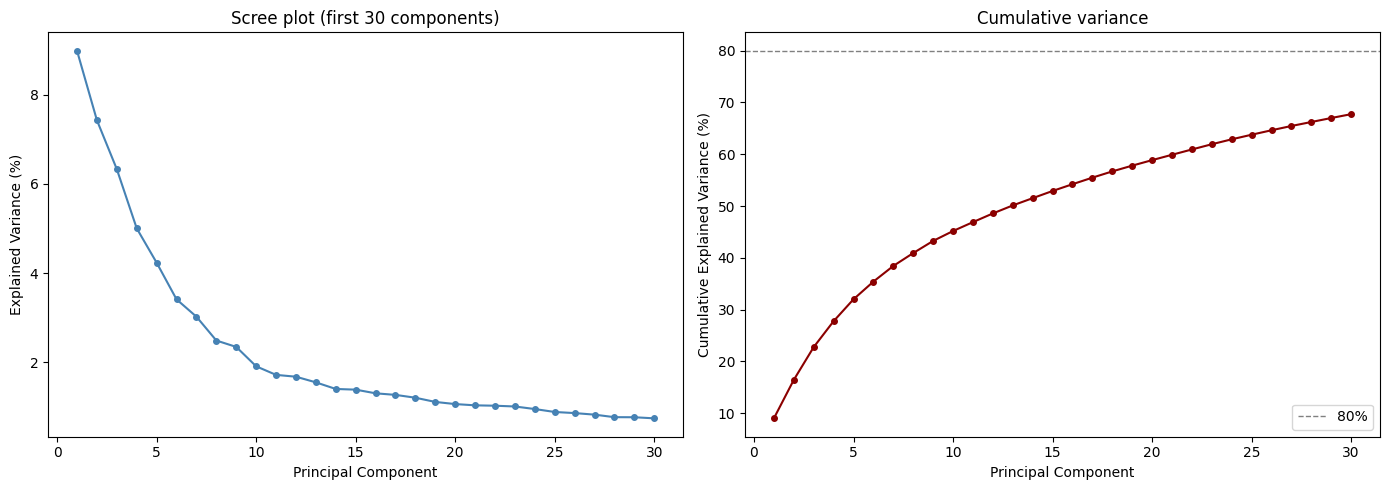

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 31), explained_var[:30] * 100, marker='o', color='steelblue', markersize=4)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree plot (first 30 components)')

axes[1].plot(range(1, 31), cumulative_var[:30] * 100, marker='o', color='darkred', markersize=4)
axes[1].axhline(80, color='grey', linestyle='--', linewidth=1, label='80%')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative variance')
axes[1].legend()

plt.tight_layout()
plt.show()

The scree plot confirms the expectation stated at the outset: no sharp elbow, just a smooth, gradual decay. This rules out the 80% cumulative-variance threshold used there as a selection criterion. At this decay rate, reaching 80% would require ~65+ components, defeating the purpose of using PCA as a compact numeric block. Within the 5-15 range, the marginal gain from 5→10 components (32.0%→45.2%, +13.2pp) is substantially larger than from 10→15 (45.2%→52.9%, +7.7pp), which is the point of clearest diminishing returns. **10 components** are retained, capturing 45.2% of embedding variance as a compact numeric feature block.

In [81]:
N_COMPONENTS_FINAL = 10

pca_final = PCA(n_components=N_COMPONENTS_FINAL, random_state=42)
embedding_pcs = pca_final.fit_transform(X_scaled)

embedding_pc_cols = [f'embedding_pc{i+1}' for i in range(N_COMPONENTS_FINAL)]
embedding_pc_df = pd.DataFrame(embedding_pcs, columns=embedding_pc_cols, index=listing_embeddings.index)

print(f"retained {N_COMPONENTS_FINAL} components, {pca_final.explained_variance_ratio_.sum()*100:.1f}% variance explained")
display(embedding_pc_df.describe())

retained 10 components, 45.2% variance explained


,embedding_pc1,embedding_pc2,embedding_pc3,embedding_pc4,embedding_pc5,embedding_pc6,embedding_pc7,embedding_pc8,embedding_pc9,embedding_pc10
count,3.071300e+04,3.071300e+04,3.071300e+04,3.071300e+04,3.071300e+04,3.071300e+04,3.071300e+04,3.071300e+04,3.071300e+04,3.071300e+04
mean,9.538917e-08,1.112874e-07,-7.949097e-08,1.311601e-07,-3.974549e-08,1.987274e-07,-3.974549e-08,4.769458e-08,1.212237e-07,-3.616839e-07
std,5.875382e+00,5.341404e+00,4.931065e+00,4.383949e+00,4.032631e+00,3.619964e+00,3.407248e+00,3.091548e+00,3.001142e+00,2.708640e+00
min,-3.096457e+01,-3.954044e+01,-3.140798e+01,-3.900884e+01,-3.799944e+01,-3.217787e+01,-3.050881e+01,-2.963807e+01,-3.377927e+01,-3.024185e+01
25%,-3.291094e+00,-2.894619e+00,-2.572346e+00,-2.277618e+00,-2.139741e+00,-1.842293e+00,-1.780824e+00,-1.742844e+00,-1.566242e+00,-1.356119e+00
50%,3.187244e-01,-1.039630e-02,-1.680123e-01,1.304188e-01,1.533204e-02,1.968430e-03,6.839877e-02,-4.198238e-02,-7.220297e-02,7.011484e-02
75%,3.825930e+00,2.931881e+00,2.379084e+00,2.492730e+00,2.155455e+00,1.858432e+00,1.959823e+00,1.717906e+00,1.500570e+00,1.413227e+00
max,4.086592e+01,3.454168e+01,3.840110e+01,2.506047e+01,3.442405e+01,2.802714e+01,2.213290e+01,2.505690e+01,2.903491e+01,2.035500e+01


All ten components are centered at zero with standard deviations decreasing monotonically from PC1 (5.88) to PC10 (2.71). Unlike `review_quality_pc1`, where all seven loadings were positive and the component had a clear, nameable interpretation, no attempt is made to interpret what each embedding PC represents semantically.

### 6.5 UMAP + HDBSCAN: Text Persona Clustering

A separate UMAP reduction feeds into density-based clustering. UMAP preserves local neighborhood structure better than PCA, which matters for HDBSCAN finding genuine density-based clusters rather than artifacts of a variance-maximizing projection. `min_cluster_size` is left to determine cluster count on its own rather than targeting a specific number of personas upfront. HDBSCAN's `-1` noise label is kept as an explicit category, following the same `unavailable`-style convention used throughout this project for points a method genuinely can't confidently classify.

In [82]:
import umap
import hdbscan

umap_reducer = umap.UMAP(n_components=5, random_state=42, metric='cosine')
umap_embedding = umap_reducer.fit_transform(X_scaled)

print(f"UMAP embedding shape: {umap_embedding.shape}")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (30713, 5)


HDBSCAN's cluster count is not a simple, monotonic function of `min_cluster_size`. It builds a full cluster hierarchy and selects the most stable configuration at each threshold, so small parameter changes can trigger large, nonlinear shifts. A sweep across a broad range surfaces this directly.

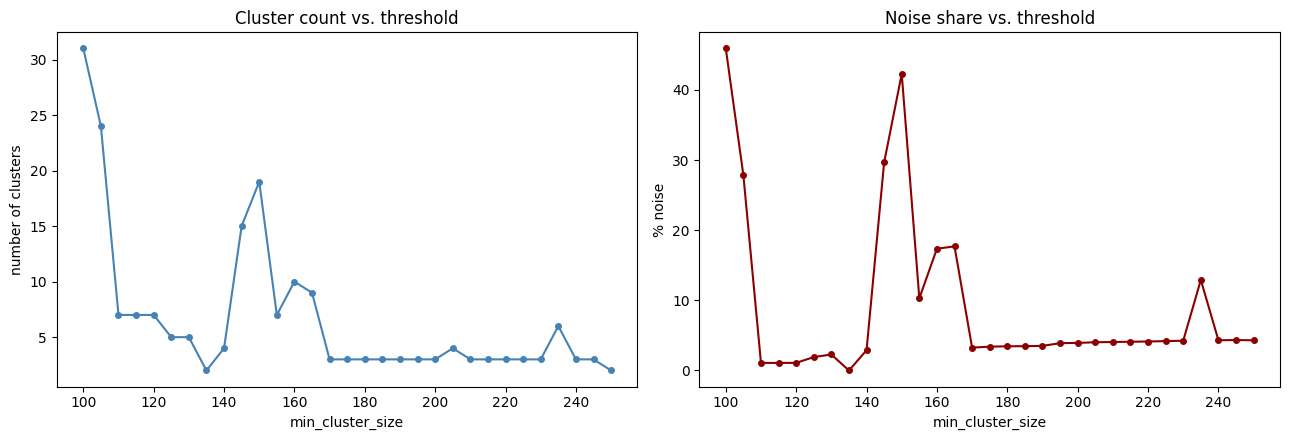

In [83]:
mcs_range = list(range(100, 251, 5))
sweep_results = []
for mcs in mcs_range:
    labels_test = hdbscan.HDBSCAN(min_cluster_size=mcs, metric='euclidean').fit_predict(umap_embedding)
    n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    noise_pct = (labels_test == -1).mean() * 100
    sweep_results.append({'min_cluster_size': mcs, 'n_clusters': n_clusters, 'noise_pct': noise_pct})

sweep_df = pd.DataFrame(sweep_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(sweep_df['min_cluster_size'], sweep_df['n_clusters'], marker='o', markersize=4, color='steelblue')
axes[0].set_xlabel('min_cluster_size')
axes[0].set_ylabel('number of clusters')
axes[0].set_title('Cluster count vs. threshold')

axes[1].plot(sweep_df['min_cluster_size'], sweep_df['noise_pct'], marker='o', markersize=4, color='darkred')
axes[1].set_xlabel('min_cluster_size')
axes[1].set_ylabel('% noise')
axes[1].set_title('Noise share vs. threshold')

plt.tight_layout()
plt.show()

The sweep reveals several stable plateaus rather than a smooth trend, separated by an abrupt, nonlinear transition, which is expected given HDBSCAN selects the most stable configuration from a full cluster hierarchy at each threshold, not a simple size-based cutoff. A finer plateau (`min_cluster_size≈150-166`) yields 6-10 clusters at 10-18% noise; a coarser one (`≈168-250+`) yields 2-6 clusters at 3-13% noise. Both are carried forward for direct comparison.

In [84]:
FINE_MCS = 155
COARSE_MCS = 235

labels_fine = hdbscan.HDBSCAN(min_cluster_size=FINE_MCS, metric='euclidean').fit_predict(umap_embedding)
labels_coarse = hdbscan.HDBSCAN(min_cluster_size=COARSE_MCS, metric='euclidean').fit_predict(umap_embedding)

def summarize_personas(labels, label_name):
    counts = pd.Series(labels).value_counts().sort_index()
    pct = pd.Series(labels).value_counts(normalize=True).sort_index() * 100
    summary = pd.DataFrame({'count': counts, 'pct': pct.round(2)})
    summary.index = ['noise (-1)' if i == -1 else f'persona_{i}' for i in summary.index]
    summary.columns = pd.MultiIndex.from_product([[label_name], summary.columns])
    return summary

print(f"fine plateau (min_cluster_size={FINE_MCS}):")
display(summarize_personas(labels_fine, 'fine'))
print(f"\ncoarse plateau (min_cluster_size={COARSE_MCS}):")
display(summarize_personas(labels_coarse, 'coarse'))

fine plateau (min_cluster_size=155):


fine       
            count    pct
noise (-1)   3159  10.29
persona_0     249   0.81
persona_1     433   1.41
persona_2     168   0.55
persona_3     340   1.11
persona_4     257   0.84
persona_5     687   2.24
persona_6   25420  82.77


coarse plateau (min_cluster_size=235):


coarse       
            count    pct
noise (-1)   3965  12.91
persona_0     434   1.41
persona_1     248   0.81
persona_2     339   1.10
persona_3     256   0.83
persona_4     686   2.23
persona_5   24785  80.70

Both plateaus are checked against the same two questions already established as decisive: does host concentration explain any cluster, and does the one geographically extreme cluster reflect a real sub-market?

In [85]:
def profile_plateau(labels, listing_embeddings, listings_nlp):
    rows = []
    for persona_id in sorted(set(labels) - {-1}):
        ids = listing_embeddings.index[labels == persona_id]
        host_ids = listings_nlp.loc[listings_nlp['id'].isin(ids), 'host_id']
        top_hosts = host_ids.value_counts()
        pct_repeat_hosts = (host_ids.map(top_hosts) >= 5).mean() * 100

        neighborhoods = listings_nlp.loc[listings_nlp['id'].isin(ids), 'neighbourhood_cleansed'].value_counts()
        median_dist = listings_nlp.loc[listings_nlp['id'].isin(ids), 'distance_to_center_km'].median()

        rows.append({
            'persona': persona_id, 'n': len(ids),
            'pct_repeat_hosts': round(pct_repeat_hosts, 1),
            'top_neighborhood': neighborhoods.index[0],
            'top_neighborhood_pct': round(neighborhoods.iloc[0] / neighborhoods.sum() * 100, 1),
            'median_distance_km': round(median_dist, 1),
        })
    return pd.DataFrame(rows).set_index('persona')

print(f"fine plateau (min_cluster_size={FINE_MCS}) profile:")
display(profile_plateau(labels_fine, listing_embeddings, listings_nlp))

print(f"\ncoarse plateau (min_cluster_size={COARSE_MCS}) profile:")
display(profile_plateau(labels_coarse, listing_embeddings, listings_nlp))

fine plateau (min_cluster_size=155) profile:


,n,pct_repeat_hosts,top_neighborhood,top_neighborhood_pct,median_distance_km
persona,,,,,
0,249,14.1,I Centro Storico,51.4,2.5
1,433,12.0,I Centro Storico,48.5,2.5
2,168,11.3,I Centro Storico,50.6,2.6
3,340,2.9,X Ostia/Acilia,80.3,24.7
4,257,2.3,I Centro Storico,49.8,2.4
5,687,12.5,I Centro Storico,54.4,2.5
6,25420,28.6,I Centro Storico,50.7,2.6



coarse plateau (min_cluster_size=235) profile:


,n,pct_repeat_hosts,top_neighborhood,top_neighborhood_pct,median_distance_km
persona,,,,,
0,434,12.0,I Centro Storico,48.6,2.5
1,248,14.1,I Centro Storico,51.2,2.5
2,339,2.9,X Ostia/Acilia,80.2,24.7
3,256,2.3,I Centro Storico,49.6,2.4
4,686,12.5,I Centro Storico,54.4,2.5
5,24785,28.6,I Centro Storico,50.9,2.6


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


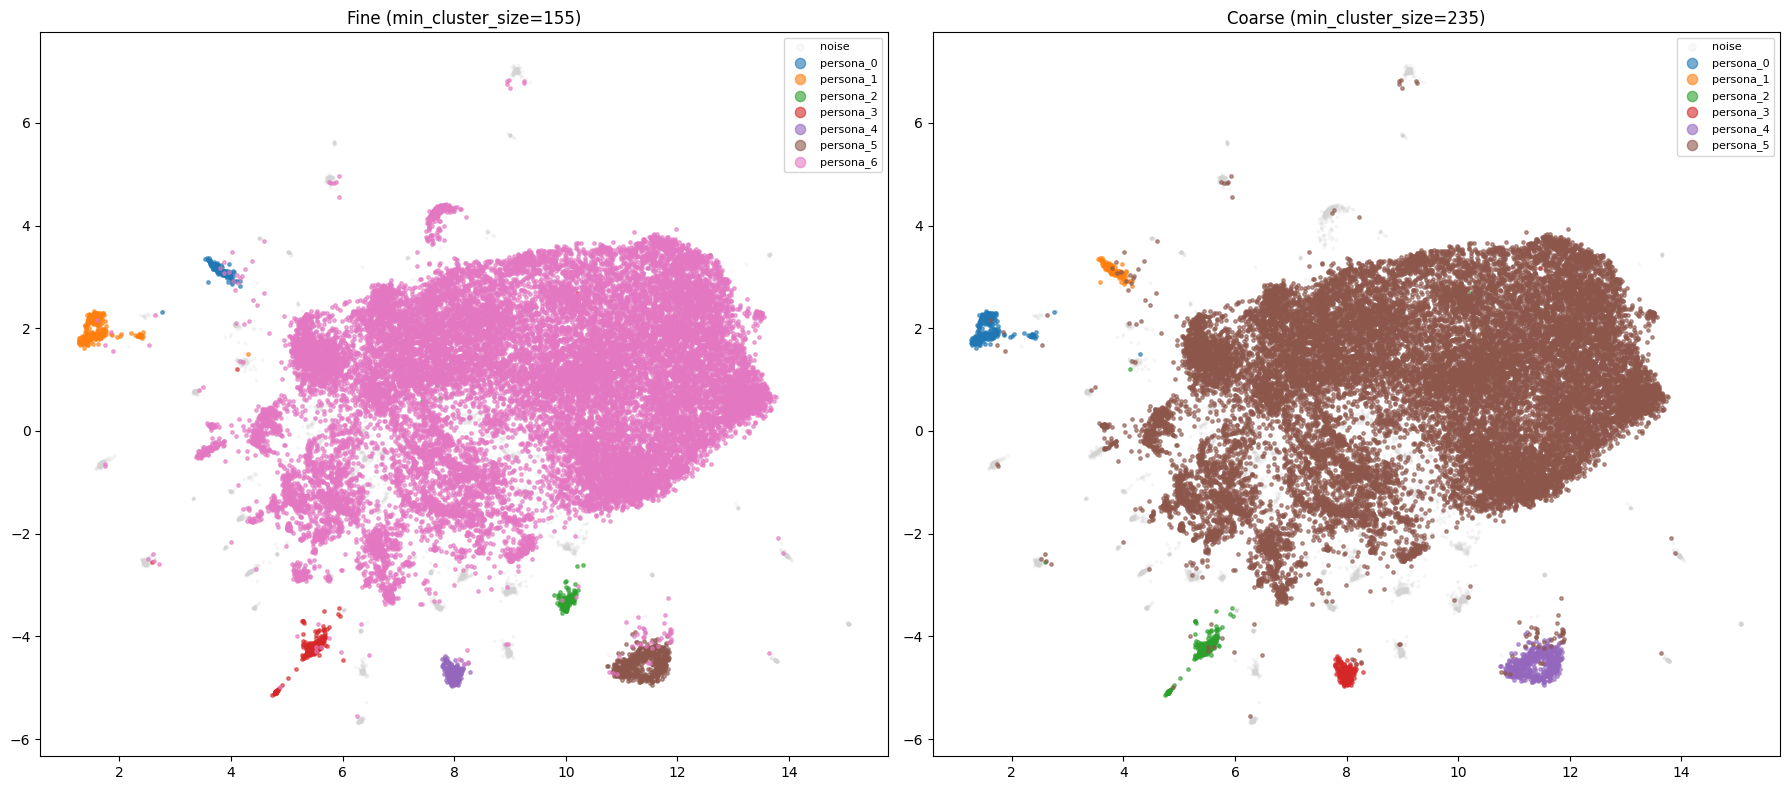

In [86]:
umap_2d = umap.UMAP(n_components=2, random_state=42, metric='cosine').fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, labels, title in [(axes[0], labels_fine, f'Fine (min_cluster_size={FINE_MCS})'),
                            (axes[1], labels_coarse, f'Coarse (min_cluster_size={COARSE_MCS})')]:
    noise_mask = labels == -1
    ax.scatter(umap_2d[noise_mask, 0], umap_2d[noise_mask, 1], s=3, alpha=0.15, color='lightgrey', label='noise')

    unique_personas = sorted(set(labels) - {-1})
    palette = sns.color_palette('tab10', n_colors=len(unique_personas))
    for i, persona_id in enumerate(unique_personas):
        mask = labels == persona_id
        ax.scatter(umap_2d[mask, 0], umap_2d[mask, 1], s=6, alpha=0.6, color=palette[i], label=f'persona_{persona_id}')

    ax.set_title(title)
    ax.legend(markerscale=3, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

**Observations:**

The 2D projection and profile tables together confirm the two thresholds resolve the same underlying structure at different granularity, not two different discoveries. Every satellite cluster's profile (host concentration, dominant neighborhood, median distance) matches near-exactly between the two solutions, most notably the Ostia/Acilia coastal cluster. The one substantive difference is that the fine solution (155) retains one additional small, reproducible cluster (168 listings) that the coarse solution (235) folds into the undifferentiated majority.

`min_cluster_size=155` is chosen as the final threshold, as it preserves the maximum amount of reliably reproducible structure the data supports, rather than discarding a genuine cluster for marginal simplicity. `text_persona` is retained as a modest, honestly-scoped feature: one strong, independently-validated finding (the Ostia coastal segment), several smaller stable groupings, and a large majority (82.8%) plus noise (10.3%) whose review text does not carry a distinct enough signature to separate from the generic bulk.

In [87]:
FINAL_MCS = 155
listing_embeddings['text_persona'] = labels_fine

print(f"final min_cluster_size: {FINAL_MCS}")
print(listing_embeddings['text_persona'].value_counts(normalize=True).sort_index() * 100)

final min_cluster_size: 155
text_persona
-1    10.285547
 0     0.810732
 1     1.409826
 2     0.547000
 3     1.107023
 4     0.836779
 5     2.236838
 6    82.766255
Name: proportion, dtype: float64


### 6.6 Validation & Diagnostics

`text_persona` exists to find structure the existing sentiment, topic, and tone features don't already capture, so the right validation is checking each persona's profile against those existing variables directly, not an independent ground-truth comparison. Every variable is z-scored against the corpus-wide mean before plotting, since sentiment (1-5 scale), topic shares (0-1 proportions), and tone densities (single-digit percentages) live on incomparable raw scales and would otherwise make the heatmap unreadable.

In [88]:
# labeling
listing_embeddings['text_persona'] = labels_fine
persona_label_map = {-1: 'noise'}
persona_label_map.update({pid: f'persona_{pid}' for pid in sorted(set(labels_fine) - {-1})})
listing_embeddings['text_persona'] = listing_embeddings['text_persona'].map(persona_label_map)
print(listing_embeddings['text_persona'].value_counts())

text_persona
persona_6    25420
noise         3159
persona_5      687
persona_1      433
persona_3      340
persona_4      257
persona_0      249
persona_2      168
Name: count, dtype: int64


In [89]:
# merge embedding features into listings_nlp
embed_features = embedding_pc_df.join(listing_embeddings[['text_persona', 'n_embedded_reviews']])

existing_embed_cols = [c for c in embed_features.columns if c in listings_nlp.columns]
if existing_embed_cols:
    listings_nlp = listings_nlp.drop(columns=existing_embed_cols)

listings_nlp = listings_nlp.merge(embed_features, left_on='id', right_index=True, how='left')

n_with_embeddings = listings_nlp['embedding_pc1'].notna().sum()
n_with_persona = listings_nlp['text_persona'].notna().sum()
print(f"listings with embedding PCA features: {n_with_embeddings:,} / {len(listings_nlp):,} "
      f"({n_with_embeddings/len(listings_nlp)*100:.1f}%)")
print(f"listings with text_persona: {n_with_persona:,}")
print(f"\n{listings_nlp['text_persona'].value_counts(dropna=False)}")

listings with embedding PCA features: 30,713 / 35,818 (85.7%)
listings with text_persona: 30,713

text_persona
persona_6    25420
NaN           5105
noise         3159
persona_5      687
persona_1      433
persona_3      340
persona_4      257
persona_0      249
persona_2      168
Name: count, dtype: int64


28 profiling variables: ['sentiment_mean', 'sentiment_std', 'sentiment_pct_negative', 'review_scores_rating_raw', 'topic_apartment_quality_share', 'topic_bed_comfort_share', 'topic_checkin_ease_share', 'topic_general_enjoyment_share', 'topic_guest_gratitude_share', 'topic_host_responsiveness_share', 'topic_intent_return_share', 'topic_metro_train_share', 'topic_trip_framing_share', 'topic_walkability_quiet_share', 'topic_walking_distance_attractions_share', 'topic_well_equipped_share', 'review_punct_density', 'review_self_ref_density', 'review_we_ref_density', 'review_direct_address_density', 'review_luxury_density', 'review_family_density', 'review_budget_density', 'review_romantic_density', 'review_authenticity_density', 'review_atmosphere_quiet_density', 'review_atmosphere_lively_density', 'review_transport_density']


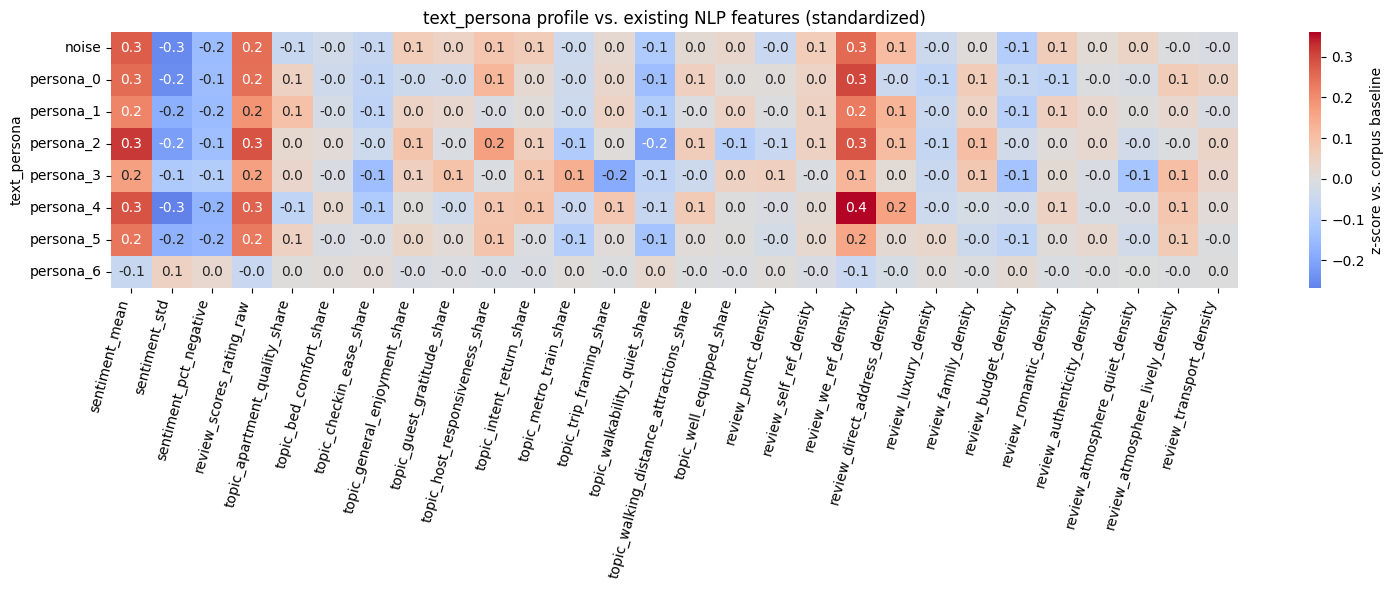

In [90]:
profile_vars = (
    ['sentiment_mean', 'sentiment_std', 'sentiment_pct_negative', 'review_scores_rating_raw'] +
    [c for c in listings_nlp.columns if c.startswith('topic_') and c.endswith('_share')] +
    [c for c in listings_nlp.columns if c.startswith('review_') and c.endswith('_density')]
)
profile_vars = [c for c in profile_vars if c in listings_nlp.columns]
print(f"{len(profile_vars)} profiling variables: {profile_vars}")

persona_profile = listings_nlp.groupby('text_persona', observed=True)[profile_vars].mean()
overall_baseline = listings_nlp[profile_vars].mean()
overall_std = listings_nlp[profile_vars].std()

persona_zscore = (persona_profile - overall_baseline) / overall_std

fig, ax = plt.subplots(figsize=(max(12, len(profile_vars) * 0.55), 6))
sns.heatmap(persona_zscore, cmap='coolwarm', center=0, annot=True, fmt='.1f',
            cbar_kws={'label': 'z-score vs. corpus baseline'}, ax=ax)
ax.set_title('text_persona profile vs. existing NLP features (standardized)')
ax.set_xlabel('')
ax.set_ylabel('text_persona')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

Most of the heatmap sits near zero (|z| < 0.2), meaning `text_persona` is largely orthogonal to the existing sentiment/topic/tone variables. The two negative outliers are narrower and more specific: `persona_3` (the Ostia/Acilia coastal cluster) shows the deviation on `topic_trip_framing_share` (-0.2), plausibly because reviews of a beach town frame the stay less as "visiting Rome" than reviews of central listings do, a sensible, independent echo of the same coastal identity already confirmed via neighborhood and distance. `persona_2` separately shows a notable dip on `topic_walkability_quiet_share` (-0.2), without a clear independent explanation for what distinguishes this persona otherwise.

The largest single deviation on the whole map is `review_we_ref_density` (+0.4 for `persona_4`, elevated across most small personas). Reviewers in these clusters write with more "we"-framing ("we loved," "we stayed") than the corpus baseline, a genuine stylistic signature tied to how these clusters were formed in the first place.

A milder, more uniform pattern also holds: every small persona (0-5) sits slightly better than the corpus baseline on sentiment (higher `sentiment_mean`, lower `sentiment_std`/`sentiment_pct_negative`), while the undifferentiated majority (`persona_6`) and `noise` sit at or slightly below it. In plain terms: listings distinctive enough in review phrasing to separate out from the generic bulk also tend to be somewhat more consistently well-liked.

review_lang_mode,en,it,es,fr,too_short,de
text_persona,,,,,,
noise,89.6,6.0,1.3,1.9,0.1,0.6
persona_0,89.6,6.0,2.4,1.6,0.0,0.0
persona_1,90.8,5.1,1.2,2.1,0.0,0.7
persona_2,93.5,3.0,1.8,1.8,0.0,0.0
persona_3,82.6,9.7,0.6,2.4,0.0,2.9
persona_4,91.8,3.9,1.9,1.2,0.0,1.2
persona_5,86.9,9.6,1.3,1.3,0.0,0.7
persona_6,76.4,12.4,4.2,2.5,1.7,1.5



corpus baseline: {'en': 78.6, 'it': 11.4, 'es': 3.7, 'fr': 2.4, 'too_short': 1.4, 'de': 1.4}


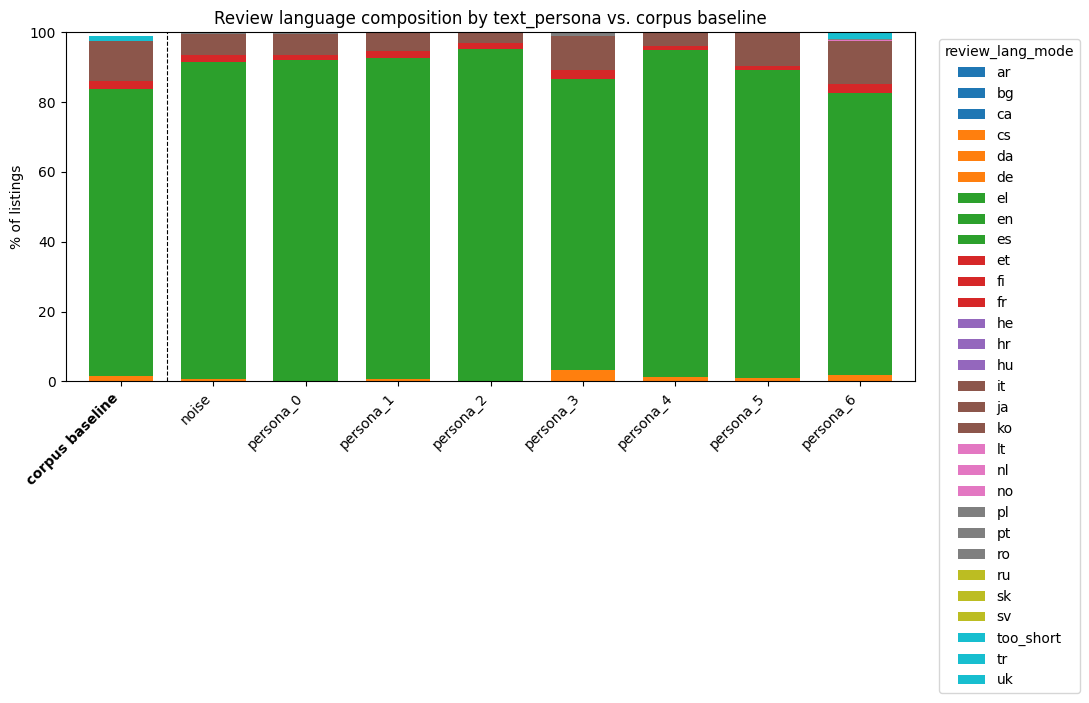

In [161]:
review_lang_mode_map = reviews_sampled.groupby('listing_id')['review_lang'].agg(
    lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan
)
listings_nlp['review_lang_mode'] = listings_nlp['id'].map(review_lang_mode_map)

lang_by_persona = pd.crosstab(listings_nlp['text_persona'], listings_nlp['review_lang_mode'], normalize='index') * 100
corpus_lang_baseline = listings_nlp['review_lang_mode'].value_counts(normalize=True).mul(100)

top_langs = corpus_lang_baseline.head(6).index
display(lang_by_persona[top_langs].round(1))
print(f"\ncorpus baseline: {corpus_lang_baseline.head(6).round(1).to_dict()}")

lang_by_persona_full = lang_by_persona.copy()
lang_by_persona_full.loc['corpus baseline'] = corpus_lang_baseline.reindex(top_langs)

plot_order = ['corpus baseline'] + [p for p in lang_by_persona_full.index if p != 'corpus baseline']
plot_data = lang_by_persona_full.loc[plot_order]

fig, ax = plt.subplots(figsize=(11, 6))
plot_data.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', width=0.7)
ax.set_ylabel('% of listings')
ax.set_xlabel('')
ax.set_title('Review language composition by text_persona vs. corpus baseline')
ax.legend(title='review_lang_mode', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')

# highlight the baseline bar
ax.get_xticklabels()[0].set_fontweight('bold')
ax.axvline(0.5, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

`persona_6` and `noise` sit closest to the corpus baseline (en 76.4%/89.6% vs. 78.6%), consistent with them being the largest, least-differentiated groups. The smaller satellite personas skew somewhat more English-heavy, as `persona_2` reaches 93.5% English against a 78.6% baseline, and every small persona except `persona_3` sits above 86% English, all pulling from Italian's share specifically. `persona_3` (Ostia/Acilia) is the one small persona closest to baseline proportions (en 82.6%, it 9.7%), which argues against language driving its price/geography signal specifically, even as the pattern across the other small personas is real and modest, not the clean null result originally claimed.

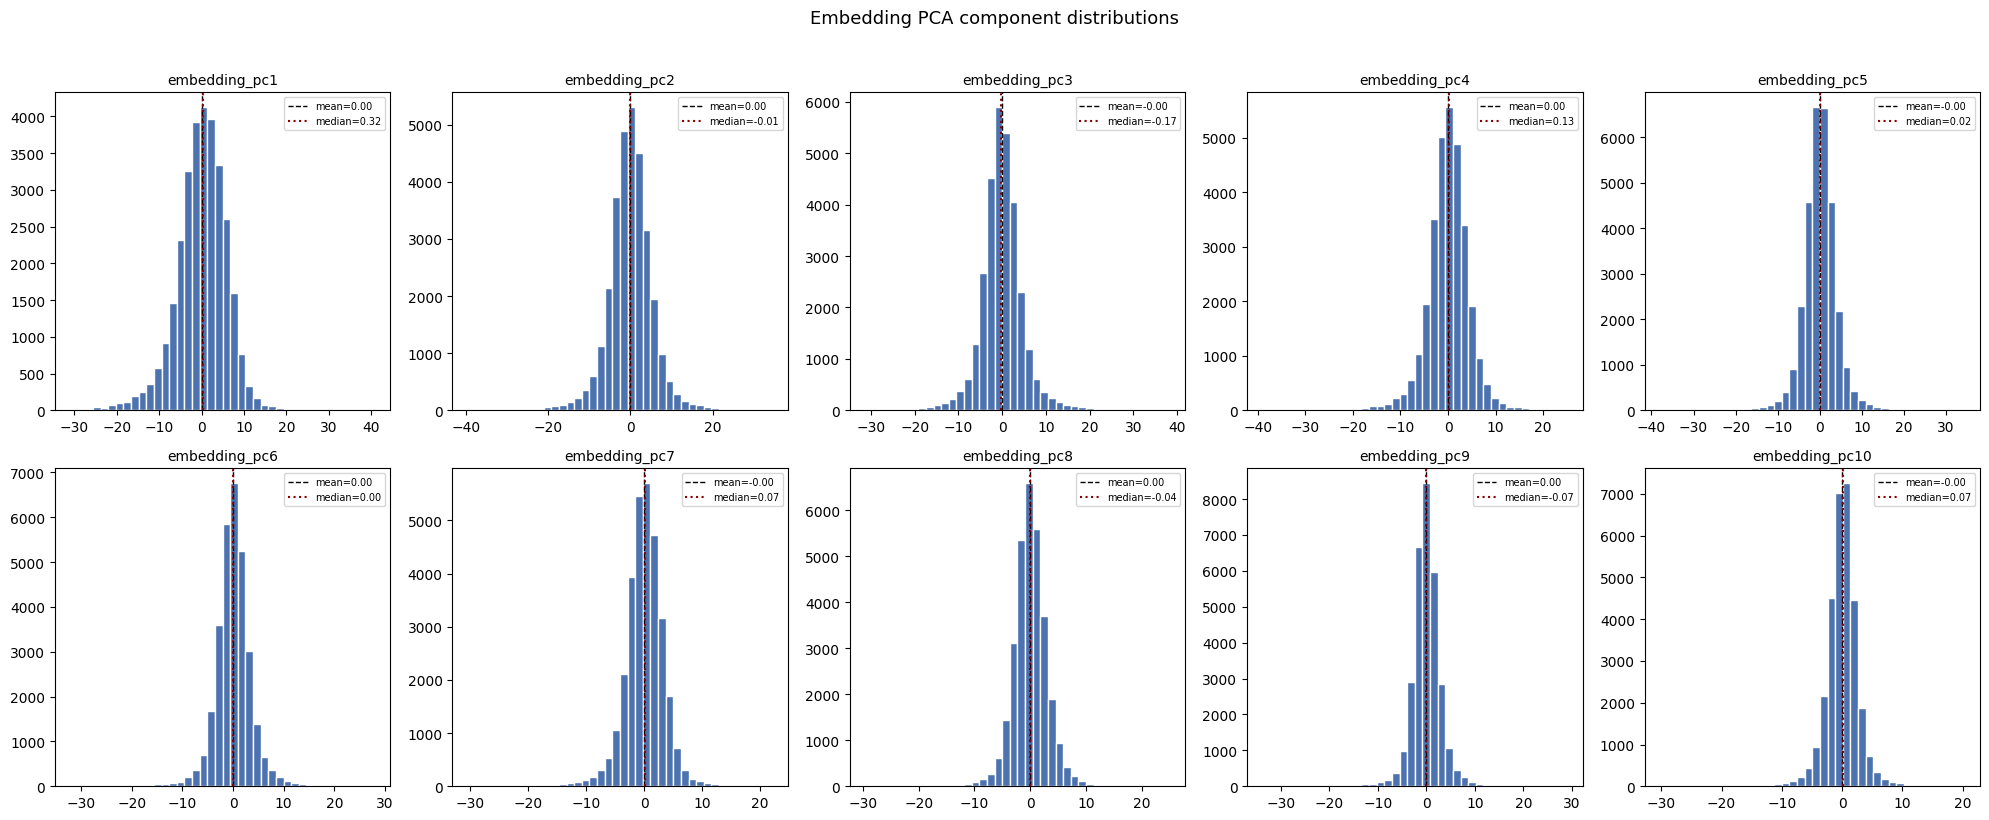

,count,mean,std,min,25%,50%,75%,max
embedding_pc1,30713.0,0.0,5.875,-30.965,-3.291,0.319,3.826,40.866
embedding_pc2,30713.0,0.0,5.341,-39.540,-2.895,-0.010,2.932,34.542
embedding_pc3,30713.0,-0.0,4.931,-31.408,-2.572,-0.168,2.379,38.401
embedding_pc4,30713.0,0.0,4.384,-39.009,-2.278,0.130,2.493,25.060
embedding_pc5,30713.0,-0.0,4.033,-37.999,-2.140,0.015,2.155,34.424
embedding_pc6,30713.0,0.0,3.620,-32.178,-1.842,0.002,1.858,28.027
embedding_pc7,30713.0,-0.0,3.407,-30.509,-1.781,0.068,1.960,22.133
embedding_pc8,30713.0,0.0,3.092,-29.638,-1.743,-0.042,1.718,25.057
embedding_pc9,30713.0,0.0,3.001,-33.779,-1.566,-0.072,1.501,29.035
embedding_pc10,30713.0,-0.0,2.709,-30.242,-1.356,0.070,1.413,20.355


In [91]:
# distribution of embedding PCA components
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, embedding_pc_cols):
    data = listings_nlp[col].dropna()
    ax.hist(data, bins=40, color='#4c72b0', edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={data.mean():.2f}')
    ax.axvline(data.median(), color='darkred', linestyle=':', linewidth=1.5, label=f'median={data.median():.2f}')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle('Embedding PCA component distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

embedding_stats = listings_nlp[embedding_pc_cols].describe().T
display(embedding_stats.round(3))

All ten components show a clean, roughly symmetric, unimodal shape centered at zero. Spread visibly narrows from PC1 to PC10, consistent with the decreasing standard deviations. No bimodality, skew, or other irregular structure appears in any component, meaning this feature block needs no further transformation before use, unlike several other NLP features.

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_19198/1963320685.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=listings_nlp.dropna(subset=['text_persona']), x='text_persona', y='n_embedded_reviews',


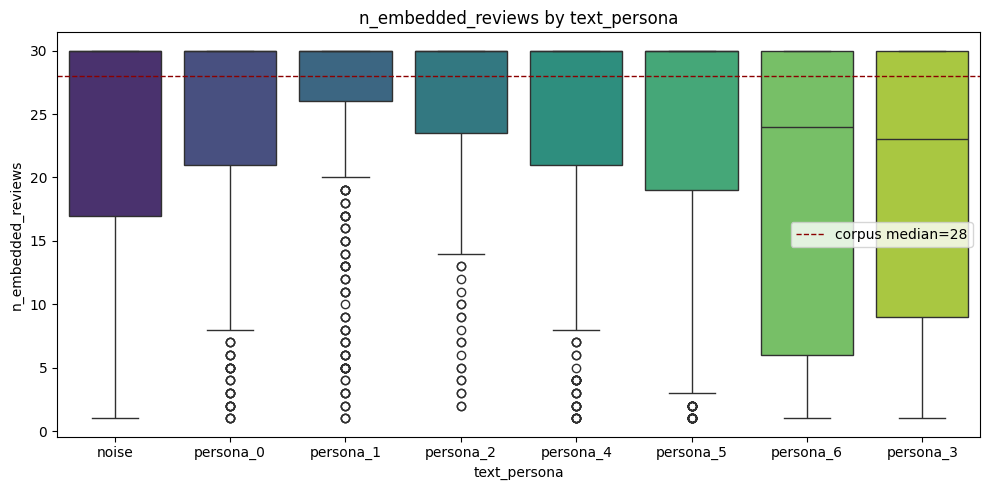

In [92]:
# robustness check
fig, ax = plt.subplots(figsize=(10, 5))
persona_order = listings_nlp.groupby('text_persona', observed=True)['n_embedded_reviews'].median().sort_values(ascending=False).index
sns.boxplot(data=listings_nlp.dropna(subset=['text_persona']), x='text_persona', y='n_embedded_reviews',
            order=persona_order, ax=ax, palette='viridis')
ax.axhline(listings_nlp['n_embedded_reviews'].median(), color='darkred', linestyle='--', linewidth=1,
           label=f"corpus median={listings_nlp['n_embedded_reviews'].median():.0f}")
ax.set_title('n_embedded_reviews by text_persona')
ax.legend()
plt.tight_layout()
plt.show()

The concern motivating this check is that small personas might be artifacts of unstable, few-review averages and it does not hold up. The five small satellite personas (0, 1, 2, 4, 5) and `noise` all show their bulk of listings (the box itself) sitting at or above the corpus median, with only a minority of low-review-count listings appearing as individually flagged outliers below the whisker, rather than pulling the box itself down. `persona_6` (the undifferentiated majority) and `persona_3` (Ostia) instead show wide boxes spanning the full range without flagged outliers, meaning low-review-count listings are common enough within these two groups to sit inside the normal interquartile range rather than standing out as rare exceptions.

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_19198/1533200813.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=price_data, x='text_persona', y='price', order=persona_order_price, ax=ax, palette='magma', showfliers=False)


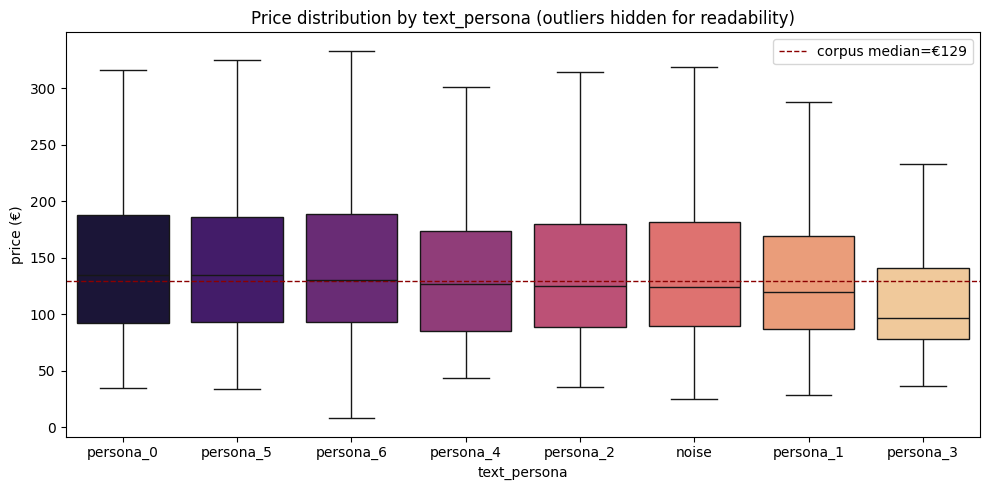

text_persona
persona_0    135.0
persona_5    135.0
persona_6    130.0
persona_4    127.0
persona_2    125.0
noise        124.0
persona_1    120.0
persona_3     97.0
Name: price, dtype: float64


In [93]:
# price cross-check
fig, ax = plt.subplots(figsize=(10, 5))
price_data = listings_nlp.dropna(subset=['text_persona', 'price'])
persona_order_price = price_data.groupby('text_persona', observed=True)['price'].median().sort_values(ascending=False).index

sns.boxplot(data=price_data, x='text_persona', y='price', order=persona_order_price, ax=ax, palette='magma', showfliers=False)
ax.axhline(price_data['price'].median(), color='darkred', linestyle='--', linewidth=1,
           label=f"corpus median=€{price_data['price'].median():.0f}")
ax.set_title('Price distribution by text_persona (outliers hidden for readability)')
ax.set_ylabel('price (€)')
ax.legend()
plt.tight_layout()
plt.show()

print(price_data.groupby('text_persona', observed=True)['price'].median().sort_values(ascending=False))

`persona_3` (Ostia/Acilia) stands out clearly: a median price of €97, around 25% below the corpus median (€129) and the lowest of any group by a wide margin, the first genuinely independent corroboration of this segment via a variable that played no role in building the clustering, embeddings, or any prior profiling variable. This is directionally exactly what would be expected for a peripheral coastal district relative to central Rome, and it is the single most substantively interesting result in this section: `text_persona` recovered a real, economically meaningful sub-market from review text alone.

The remaining personas cluster tightly together (€120-135), including the undifferentiated majority and noise. No other satellite persona shows a distinguishing price signal. This reinforces the section's honest framing: one strong, multiply-validated finding (Ostia, now confirmed geographically, topically, and economically), and several smaller groupings that remain undifferentiated on every variable checked so far.

### 6.7 Section 6 Summary

This section built two products from the same multilingual sentence embeddings, a compact numeric feature block and a categorical text-persona label, to test whether review text carries semantic structure beyond what tabular features and the earlier NLP methods already capture, working through three stages:

- **Embedding & aggregation**: `paraphrase-multilingual-MiniLM-L12-v2` embedded the *entire* `reviews_sampled` corpus regardless of language — the one method in this project with no language-coverage caveat. Per-review vectors were mean-pooled to one 384-dimensional vector per listing, reaching 85.7% coverage that reconciles exactly with listings having zero sampled reviews at all, the same root cause already established for other review-based methods.

- **PCA numeric block**: unlike the review-score block's single dominant PC1, embedding variance decayed smoothly with no sharp elbow. Ten components were retained at the point of clearest diminishing marginal return (45.2% variance explained), with no attempt at semantic interpretation of individual components, unlike `review_quality_pc1`.

- **UMAP + HDBSCAN text personas**: a parameter sweep revealed two stable plateaus rather than a smooth trend, both compared directly rather than picking one on the strength of the sweep alone. Every satellite cluster's profile matched near-exactly between the two, so the finer plateau (`min_cluster_size=155`) was chosen for preserving one additional reproducible cluster the coarser solution discarded. Two systematic confounds were checked before trusting the result: repeat multi-listing hosts (concentration stays flat at 11-14% across most clusters, not selectively elevated) and language, specifically for the persona the result hinges on — `persona_3` (Ostia/Acilia) sits closest to the corpus's language baseline of any small persona, arguing against language driving its distinct price/geography signal, even though the smaller personas overall skew modestly more English-heavy than baseline.

- **Validation**: cluster profiling against 28 existing sentiment/topic/tone variables showed `text_persona` is largely orthogonal to them (|z| < 0.2 almost everywhere), which is the intended outcome, since the method exists to find what those features don't already capture. A robustness check ruled out small-sample instability as an explanation for the small clusters. Most importantly, a price cross-check gave economically meaningful confirmation of the one cluster with a clear identity throughout: Ostia/Acilia, a coastal district recovered purely from review text, priced 25% below the corpus median.

`embedding_pc1-10` and `text_persona` are merged into `listings_nlp` as-is. The section's honest conclusion is asymmetric rather than uniform: one strong, independently-validated finding confirmed through geography, topic content, and price alike, alongside several smaller, stable but still-unexplained groupings, and a large majority of listings whose review text carries no signature distinct enough to separate from the generic bulk.

## 7. Full NLP Feature Set: Validation & Selection

Three families of text-derived signals were built: surface stylometry and domain lexicons, model-based sentiment and topic content, and multilingual embeddings. Each was validated on its own terms as it was built. This section closes the loop these earlier sections deliberately left open: redundancy within the NLP block, redundancy against the tabular feature set, and a direct price-leak diagnostic, before assembling the feature set that actually enters modelling stage.

### 7.1 Feature Inventory & Scaffolding Cleanup

Before any redundancy or leakage check can be trusted, the full candidate set needs to be assembled in one place and cleanly separated from scaffolding columns (`_method`, `_tags`, diagnostic helper columns built only for a specific validation plot) that were never meant as model inputs. This is built programmatically from column-naming conventions, to avoid silently dropping or miscounting something across two long notebooks.

In [94]:
display(listings_nlp.columns.to_frame(index=False))

,0
0,id
1,host_id
2,host_response_time
3,host_response_rate_raw
4,host_acceptance_rate_raw
...,...
328,embedding_pc8
329,embedding_pc9
330,embedding_pc10
331,text_persona


In [95]:
all_cols = set(listings_nlp.columns)

# columns that share an NLP-style prefix (review_, description_, etc.) but are
# actually tabular/numeric-score derived from Part 1
TABULAR_REVIEW_SCORE_COLS = {
    'review_scores_rating_raw', 'review_scores_accuracy_raw', 'review_scores_cleanliness_raw',
    'review_scores_checkin_raw', 'review_scores_communication_raw', 'review_scores_location_raw',
    'review_scores_value_raw', 'review_quality_pc1', 'review_quality_pc1_binned',
    'review_engagement_score', 'reviews_per_month_raw', 'last_review_recency_raw',
    'number_of_reviews', 'number_of_reviews_log',
    'review_scores_accuracy_binned', 'review_scores_checkin_binned',
    'review_scores_cleanliness_binned', 'review_scores_communication_binned',
    'review_scores_location_binned', 'review_scores_rating_binned',
    'review_scores_value_binned',
}

# scaffolding: diagnostic-only columns
SCAFFOLDING_SUFFIXES = ('_method', '_tags')
SCAFFOLDING_EXPLICIT = {
    'description_landmark_tags_parsed', 'desc_topic_group', 'n_english_reviews',
    'host_listings_bucket', 'distance_bucket', 'sentiment_trend_pvalue',
    'sentiment_lang_covered',
}


# raw source text
RAW_TEXT_COLS = {'description_cleaned', 'host_about_cleaned', 'neighborhood_overview_cleaned',
                  'name_cleaned'}
# language metadata 
LANGUAGE_METADATA_COLS = {'description_lang', 'host_about_lang', 'neighborhood_overview_lang'}

NLP_TEXT_PREFIXES = ('description_', 'host_about_', 'neighborhood_overview_', 'review_')
NLP_MODEL_PREFIXES = ('sentiment_', 'topic_', 'desc_topic_', 'embedding_pc')
NLP_MODEL_EXPLICIT = {'n_valid_sentiment', 'n_embedded_reviews', 'text_persona',
                       'review_dominant_topic', 'desc_dominant_topic', 'sentiment_trend_category',
                       'avg_review_length'}
MISSINGNESS_FLAGS = {'has_name', 'has_description', 'has_neighborhood_overview', 'has_host_about'}
NLP_HAS_FLAG_PREFIXES = ('has_description_', 'has_host_about_', 'has_neighborhood_overview_')

def classify_column(col):
    if col in SCAFFOLDING_EXPLICIT or col.endswith(SCAFFOLDING_SUFFIXES):
        return 'scaffolding'
    if col in TABULAR_REVIEW_SCORE_COLS:
        return 'tabular (not NLP)'
    if col in RAW_TEXT_COLS:
        return 'source_text (not a feature)'
    if col.startswith(NLP_HAS_FLAG_PREFIXES):
        return 'nlp_candidate (stylometry/lexicon)'
    if col in NLP_MODEL_EXPLICIT or col.startswith(NLP_MODEL_PREFIXES):
        return 'nlp_candidate (model-based)'
    if col in MISSINGNESS_FLAGS or col.startswith(NLP_TEXT_PREFIXES):
        return 'nlp_candidate (stylometry/lexicon)'
    return 'other (not NLP)'

classification = pd.Series({col: classify_column(col) for col in all_cols})
print(classification.value_counts())

nlp_candidate (stylometry/lexicon)    156
other (not NLP)                        64
nlp_candidate (model-based)            49
scaffolding                            39
tabular (not NLP)                      21
source_text (not a feature)             4
Name: count, dtype: int64


In [158]:
nlp_candidate_cols = sorted(classification[classification.str.startswith('nlp_candidate')].index)
scaffolding_cols = sorted(classification[classification == 'scaffolding'].index)
source_text_cols = sorted(classification[classification == 'source_text (not a feature)'].index)

is_language_metadata = {c: (c in LANGUAGE_METADATA_COLS) for c in nlp_candidate_cols}
print(f"of which flagged as language metadata: {sum(is_language_metadata.values())}\n")

# full printed inventory for manual verification
pd.set_option('display.max_rows', None)
display(classification[classification.index.isin(nlp_candidate_cols)].sort_index().to_frame('category'))

of which flagged as language metadata: 3



,category
avg_review_length,nlp_candidate (model-based)
desc_dominant_topic,nlp_candidate (model-based)
desc_topic_amenities_wifi_ac_tv_weight,nlp_candidate (model-based)
desc_topic_bedroom_layout_weight,nlp_candidate (model-based)
desc_topic_building_character_weight,nlp_candidate (model-based)
desc_topic_metro_distance_meters_weight,nlp_candidate (model-based)
desc_topic_multi_bedroom_large_weight,nlp_candidate (model-based)
desc_topic_navona_pantheon_campo_fiori_weight,nlp_candidate (model-based)
desc_topic_near_attractions_general_weight,nlp_candidate (model-based)
desc_topic_neighborhood_liveliness_weight,nlp_candidate (model-based)


In [97]:
display(classification[classification == 'other (not NLP)'].sort_index().to_frame('category'))

,category
accommodates,other (not NLP)
accommodates_per_bedroom,other (not NLP)
accommodates_per_bedroom_binned,other (not NLP)
amenities_count,other (not NLP)
availability_365,other (not NLP)
availability_365_ratio,other (not NLP)
availability_90,other (not NLP)
availability_ratio,other (not NLP)
bath_private_info,other (not NLP)
bath_shared_info,other (not NLP)


In [98]:
# drop scaffolding and raw source text from the working frame
listings_nlp_features = listings_nlp.drop(columns=scaffolding_cols + source_text_cols)
print(f"working frame: {listings_nlp_features.shape[1]} columns "
      f"(down from {listings_nlp.shape[1]})")

working frame: 290 columns (down from 333)


204 NLP candidate features register cleanly across two families (156 stylometry/lexicon, 49 model-based), separated from 39 scaffolding columns, 4 raw source-text fields, and 21 tabular review-score columns that share the `review_` prefix without being text-derived. `name_cleaned` is kept as source text only, not developed into features: listing titles are short, structurally noisy marketing strings (a mix of neighborhood names, room descriptors, and stylistic fragments), for which no method in Part 1 was actually applied, unlike `description`/`host_about`/`neighborhood_overview`.

### 7.2 Missingness Coverage Map

Each model-based method established its own coverage story in isolation: sentiment 98.6%, review topics 77.7%, description topics 97.0%, embeddings 85.7%. What hasn't been checked is the *joint* distribution: how many listings carry a complete profile across all four at once versus a partial one, which matters directly for the modelling stage, where a listing missing any one block behaves differently from one missing all of them.

In [99]:
review_topic_cols = [c for c in listings_nlp.columns if c.startswith('topic_') and c.endswith('_share')]

coverage_flags = pd.DataFrame({
    'has_sentiment': listings_nlp['sentiment_mean'].notna(),
    'has_review_topics': listings_nlp[review_topic_cols].notna().all(axis=1),
    'has_desc_topics': listings_nlp['desc_dominant_topic'].notna(),
    'has_embeddings': listings_nlp['embedding_pc1'].notna(),
}, index=listings_nlp.index)

print("individual coverage (unchanged from §4-6, shown for reference):")
print(coverage_flags.mean().mul(100).round(1))

n_sources = coverage_flags.sum(axis=1)
print(f"\nlistings with all 4 model-based sources: {(n_sources==4).sum():,} ({(n_sources==4).mean()*100:.1f}%)")
print(f"listings with 0 sources: {(n_sources==0).sum():,} ({(n_sources==0).mean()*100:.1f}%)")

individual coverage (unchanged from §4-6, shown for reference):
has_sentiment        84.6
has_review_topics    77.7
has_desc_topics      97.0
has_embeddings       85.7
dtype: float64

listings with all 4 model-based sources: 27,031 (75.5%)
listings with 0 sources: 188 (0.5%)


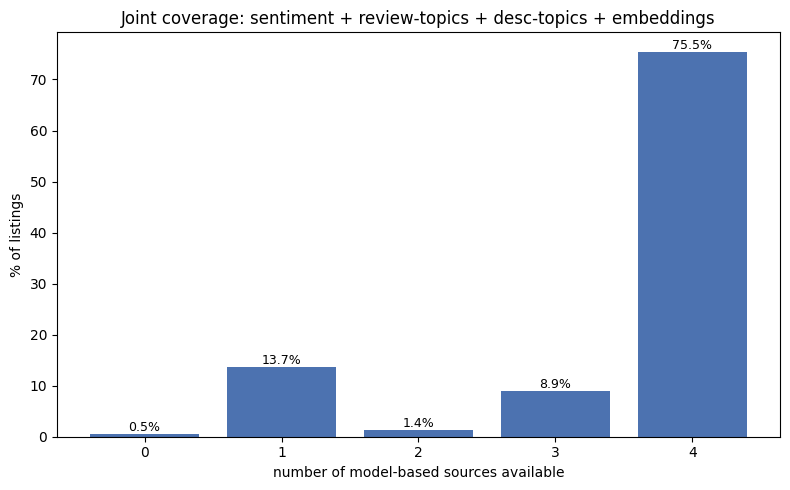

In [100]:
fig, ax = plt.subplots(figsize=(8, 5))
pct = n_sources.value_counts(normalize=True).sort_index() * 100
ax.bar(pct.index.astype(str), pct.values, color='#4c72b0')
ax.set_xlabel('number of model-based sources available')
ax.set_ylabel('% of listings')
ax.set_title('Joint coverage: sentiment + review-topics + desc-topics + embeddings')
for i, v in enumerate(pct.values):
    ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [101]:
# exact combination of which specific sources are present/absent together
combo_summary = pd.DataFrame({
    'count': coverage_flags.value_counts(),
    'pct': coverage_flags.value_counts(normalize=True).mul(100).round(2)
}).sort_values('count', ascending=False)
display(combo_summary)

count    pct
has_sentiment has_review_topics has_desc_topics has_embeddings              
True          True              True            True            27031  75.47
False         False             True            False            4917  13.73
True          False             True            True             2384   6.66
              True              False           True              807   2.25
False         False             True            True              418   1.17
                                False           False             188   0.52
True          False             False           True               68   0.19
False         False             False           True                5   0.01

In [102]:
# stylometry/lexicon block coverage is gated by the three text-field flags,
# already established in Part 1 
text_field_coverage = listings_nlp[['has_description', 'has_host_about', 'has_neighborhood_overview']].mean().mul(100).round(1)
print(text_field_coverage)

has_description              97.5
has_host_about               45.0
has_neighborhood_overview    46.5
dtype: float64


75.5% of listings carry a complete four-source model-based profile. The remaining 24.5% split into just 8 distinct combinations (out of 16 mathematically possible). A strong sign the missingness is structured and traces cleanly to the same language-coverage rules already established: embeddings have no restriction, sentiment covers six languages (`nlptown`), review/description topics require English specifically. The two largest partial-coverage buckets reconcile exactly with prior findings: 4,917 + 188 = 5,105 matches the zero-review-listing count, confirming these listings' only possible model-based signal is an English description, if they have one. The next two buckets (2,384 missing only review-topics; 807 missing only desc-topics) are direct, sensible consequences of English being a stricter requirement than `nlptown`'s six languages or embeddings' unrestricted coverage.

`has_host_about` (45.0%) and `has_neighborhood_overview` (46.5%) sit on a separate coverage axis entirely. These gate the ~150 stylometry/lexicon columns per field established in Part 1.

This joint structure matters directly for the modeling stage: a listing missing one source isn't "missing data" in a generic sense, it's missing a specific, language-explainable piece.

Each of the 8 observed combinations maps cleanly onto a specific, language-driven cause:

| Combination | n | % | Explanation |
|---|---|---|---|
| All 4 sources | 27,031 | 75.47% | Complete profile |
| Description topics only | 4,917 | 13.73% | No reviews at all, but an English description |
| Sentiment + embeddings + description topics (no review topics) | 2,384 | 6.66% | Reviews exist in an `nlptown`-covered language, but none specifically in English |
| Sentiment + review topics + embeddings (no description topics) | 807 | 2.25% | Description not in English |
| Description topics + embeddings only | 418 | 1.17% | Reviews exist, but in none of `nlptown`'s six languages nor English, only embeddings' unrestricted coverage still applies |
| None | 188 | 0.52% | No reviews and no English description |
| Sentiment + embeddings only | 68 | 0.19% | Rare tail case |
| Embeddings only | 5 | 0.01% | Rarest tail case |

### 7.3 Zero-Inflation & Skew Audit: Model-Based Features

Sections 4-6 built 49 model-based features (sentiment, topic shares/weights, embedding components), each already validated for what it measures at the time it was built, but never audited for its raw distributional shape. A few were flagged qualitatively along the way as "zero-inflated" and worth binning (`sentiment_pct_negative`/`neutral`/`positive`, the topic shares/weights). Before assembling a final feature set, this section runs the formal audit, reusing exact thresholds from NLP Part 1 audit.

#### 7.3.1 Feature Audit

In [103]:
from scipy.stats import skew as scipy_skew

ZERO_INFLATION_STRONG = 90
ZERO_INFLATION_MODERATE = 75

def is_binary_column(series):
    return set(series.dropna().unique()).issubset({0, 1})

# scope: the model-based candidates only
model_based_cols = sorted(classification[classification == 'nlp_candidate (model-based)'].index)

# categorical columns don't get a numeric zero-inflation/skew audit
CATEGORICAL_MODEL_COLS = {'text_persona', 'review_dominant_topic', 'desc_dominant_topic',
                           'sentiment_trend_category'}
numeric_model_cols = [c for c in model_based_cols if c not in CATEGORICAL_MODEL_COLS]

audit_rows = []
for col in numeric_model_cols:
    data = listings_nlp[col].dropna()
    if len(data) == 0:
        audit_rows.append({'column': col, 'n': 0, 'pct_zero': np.nan, 'skew': np.nan, 'flag': 'EMPTY'})
        continue

    sk = round(scipy_skew(data), 2) if data.nunique() > 1 else 0
    pct_zero = round((data == 0).mean() * 100, 1)

    if is_binary_column(data):
        flag = 'leave as-is'
    elif pct_zero >= ZERO_INFLATION_STRONG:
        flag = 'zero_inflated (strong)'
    elif pct_zero >= ZERO_INFLATION_MODERATE:
        flag = 'zero_inflated (moderate)'
    elif abs(sk) > 1:
        flag = 'skewed'
    else:
        flag = 'leave as-is'

    audit_rows.append({'column': col, 'n': len(data), 'pct_zero': pct_zero, 'skew': sk, 'flag': flag})

feature_audit_part2 = pd.DataFrame(audit_rows)
pd.set_option('display.max_rows', None)
display(feature_audit_part2.sort_values('pct_zero', ascending=False))
print(feature_audit_part2['flag'].value_counts())

,column,n,pct_zero,skew,flag
28,sentiment_pct_negative,30290,80.5,8.59,zero_inflated (moderate)
37,topic_guest_gratitude_share,27838,69.7,6.23,skewed
34,topic_bed_comfort_share,27838,65.2,5.71,skewed
13,desc_topic_vatican_museums_weight,34327,64.1,3.08,skewed
39,topic_intent_return_share,27838,64.1,5.52,skewed
29,sentiment_pct_neutral,30290,63.3,6.43,skewed
6,desc_topic_navona_pantheon_campo_fiori_weight,34327,63.3,4.55,skewed
41,topic_trip_framing_share,27838,61.5,5.33,skewed
14,desc_topic_walk_minutes_weight,34327,61.2,2.93,skewed
11,desc_topic_san_giovanni_colosseum_weight,34327,60.9,3.48,skewed


flag
skewed                      31
leave as-is                 13
zero_inflated (moderate)     1
Name: count, dtype: int64


**Observations:**

Only one variable (`sentiment_pct_negative`, 80.5% zero) formally qualifies as zero-inflated. The topic shares/weights that read as heavily zero-skewed on inspection (`topic_bed_comfort_share` at 65.2% zero, most `desc_topic_*` columns in the 40-65% zero range) fall just short of the 75% strong/moderate cutoff, and instead register as `skewed` via the second criterion (|skew| > 1). This means these 26 topic-share/weight columns will get a `log1p` transform, not the binary-flag/tiered-bin treatment they were informally promised. It is worth deciding explicitly rather than letting the threshold choice happen by default. The topic-share zero mass is structurally the same phenomenon (a listing either has this theme or doesn't) as the tone-lexicon densities that *did* get binned in Part 1, and applying a different rule here purely because of where two arbitrary cutoffs happen to fall is inconsistent.

`sentiment_mean`, `sentiment_std`, `sentiment_trend`, and `sentiment_pct_positive` are flagged `skewed` for a different reason: this is the same ceiling-driven left skew already extensively documented (the corpus is overwhelmingly positive, so `sentiment_mean` piles up near 5). log1p is the wrong tool for a *left*-skewed, upper-bounded variable regardless, so these need the same kind of case-by-case judgment.

All 10 embedding PCs, `n_valid_sentiment`, `n_embedded_reviews`, and `avg_review_length` land cleanly at `leave as-is`, which is consistent with Embeddings Section's own observation that the PCA block came out of PCA already well-behaved, and with these being smooth, roughly symmetric counts rather than density-style variables.

#### 7.3.2 Skew & Zero-Inflation Handling

In [104]:
def skew_before_after(df, cols):
    rows = []
    for col in cols:
        data = df[col].dropna()
        sk_before = round(scipy_skew(data), 2) if data.nunique() > 1 else 0
        if data.min() <= -1:
            rows.append({'column': col, 'skew_before': sk_before, 'skew_after': np.nan,
                         'improved': None, 'note': 'log1p undefined (min <= -1)'})
            continue
        log_data = np.log1p(data)
        sk_after = round(scipy_skew(log_data), 2) if log_data.nunique() > 1 else 0
        rows.append({
            'column': col, 'skew_before': sk_before, 'skew_after': sk_after,
            'improved': abs(sk_after) < abs(sk_before), 'note': ''
        })
    return pd.DataFrame(rows).set_index('column')

def plot_skew_dumbbell(check_df, title):
    plot_data = check_df.dropna(subset=['skew_after']).sort_values('skew_before', key=abs, ascending=False)
    y_pos = range(len(plot_data))

    fig, ax = plt.subplots(figsize=(9, max(4, len(plot_data) * 0.3)))
    ax.hlines(y=y_pos, xmin=plot_data['skew_before'], xmax=plot_data['skew_after'], color='grey', alpha=0.5)
    ax.scatter(plot_data['skew_before'], y_pos, color='#c44e52', label='before log1p', zorder=3)
    ax.scatter(plot_data['skew_after'], y_pos, color='#4c72b0', label='after log1p', zorder=3)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_data.index, fontsize=8)
    ax.set_xlabel('skew')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

,skew_before,skew_after,improved,note
column,,,,
desc_topic_amenities_wifi_ac_tv_weight,1.98,1.73,True,
desc_topic_bedroom_layout_weight,2.62,2.23,True,
desc_topic_building_character_weight,1.80,1.41,True,
desc_topic_metro_distance_meters_weight,2.74,2.34,True,
desc_topic_multi_bedroom_large_weight,2.44,2.05,True,
desc_topic_navona_pantheon_campo_fiori_weight,4.55,4.04,True,
desc_topic_near_attractions_general_weight,3.01,2.58,True,
desc_topic_neighborhood_liveliness_weight,2.30,1.87,True,
desc_topic_piazza_spagna_trevi_weight,3.29,2.87,True,


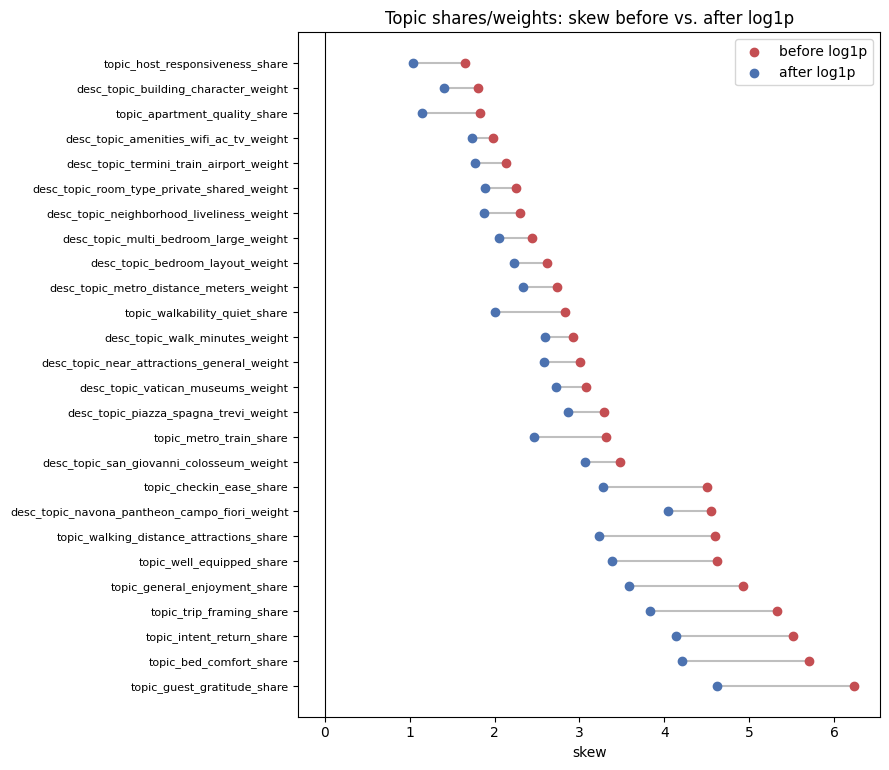

In [105]:
topic_cols_skewed = feature_audit_part2.loc[
    (feature_audit_part2['flag'] == 'skewed') &
    (feature_audit_part2['column'].str.startswith(('topic_', 'desc_topic_'))),
    'column'
].tolist()

topic_skew_check = skew_before_after(listings_nlp, topic_cols_skewed)
display(topic_skew_check)
plot_skew_dumbbell(topic_skew_check, 'Topic shares/weights: skew before vs. after log1p')

Log1p's benefit varies systematically by variable family rather than case by case. Splitting the 26 skewed topic columns at `skew_after > 3` yields three groups:

- **Bin (10)**: `topic_guest_gratitude_share`, `topic_bed_comfort_share`, `topic_intent_return_share`, `topic_trip_framing_share`, `topic_general_enjoyment_share`, `topic_well_equipped_share`, `topic_checkin_ease_share`, `topic_walking_distance_attractions_share`, `desc_topic_navona_pantheon_campo_fiori_weight`, `desc_topic_san_giovanni_colosseum_weight` — log1p leaves these still heavily skewed regardless.
- **Log1p (4)**: `topic_metro_train_share`, `topic_walkability_quiet_share`, `topic_apartment_quality_share`, `topic_host_responsiveness_share` — genuine, sufficient improvement.
- **As-is (12)**: the remaining `desc_topic_*` columns — improvement is consistently too small to justify the transform, a pattern that holds across the entire family rather than a handful of exceptions.

,skew_before,skew_after,improved,note
column,,,,
sentiment_mean,-3.85,-5.60,False,
sentiment_std,1.71,0.93,True,
sentiment_trend,-2.40,NaN,None,log1p undefined (min <= -1)
sentiment_pct_positive,-4.82,-5.98,False,
sentiment_pct_neutral,6.43,4.88,True,


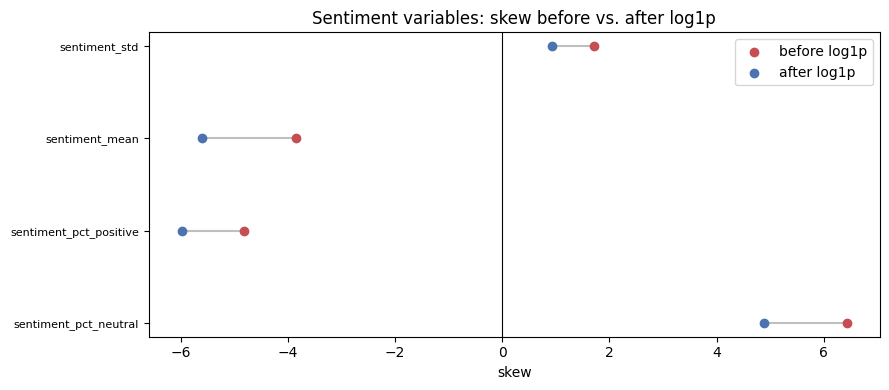

In [106]:
sentiment_cols_skewed = ['sentiment_mean', 'sentiment_std', 'sentiment_trend', 'sentiment_pct_positive', 'sentiment_pct_neutral']

sentiment_skew_check = skew_before_after(listings_nlp, sentiment_cols_skewed)
display(sentiment_skew_check)
plot_skew_dumbbell(sentiment_skew_check, 'Sentiment variables: skew before vs. after log1p')

Only `sentiment_std` benefits genuinely from log1p. `sentiment_mean` and `sentiment_pct_positive` both get *worse* under log1p because of a left, ceiling-driven skew, for which log1p's concave shape is the wrong direction of correction. `sentiment_pct_neutral` technically improves (6.43→4.88) but remains extreme, so the same override applies, and it's handled alongside `sentiment_pct_positive`'s ceiling-inflation flag. `sentiment_trend` can't take a log1p at all (crosses zero) and already has a categorical companion (`sentiment_trend_category`).

In [107]:
BIN_TOPIC_COLS = {
    'topic_guest_gratitude_share', 'topic_bed_comfort_share', 'topic_intent_return_share',
    'desc_topic_navona_pantheon_campo_fiori_weight', 'topic_trip_framing_share',
    'topic_general_enjoyment_share', 'topic_well_equipped_share', 'topic_checkin_ease_share',
    'topic_walking_distance_attractions_share', 'desc_topic_san_giovanni_colosseum_weight',
}
LOG_TOPIC_COLS = {
    'topic_metro_train_share', 'topic_walkability_quiet_share',
    'topic_apartment_quality_share', 'topic_host_responsiveness_share',
}
ASIS_TOPIC_COLS = set(topic_cols_skewed) - BIN_TOPIC_COLS - LOG_TOPIC_COLS

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_19198/553944729.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  listings_nlp[f'{col}_log'] = np.log1p(listings_nlp[col])


log1p applied to: ['sentiment_std', 'topic_apartment_quality_share', 'topic_host_responsiveness_share', 'topic_metro_train_share', 'topic_walkability_quiet_share']


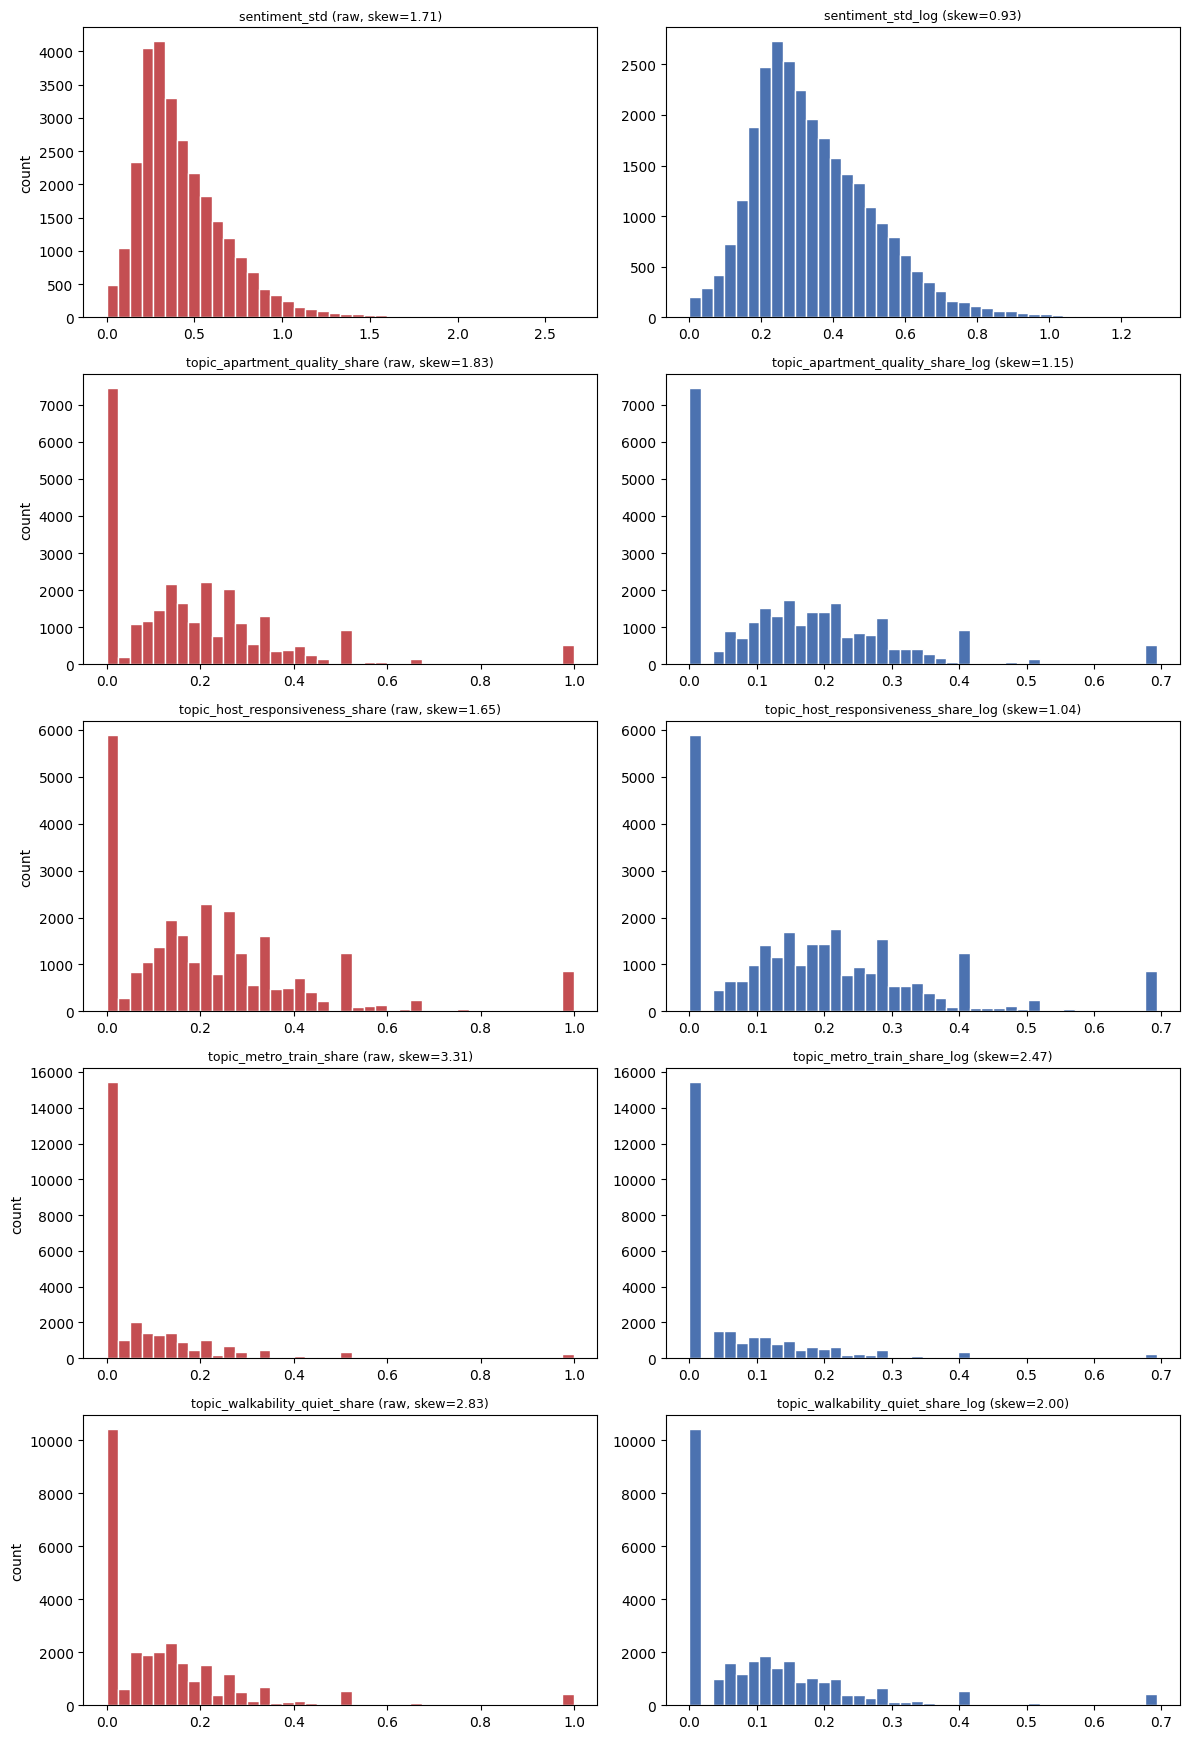

In [108]:
# log1p: 4 topic columns with genuine improvement, plus sentiment_std
for col in LOG_TOPIC_COLS | {'sentiment_std'}:
    listings_nlp[f'{col}_log'] = np.log1p(listings_nlp[col])

listings_nlp = listings_nlp.copy()
print(f"log1p applied to: {sorted(LOG_TOPIC_COLS | {'sentiment_std'})}")

log_applied_cols = sorted(LOG_TOPIC_COLS | {'sentiment_std'})

fig, axes = plt.subplots(len(log_applied_cols), 2, figsize=(12, 3.5 * len(log_applied_cols)))

for i, col in enumerate(log_applied_cols):
    raw_data = listings_nlp[col].dropna()
    log_data = listings_nlp[f'{col}_log'].dropna()

    axes[i, 0].hist(raw_data, bins=40, color='#c44e52', edgecolor='white')
    axes[i, 0].set_title(f'{col} (raw, skew={scipy_skew(raw_data):.2f})', fontsize=9)
    axes[i, 0].set_ylabel('count')

    axes[i, 1].hist(log_data, bins=40, color='#4c72b0', edgecolor='white')
    axes[i, 1].set_title(f'{col}_log (skew={scipy_skew(log_data):.2f})', fontsize=9)

plt.tight_layout()
plt.show()

Visual inspection after transforming revealed a gap the numeric threshold alone missed: `topic_metro_train_share` and `topic_walkability_quiet_share` cleared `skew_after > 3` but showed the same unresolved zero-spike shape as the ten already-binned columns. log1p compressed the scale without meaningfully redistributing the point-mass at zero. Both are moved to binning instead. Only `topic_apartment_quality_share` and `topic_host_responsiveness_share` keep their log1p transform.

In [109]:
listings_nlp = listings_nlp.drop(columns=['topic_metro_train_share_log', 'topic_walkability_quiet_share_log'])

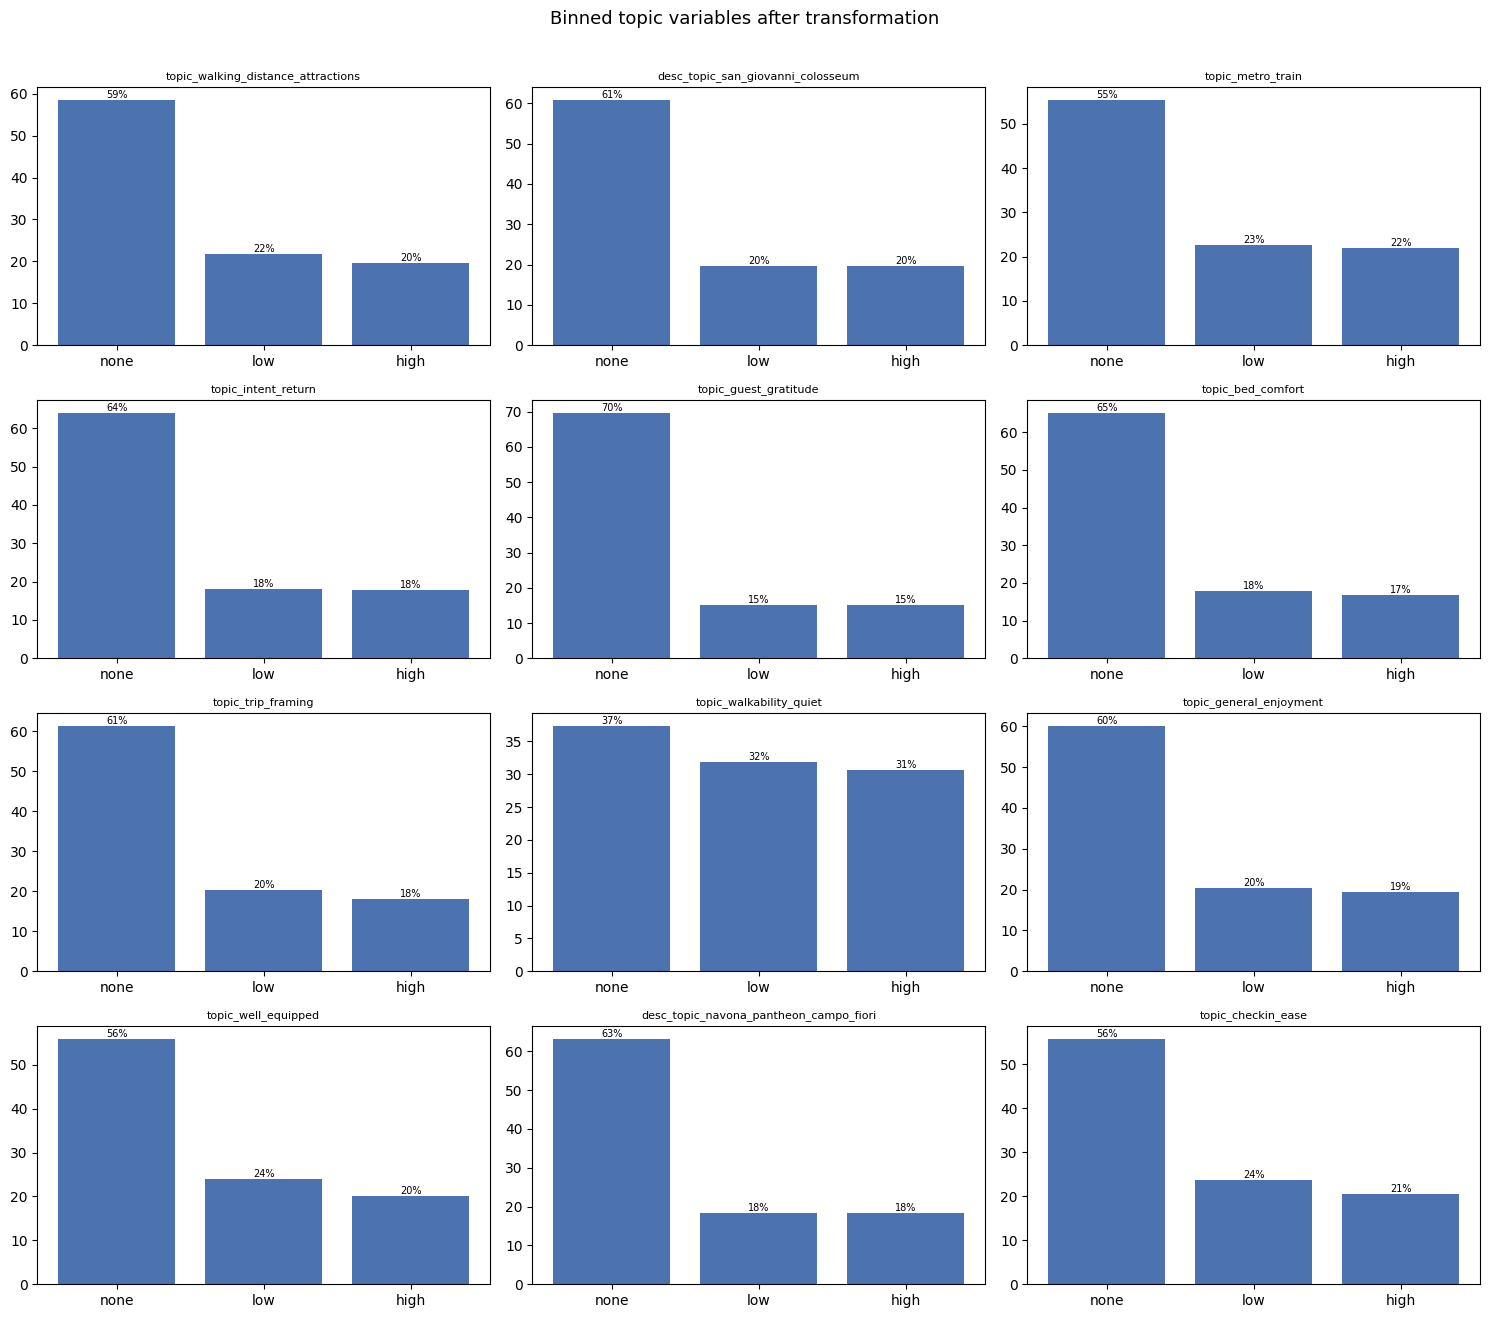

In [110]:
BIN_TOPIC_COLS |= {'topic_metro_train_share', 'topic_walkability_quiet_share'}
LOG_TOPIC_COLS -= {'topic_metro_train_share', 'topic_walkability_quiet_share'}

# bin: 3-tier split at each column's own non-zero median
def bin_zero_inflated(series, labels=('none', 'low', 'high')):
    result = pd.Series(index=series.index, dtype='object')
    result[series == 0] = labels[0]
    nonzero = series[series > 0]
    if len(nonzero) > 0:
        median_nonzero = nonzero.median()
        result[(series > 0) & (series <= median_nonzero)] = labels[1]
        result[series > median_nonzero] = labels[2]
    result[series.isna()] = np.nan
    return result

for col in BIN_TOPIC_COLS:
    listings_nlp[f'{col}_binned'] = bin_zero_inflated(listings_nlp[col])

listings_nlp = listings_nlp.copy()

binned_final_cols = [f'{c}_binned' for c in BIN_TOPIC_COLS]

fig, axes = plt.subplots(4, 3, figsize=(15, 13))
axes = axes.flatten()

for ax, col in zip(axes, binned_final_cols):
    pct = listings_nlp[col].value_counts(normalize=True).reindex(['none', 'low', 'high']).mul(100)
    ax.bar(pct.index, pct.values, color='#4c72b0')
    ax.set_title(col.replace('_share_binned', '').replace('_weight_binned', ''), fontsize=8)
    for i, v in enumerate(pct.values):
        ax.text(i, v, f'{v:.0f}%', ha='center', va='bottom', fontsize=7)

for ax in axes[len(binned_final_cols):]:
    ax.set_visible(False)

plt.suptitle('Binned topic variables after transformation', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

All binned columns show stable, non-degenerate three-way splits. `none` ranges 37.4-69.7%, with `low`/`high` splitting the remainder close to evenly (roughly 15-24% each), consistent with the split point being each column's own non-zero median by construction.

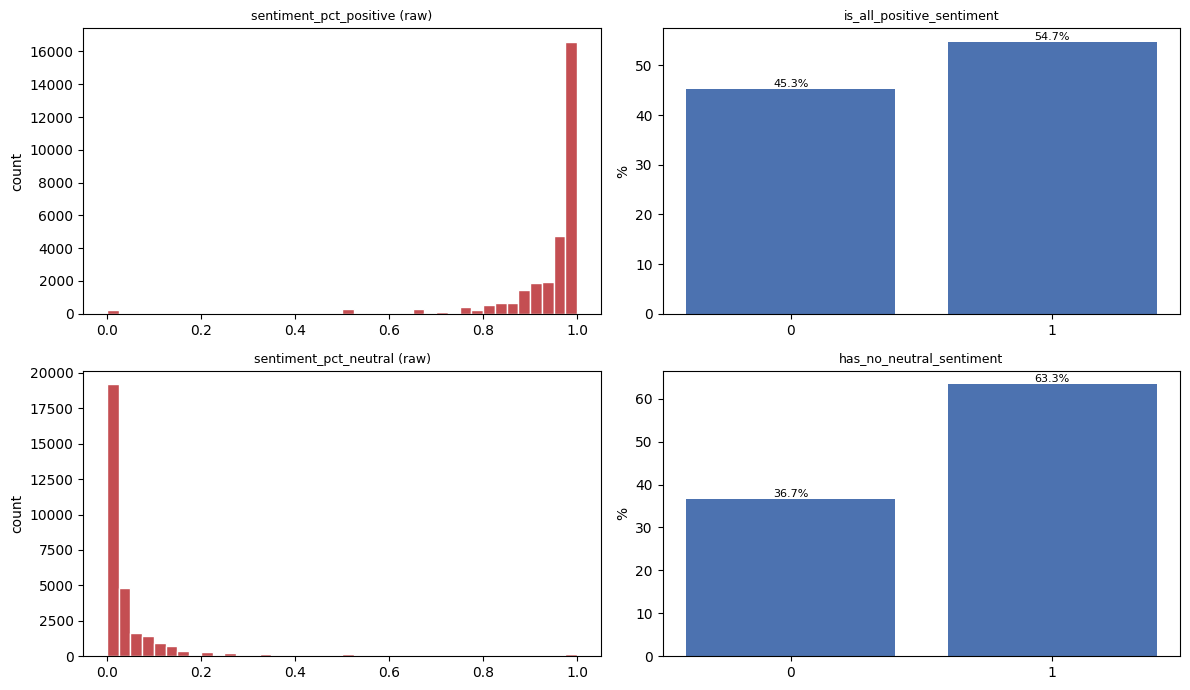

In [111]:
# sentiment_pct_positive: ceiling-inflation flag
listings_nlp['is_all_positive_sentiment'] = (listings_nlp['sentiment_pct_positive'] == 1.0).astype('Int64')
listings_nlp.loc[listings_nlp['sentiment_pct_positive'].isna(), 'is_all_positive_sentiment'] = pd.NA

listings_nlp['has_no_neutral_sentiment'] = (listings_nlp['sentiment_pct_neutral'] == 0).astype('Int64')
listings_nlp.loc[listings_nlp['sentiment_pct_neutral'].isna(), 'has_no_neutral_sentiment'] = pd.NA

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for i, (raw_col, flag_col) in enumerate([('sentiment_pct_positive', 'is_all_positive_sentiment'),
                                           ('sentiment_pct_neutral', 'has_no_neutral_sentiment')]):
    raw_data = listings_nlp[raw_col].dropna()
    axes[i, 0].hist(raw_data, bins=40, color='#c44e52', edgecolor='white')
    axes[i, 0].set_title(f'{raw_col} (raw)', fontsize=9)
    axes[i, 0].set_ylabel('count')

    flag_pct = listings_nlp[flag_col].value_counts(normalize=True, dropna=True).mul(100)
    axes[i, 1].bar(['0', '1'], [flag_pct.get(0, 0), flag_pct.get(1, 0)], color='#4c72b0')
    axes[i, 1].set_title(f'{flag_col}', fontsize=9)
    axes[i, 1].set_ylabel('%')
    for j, v in enumerate([flag_pct.get(0, 0), flag_pct.get(1, 0)]):
        axes[i, 1].text(j, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


Both flags split their raw distribution close to the actual point mass they're built around. `sentiment_pct_positive` piles up hard at 1.0, and `is_all_positive_sentiment` captures that exactly: 54.7% of listings have every valid review scored positive. `sentiment_pct_neutral` mirrors this from the opposite end, as 63.3% of listings have literally zero neutral reviews (`has_no_neutral_sentiment=1`), consistent with its raw histogram's dominant spike at 0.0.

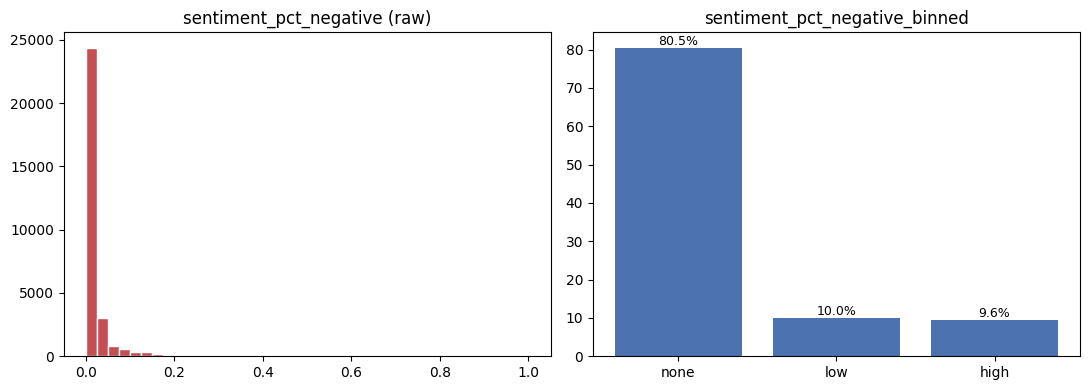

In [112]:
# sentiment_pct_negative: zero-inflated (moderate) column
listings_nlp['sentiment_pct_negative_binned'] = bin_zero_inflated(listings_nlp['sentiment_pct_negative'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(listings_nlp['sentiment_pct_negative'].dropna(), bins=40, color='#c44e52', edgecolor='white')
axes[0].set_title('sentiment_pct_negative (raw)')
bin_pct = listings_nlp['sentiment_pct_negative_binned'].value_counts(normalize=True).reindex(['none','low','high']).mul(100)
axes[1].bar(bin_pct.index, bin_pct.values, color='#4c72b0')
axes[1].set_title('sentiment_pct_negative_binned')
for i, v in enumerate(bin_pct.values):
    axes[1].text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

`sentiment_pct_negative_binned` is not degenerate but is heavily lopsided (80.5% `none`). A listing having *any* negative-scored reviews at all is already the exception, not the norm. `low` and `high` split the remaining ~20% close to evenly (10.0% vs. 9.6%), so among listings that do have some negative signal, the binning still distinguishes a little from a lot.

### 7.4 Redundancy Within the NLP Feature Set

Building this feature set across two notebooks left two different kinds of redundancy to resolve, and they need separate treatment. The first is mechanical: dozens of raw columns now sit alongside a derived companion (a binary flag, a 3-tier bin, or a log1p version), built specifically because the raw column didn't behave well as a plain continuous variable. The second is substantive: variables built independently in different sections, might measure overlapping ground without ever having been compared directly. This subsection works through the first kind.

#### 7.4.1 Raw vs. Derived Version Pairs

In [113]:
def to_flag_name(col):
    for suffix in ('_density', '_count'):
        if col.endswith(suffix):
            return f'has_{col[:-len(suffix)]}'
    return f'has_{col}'

IRREGULAR_DERIVED_MAP = {
    'sentiment_pct_positive': ['is_all_positive_sentiment'],
    'sentiment_pct_neutral': ['has_no_neutral_sentiment'],
}

family_groups = {}
for col in nlp_candidate_cols:
    derived = []
    if f'{col}_log' in listings_nlp.columns:
        derived.append(f'{col}_log')
    if f'{col}_binned' in listings_nlp.columns:
        derived.append(f'{col}_binned')
    flag_name = to_flag_name(col)
    if flag_name in listings_nlp.columns and flag_name != col:
        derived.append(flag_name)
    derived += [c for c in IRREGULAR_DERIVED_MAP.get(col, []) if c in listings_nlp.columns]
    if derived:
        family_groups[col] = derived

print(f"{len(family_groups)} raw columns have at least one derived companion")
for raw, derived in sorted(family_groups.items()):
    print(f"  {raw} -> {derived}")

84 raw columns have at least one derived companion
  desc_topic_navona_pantheon_campo_fiori_weight -> ['desc_topic_navona_pantheon_campo_fiori_weight_binned']
  desc_topic_san_giovanni_colosseum_weight -> ['desc_topic_san_giovanni_colosseum_weight_binned']
  description_atmosphere_lively_density -> ['description_atmosphere_lively_density_log']
  description_atmosphere_quiet_density -> ['description_atmosphere_quiet_density_log']
  description_authenticity_density -> ['description_authenticity_density_log']
  description_budget_density -> ['description_budget_density_binned']
  description_direct_address_density -> ['description_direct_address_density_log']
  description_exclaim_count -> ['description_exclaim_count_binned']
  description_family_density -> ['description_family_density_binned']
  description_landmark_count -> ['description_landmark_count_log']
  description_luxury_density -> ['description_luxury_density_log']
  description_mtld -> ['description_mtld_log']
  description_pr

In [114]:
# sanity check if any derived-looking column that didn't get matched to a raw parent
all_derived_found = {d for derived in family_groups.values() for d in derived}
suffix_like = [c for c in nlp_candidate_cols if c.endswith(('_log', '_binned')) or c.startswith(('has_', 'is_'))]
orphans = set(suffix_like) - all_derived_found
print(f"\nunmatched derived-looking columns: {len(orphans)}")
print(sorted(orphans))


unmatched derived-looking columns: 4
['has_description', 'has_host_about', 'has_name', 'has_neighborhood_overview']


84 raw columns have exactly one derived companion each, built across two separate skew/zero-inflation audits: Part 1 (§4.5) flagged 45 columns skewed and applied log1p to 41 of them; Part 2 (§7.3) separately flagged 31 columns skewed, splitting them via visual inspection into 12 binned, 3 kept as log1p, and the rest left as-is or resolved via ceiling-inflation flags. Combined with the zero-inflation flags and bins from both notebooks, every derived column was built specifically because its raw parent didn't behave well as a plain continuous variable, so for all 84 families, the raw version is dropped and the derived one retained.

In [115]:
LOG_FAMILIES = {raw: derived[0] for raw, derived in family_groups.items() if derived[0].endswith('_log')}
BIN_FAMILIES = {raw: derived[0] for raw, derived in family_groups.items() if derived[0].endswith('_binned')}
FLAG_FAMILIES = {raw: derived[0] for raw, derived in family_groups.items()
                 if not derived[0].endswith(('_log', '_binned'))}

print(f"log families: {len(LOG_FAMILIES)}, bin families: {len(BIN_FAMILIES)}, flag families: {len(FLAG_FAMILIES)}, "
      f"total: {len(LOG_FAMILIES)+len(BIN_FAMILIES)+len(FLAG_FAMILIES)}")

log families: 44, bin families: 21, flag families: 19, total: 84


In [116]:
# binning ranges
DISCRETE_COUNT_BIN = 'description_exclaim_count'

bin_boundary_rows = []
for raw_col in BIN_FAMILIES:
    if raw_col == DISCRETE_COUNT_BIN:
        bin_boundary_rows.append({
            'column': raw_col, 'none_range': '0', 'low_range': '1', 'high_range': '2+'
        })
        continue
    nonzero = listings_nlp.loc[listings_nlp[raw_col] > 0, raw_col]
    median_nonzero = nonzero.median()
    bin_boundary_rows.append({
        'column': raw_col,
        'none_range': '= 0',
        'low_range': f'(0, {median_nonzero:.4f}]',
        'high_range': f'> {median_nonzero:.4f}',
    })

bin_boundaries = pd.DataFrame(bin_boundary_rows).set_index('column')
pd.set_option('display.max_rows', None)
display(bin_boundaries)

,none_range,low_range,high_range
column,,,
desc_topic_navona_pantheon_campo_fiori_weight,= 0,"(0, 0.0267]",> 0.0267
desc_topic_san_giovanni_colosseum_weight,= 0,"(0, 0.0463]",> 0.0463
description_budget_density,= 0,"(0, 1.3890]",> 1.3890
description_exclaim_count,0,1,2+
description_family_density,= 0,"(0, 1.4080]",> 1.4080
description_romantic_density,= 0,"(0, 1.3700]",> 1.3700
description_we_ref_density,= 0,"(0, 1.5380]",> 1.5380
host_about_family_density,= 0,"(0, 1.4930]",> 1.4930
neighborhood_overview_luxury_density,= 0,"(0, 1.3330]",> 1.3330


In [117]:
# ceiling floor flags ranges
CEILING_FLOOR_FLAGS = {'sentiment_pct_positive': '== 1.0', 'sentiment_pct_neutral': '== 0'}

flag_threshold_rows = [
    {'column': raw_col, 'flag_column': flag_col,
     'threshold': CEILING_FLOOR_FLAGS.get(raw_col, '> 0')}
    for raw_col, flag_col in FLAG_FAMILIES.items()
]
display(pd.DataFrame(flag_threshold_rows).set_index('column'))

,flag_column,threshold
column,,
description_professionalism_density,has_description_professionalism,> 0
description_question_count,has_description_question,> 0
description_self_ref_density,has_description_self_ref,> 0
host_about_atmosphere_lively_density,has_host_about_atmosphere_lively,> 0
host_about_atmosphere_quiet_density,has_host_about_atmosphere_quiet,> 0
host_about_budget_density,has_host_about_budget,> 0
host_about_landmark_count,has_host_about_landmark,> 0
host_about_luxury_density,has_host_about_luxury,> 0
host_about_professionalism_density,has_host_about_professionalism,> 0


In [118]:
# drop all 84 raw parents at once, keep only their derived companions
raw_to_drop = list(family_groups.keys())
listings_nlp_features = listings_nlp.drop(columns=raw_to_drop)
print(f"dropped {len(raw_to_drop)} raw columns; working frame now {listings_nlp_features.shape[1]} columns")

dropped 84 raw columns; working frame now 267 columns


#### 7.4.2 Substantive Redundancy Across Methods

Two pairs already surfaced without a resolution: `avg_review_length` vs. `median_review_length` and `sentiment_trend` vs. `sentiment_trend_category`. Both are resolved directly here, alongside a third, related "length" signal (`review_char_count`, Part 1 stylometry) that was never checked against either. A broader systematic scan then covers the rest of the feature set for anything not anticipated.

In [119]:
length_cluster = ['avg_review_length', 'median_review_length', 'review_char_count']
length_corr = listings_nlp[length_cluster].corr()
display(length_corr.round(3))

,avg_review_length,median_review_length,review_char_count
avg_review_length,1.000,0.949,0.999
median_review_length,0.949,1.000,0.920
review_char_count,0.999,0.920,1.000


Between `review_char_count` and `median_review_length`, only the median is kept. Both summarize the same underlying per-review length distribution and both independently resisted log1p in Part 1. The same failure mode, confirming this is a genuinely right-skewed distribution rather than two variables behaving differently by chance. The median is the more robust central-tendency choice for that shape, less pulled by the rare unusually long review than the mean is; with correlation already at 0.92-0.95, the two capture largely overlapping variance, so keeping both would mean carrying near-duplicate signal into clustering rather than adding anything the median alone doesn't already represent.

In [120]:
listings_nlp_features = listings_nlp_features.drop(columns=['avg_review_length', 'review_char_count'])
print(f"working frame: {listings_nlp_features.shape[1]} columns")

working frame: 265 columns


In [121]:
# sentiment_trend vs. its categorical companion
trend_by_category = listings_nlp.groupby('sentiment_trend_category', observed=True)['sentiment_trend'].agg(['mean', 'std', 'count'])
display(trend_by_category)

,mean,std,count
sentiment_trend_category,,,
declining,-0.062837,0.104194,1017
improving,0.058106,0.088012,445
stable,-0.008674,0.115987,24979
unavailable,NaN,NaN,0


`sentiment_trend_category`'s `unavailable` count of 0 in this table is definitional, as the category is assigned `unavailable` when raw `sentiment_trend` is missing.

The category is kept over the raw slope: group means run in the sensible direction (`declining` -0.06, `improving` +0.06, `stable` -0.01), but `stable`'s spread (std=0.12) is wider than the gap between the other two groups, meaning the raw number alone can't reliably separate a genuine trend from small-sample noise, which is exactly what the category's underlying significance test was built to resolve. Raw `sentiment_trend` is dropped as redundant with the version that already accounts for that noise.

In [122]:
listings_nlp_features = listings_nlp_features.drop(columns=['sentiment_trend'])
print(f"working frame: {listings_nlp_features.shape[1]} columns")

working frame: 264 columns


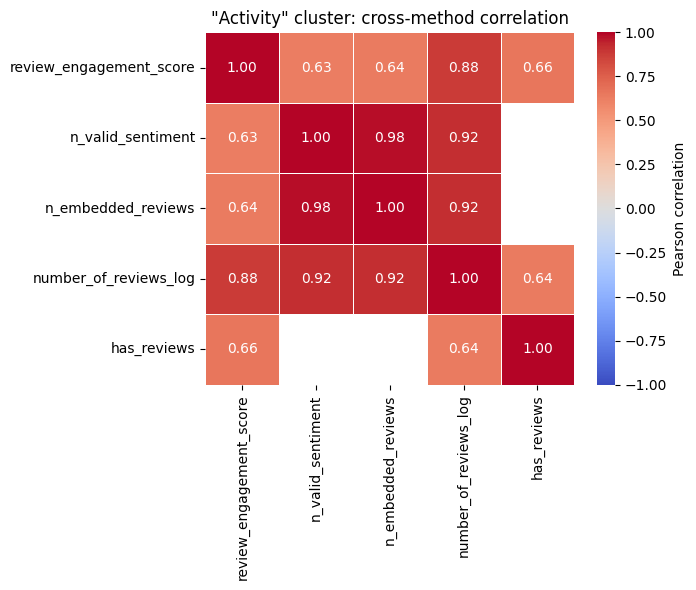

In [123]:
# activity cluster cross method correlation
activity_cluster = ['review_engagement_score', 'n_valid_sentiment', 'n_embedded_reviews',
                     'number_of_reviews_log', 'has_reviews']
activity_corr = listings_nlp[activity_cluster].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(activity_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0,
            linewidths=0.5, cbar_kws={'label': 'Pearson correlation'}, ax=ax)
ax.set_title('"Activity" cluster: cross-method correlation')
plt.tight_layout()
plt.show()

The single `NaN` block (`has_reviews` against `n_valid_sentiment`/`n_embedded_reviews`) is structural: wherever the latter two are defined at all, `has_reviews` is necessarily always 1 (a listing can't have valid sentiment scores with zero reviews), so it carries no variance in that paired subset and correlation is undefined by construction.

`n_valid_sentiment` and `n_embedded_reviews` correlate at 0.982. Both are counts drawn from the same capped `reviews_sampled`, differing only in language restriction (six `nlptown` languages vs. none). `n_embedded_reviews`, the more general of the two, is kept.

`number_of_reviews_log`'s strong correlation with `review_engagement_score` isn't a new cross-method finding so much as an expected consequence of how the composite was built in Part 1: `number_of_reviews` is literally one of `review_engagement_score`'s three z-scored components. Keeping both means partially double-counting that one ingredient.

In [124]:
listings_nlp_features = listings_nlp_features.drop(columns=['n_valid_sentiment', 'number_of_reviews_log'])
print(f"working frame: {listings_nlp_features.shape[1]} columns")

working frame: 262 columns


In [125]:
# map every field-repeated measurement
FIELDS = ['description', 'host_about', 'neighborhood_overview', 'review']

def find_final_col(base_col):
    for suffix in ('', '_log', '_binned'):
        candidate = f'{base_col}{suffix}'
        if candidate in listings_nlp_features.columns:
            return candidate
    flag_name = to_flag_name(base_col)
    if flag_name in listings_nlp_features.columns:
        return flag_name
    return None

MEASURE_FIELD_SCOPE = {
    'luxury_density': FIELDS, 'family_density': FIELDS, 'budget_density': FIELDS,
    'romantic_density': FIELDS, 'authenticity_density': FIELDS,
    'atmosphere_quiet_density': FIELDS, 'atmosphere_lively_density': FIELDS,
    'landmark_count': ['description', 'host_about', 'neighborhood_overview'],
    'professionalism_density': ['description', 'host_about'],
    'transport_density': ['description', 'neighborhood_overview', 'review'],
    'mtld': FIELDS, 'readability': FIELDS,
    'self_ref_density': FIELDS, 'we_ref_density': FIELDS, 'direct_address_density': FIELDS,
    'word_count': FIELDS, 'sentence_count': FIELDS, 'punct_density': FIELDS,
    'exclaim_count': FIELDS, 'question_count': FIELDS,
}

all_field_families = {}
for measure, fields in MEASURE_FIELD_SCOPE.items():
    cols = {}
    for field in fields:
        found = find_final_col(f'{field}_{measure}')
        if found:
            cols[field] = found
    if len(cols) >= 2:
        all_field_families[measure] = cols

print(f"{len(all_field_families)} field-repeated measurement families total")
for measure, cols in all_field_families.items():
    print(f"  {measure}: {cols}")

20 field-repeated measurement families total
  luxury_density: {'description': 'description_luxury_density_log', 'host_about': 'has_host_about_luxury', 'neighborhood_overview': 'neighborhood_overview_luxury_density_binned', 'review': 'review_luxury_density_log'}
  family_density: {'description': 'description_family_density_binned', 'host_about': 'host_about_family_density_binned', 'neighborhood_overview': 'has_neighborhood_overview_family', 'review': 'review_family_density_log'}
  budget_density: {'description': 'description_budget_density_binned', 'host_about': 'has_host_about_budget', 'neighborhood_overview': 'has_neighborhood_overview_budget', 'review': 'review_budget_density_log'}
  romantic_density: {'description': 'description_romantic_density_binned', 'host_about': 'has_host_about_romantic', 'neighborhood_overview': 'has_neighborhood_overview_romantic', 'review': 'review_romantic_density_log'}
  authenticity_density: {'description': 'description_authenticity_density_log', 'host_

In [126]:
# сross-field lexicon consistency
def to_ordinal(series):
    ordinal_maps = [
        {'none': 0, 'low': 1, 'high': 2},
        {'0': 0, '1': 1, '2+': 2},
        {'Low': 0, 'Typical': 1, 'High': 2},
        {'Below Standard': 0, 'Standard+': 1},
        {'0 Bedrooms': 0, '1 Bedroom': 1, '2 Bedrooms': 2, '3+ Bedrooms': 3},
        {'Partial Acceptance': 0, 'Full Acceptance': 1},
        {'Partial Response': 0, 'Full Response': 1},
        {'Dormant': 0, 'Moderate': 1, 'Active': 2},
        {'Low Demand': 0, 'Moderate Demand': 1, 'High Demand': 2},
        {'declining': 0, 'stable': 1, 'improving': 2, 'unavailable': np.nan},
    ]
    NO_ORDINAL_POSITION = {'Studio', 'Unknown'}

    if pd.api.types.is_numeric_dtype(series):
        return series

    unique_non_na = set(series.dropna().unique()) - NO_ORDINAL_POSITION
    for mapping in ordinal_maps:
        if unique_non_na <= set(mapping.keys()):
            result = series.map(mapping)
            result[series.isin(NO_ORDINAL_POSITION)] = np.nan
            return result

    raise ValueError(f"unrecognized label scheme: {sorted(series.dropna().unique())} — "
                      f"check whether this should be in NLP_NOMINAL_COLS instead")

consistency_rows = []
for measure, cols in all_field_families.items():
    fields = list(cols.keys())
    for i in range(len(fields)):
        for j in range(i + 1, len(fields)):
            f1, f2 = fields[i], fields[j]
            s1 = to_ordinal(listings_nlp_features[cols[f1]])
            s2 = to_ordinal(listings_nlp_features[cols[f2]])
            corr = s1.corr(s2, method='spearman')
            consistency_rows.append({'measure': measure, 'field_1': f1, 'field_2': f2, 'spearman_corr': round(corr, 3)})

consistency_table_full = pd.DataFrame(consistency_rows).sort_values('spearman_corr', ascending=False, key=abs)
display(consistency_table_full)

,measure,field_1,field_2,spearman_corr
1,luxury_density,description,neighborhood_overview,0.201
98,exclaim_count,description,neighborhood_overview,0.175
31,atmosphere_quiet_density,description,neighborhood_overview,0.170
82,word_count,host_about,neighborhood_overview,0.165
56,readability,description,neighborhood_overview,0.161
32,atmosphere_quiet_density,description,review,0.157
97,exclaim_count,description,host_about,0.155
43,landmark_count,description,neighborhood_overview,0.149
68,we_ref_density,description,neighborhood_overview,0.141
92,punct_density,description,neighborhood_overview,0.140


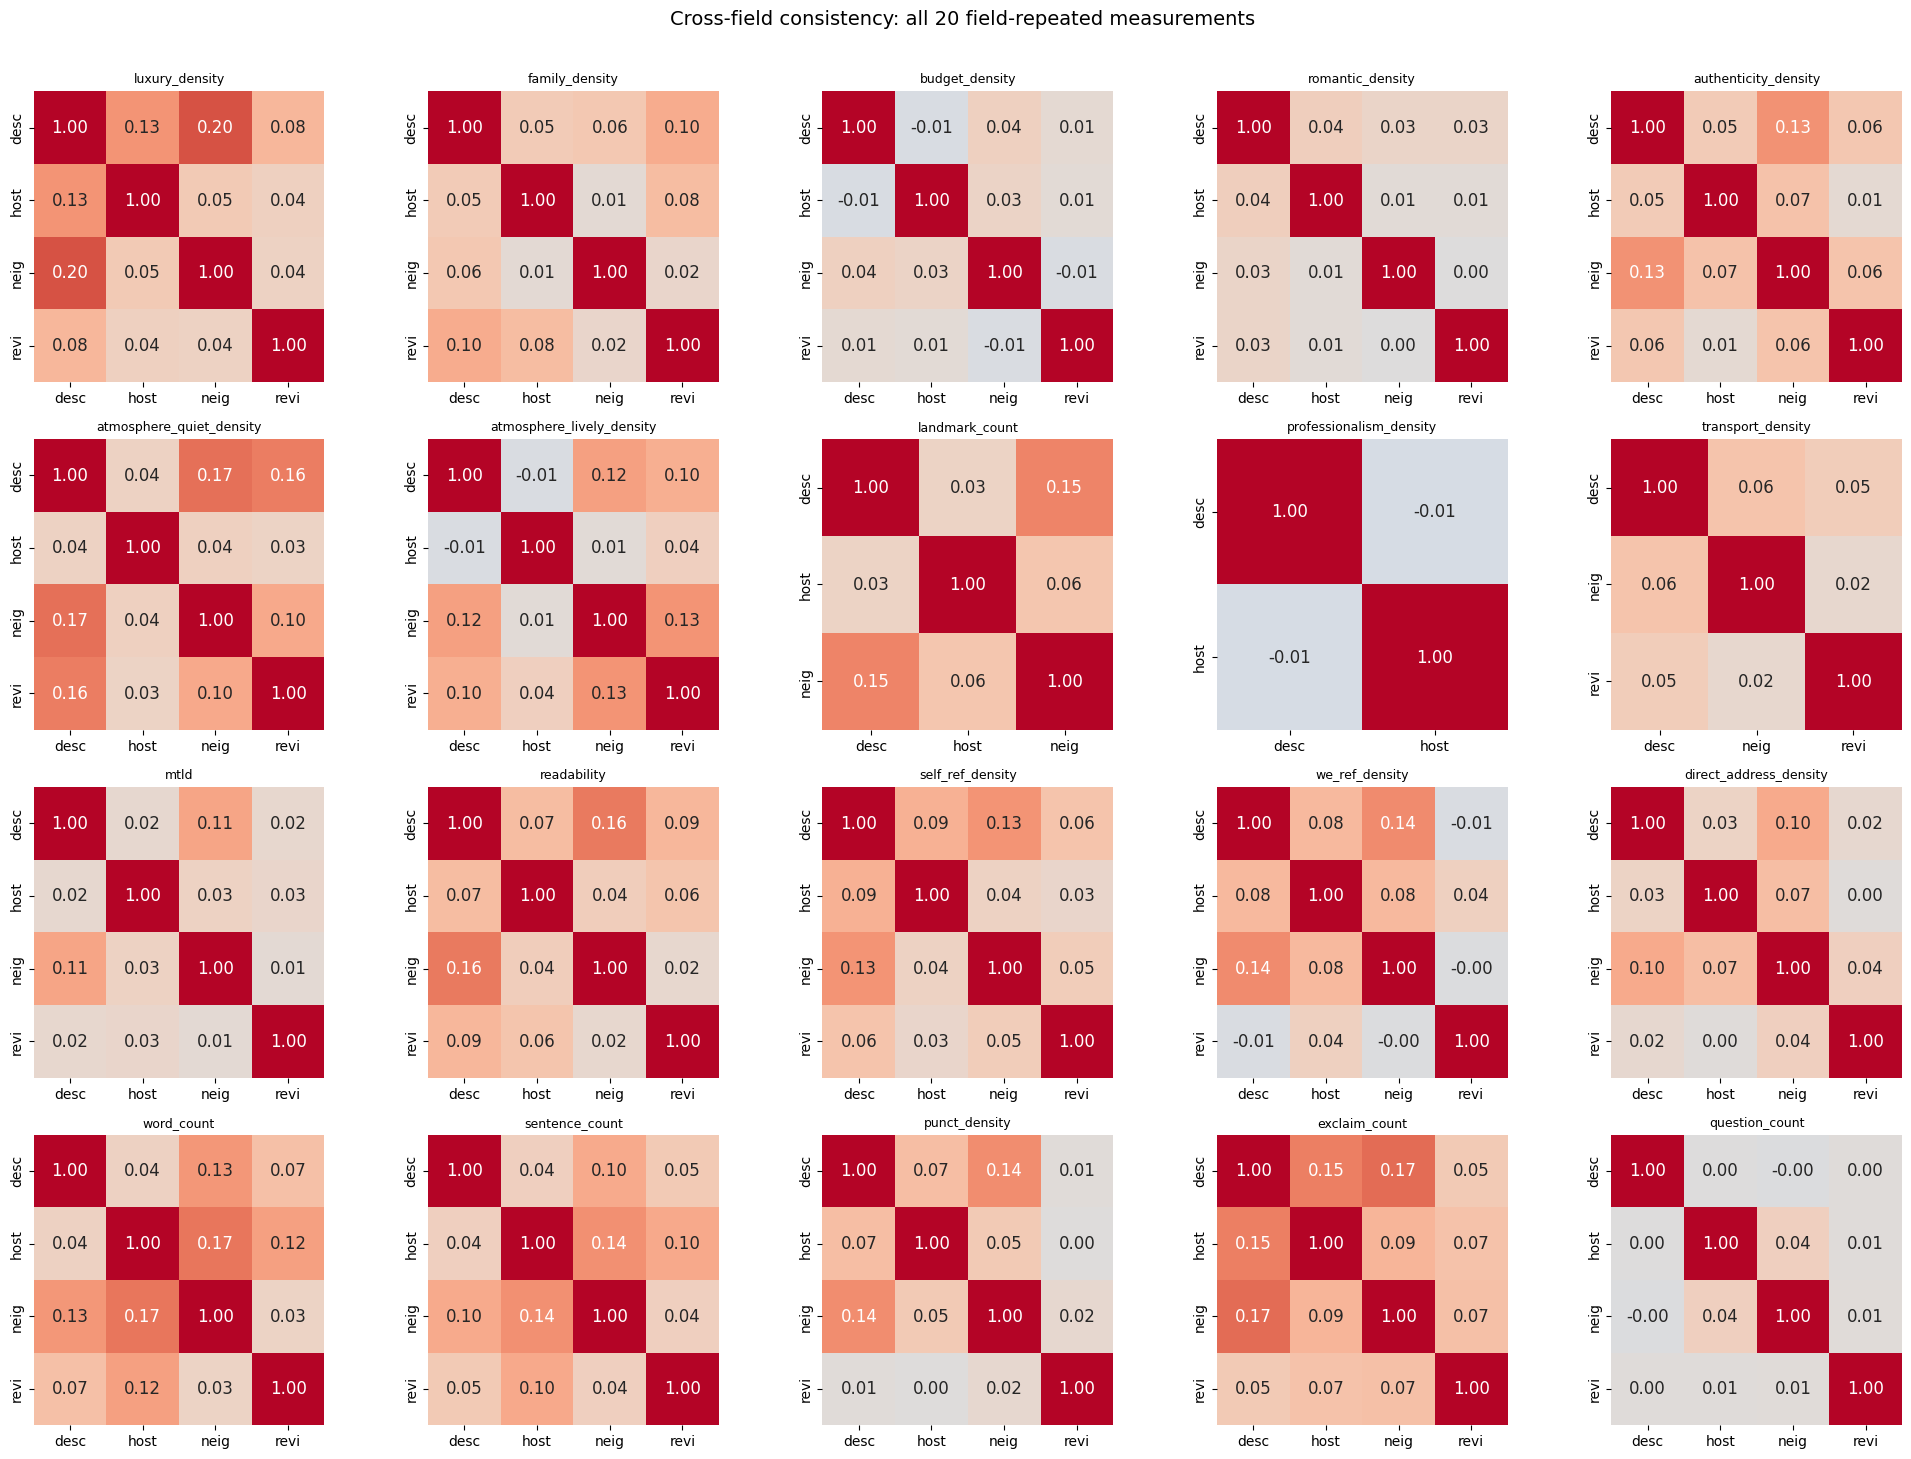

In [127]:
FIELD_ORDER = ['description', 'host_about', 'neighborhood_overview', 'review']

n_measures = len(all_field_families)
n_cols = 5
n_rows = -(-n_measures // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.6 * n_rows))
axes = axes.flatten()

for ax, (measure, cols) in zip(axes, all_field_families.items()):
    fields_present = [f for f in FIELD_ORDER if f in cols]
    matrix = pd.DataFrame(1.0, index=fields_present, columns=fields_present)
    for f1 in fields_present:
        for f2 in fields_present:
            if f1 == f2:
                continue
            match = consistency_table_full[
                (consistency_table_full['measure'] == measure) &
                (((consistency_table_full['field_1'] == f1) & (consistency_table_full['field_2'] == f2)) |
                 ((consistency_table_full['field_1'] == f2) & (consistency_table_full['field_2'] == f1)))
            ]
            if len(match):
                matrix.loc[f1, f2] = match['spearman_corr'].values[0]

    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-0.25, vmax=0.25, center=0,
                cbar=False, square=True, annot_kws={'size': 12},
                xticklabels=[f[:4] for f in fields_present], yticklabels=[f[:4] for f in fields_present], ax=ax)
    ax.set_title(measure, fontsize=9)

for ax in axes[len(all_field_families):]:
    ax.set_visible(False)

plt.suptitle('Cross-field consistency: all 20 field-repeated measurements', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

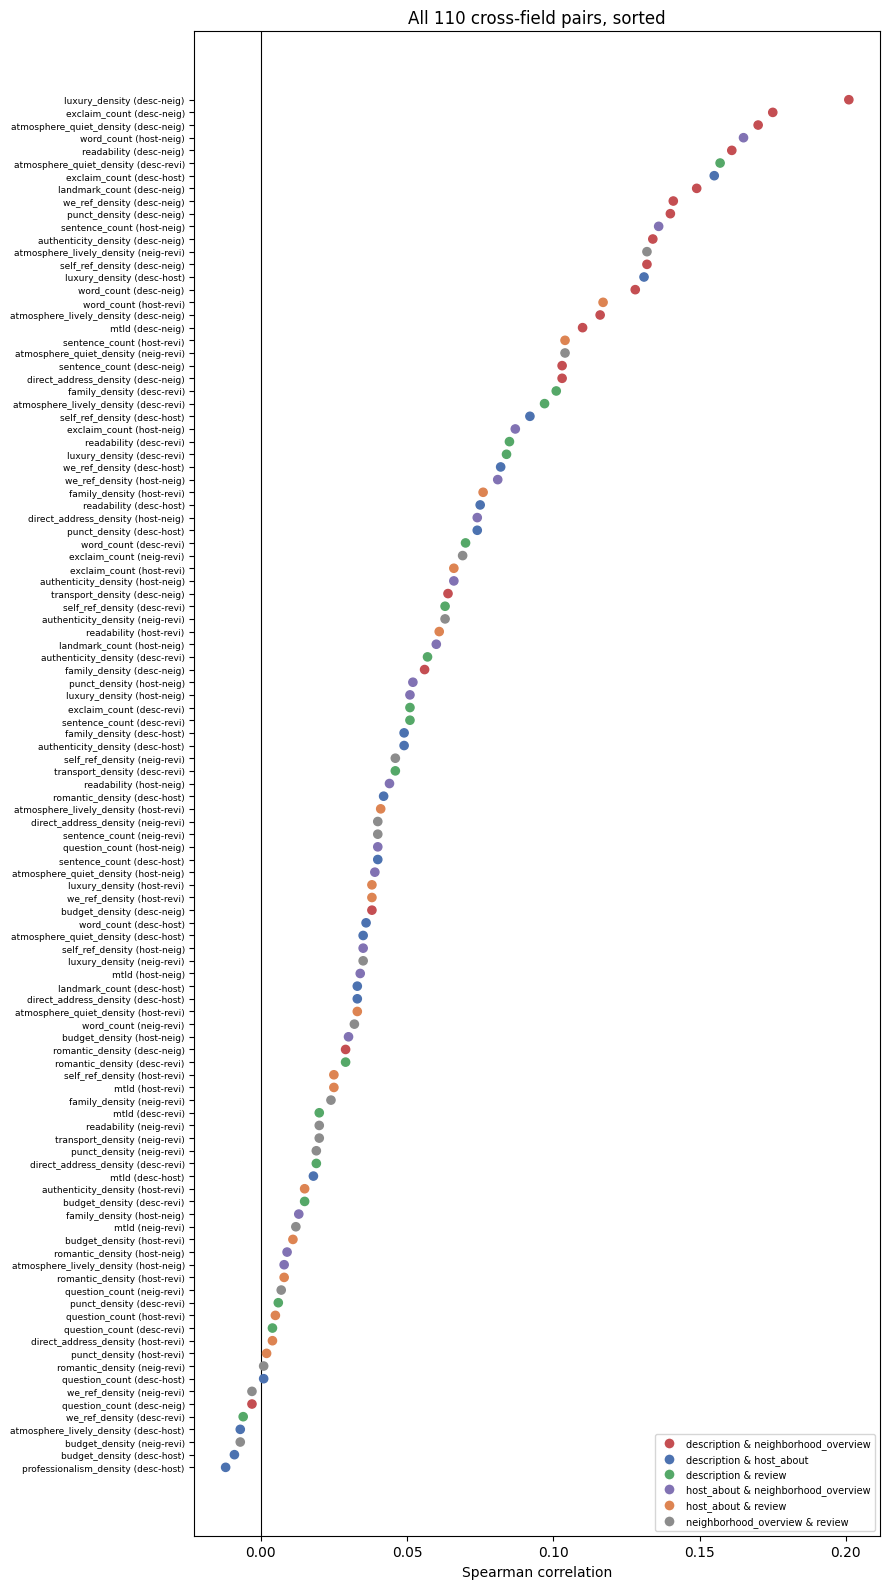

In [128]:
FIELD_PAIR_COLORS = {
    frozenset(['description', 'neighborhood_overview']): '#c44e52',
    frozenset(['description', 'host_about']): '#4c72b0',
    frozenset(['description', 'review']): '#55a868',
    frozenset(['host_about', 'neighborhood_overview']): '#8172b3',
    frozenset(['host_about', 'review']): '#dd8452',
    frozenset(['neighborhood_overview', 'review']): '#8c8c8c',
}

plot_data = consistency_table_full.sort_values('spearman_corr').reset_index(drop=True)
plot_data['pair_key'] = plot_data.apply(lambda r: frozenset([r['field_1'], r['field_2']]), axis=1)
plot_data['color'] = plot_data['pair_key'].map(FIELD_PAIR_COLORS)

fig, ax = plt.subplots(figsize=(9, 16))
ax.scatter(plot_data['spearman_corr'], range(len(plot_data)), c=plot_data['color'], s=35, zorder=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels([f"{m} ({f1[:4]}-{f2[:4]})" for m, f1, f2 in
                     zip(plot_data['measure'], plot_data['field_1'], plot_data['field_2'])], fontsize=6.5)
ax.set_xlabel('Spearman correlation')
ax.set_title('All 110 cross-field pairs, sorted', fontsize=12)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=' & '.join(sorted(k)))
                    for k, c in FIELD_PAIR_COLORS.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=7)

plt.tight_layout()
plt.show()

No cross-field pair exceeds a Spearman correlation of 0.20, across all 110 comparisons spanning every field-repeated measurement in the feature set (tone lexicons, landmark/professionalism/transport density, and the full stylometric block (MTLD, readability, personalization, length, punctuation)). This directly answers the question this check was built to ask: hosts are not consistently "on-brand" across text fields, in tone or in writing style alike. A host who frames their description as luxury doesn't reliably carry that framing into their neighborhood overview or host bio. What guests independently write in reviews tracks host-authored framing even more weakly still.

The one systematic pattern worth naming: `description`↔`neighborhood_overview` is the strongest-correlating field pair for most measures where both fields exist, consistent with both being host-authored marketing copy in the same register, but even this pairing tops out at 0.20, far short of anything resembling duplication.

This is a finding about hosts' writing behavior, not a redundancy problem: each field-measurement combination captures a genuinely distinct signal, and all are kept as-is. No columns are dropped from this check.

`description_lang`, `host_about_lang`, and `neighborhood_overview_lang`, flagged in previously as language metadata with an open question about their role, are deliberately left unresolved here rather than forced into a premature decision. They stay in `listings_nlp_features` as-is. Whether they serve as genuine categorical clustering inputs, get collapsed into a coarser flag, or get dropped is left to the final feature-selection pass after EDA, once their relationship to the rest of the feature set can be judged with the full picture in view.

### 7.5 Redundancy Against the Tabular Feature Set

The NLP block has been checked against itself, this section closes the remaining question, whether any of it duplicates the tabular feature set built before NLP work began. Three steps: first, a cleanup on the tabular side itself, which carries the same unresolved raw/derived pairs the NLP block had before, then a systematic, threshold-based scan across both blocks, split by variable type since continuous/ordinal and purely nominal categoricals need different association measures.

In [129]:
tabular_candidate_cols = sorted(classification[classification == 'other (not NLP)'].index)
EXCLUDE_FROM_TABULAR = {'id', 'host_id', 'price'}
tabular_candidate_cols = [c for c in tabular_candidate_cols if c not in EXCLUDE_FROM_TABULAR]

print(f"{len(tabular_candidate_cols)} tabular candidate columns")
print(sorted(tabular_candidate_cols))

61 tabular candidate columns
['accommodates', 'accommodates_per_bedroom', 'accommodates_per_bedroom_binned', 'amenities_count', 'availability_365', 'availability_365_ratio', 'availability_90', 'availability_ratio', 'bath_private_info', 'bath_shared_info', 'bathroom_count', 'bathroom_per_bedroom', 'bathroom_per_bedroom_binned', 'bathroom_per_bedroom_log', 'bedrooms_binned', 'bedrooms_raw', 'beds', 'beds_log', 'beds_per_bedroom', 'beds_per_bedroom_binned', 'beds_per_bedroom_log', 'calculated_host_listings_count', 'calculated_host_listings_count_log', 'distance_to_center_km', 'distance_to_center_km_log', 'geo_sector', 'has_bbq', 'has_fireplace', 'has_gym', 'has_hot_tub', 'has_outdoor_leisure', 'has_response_data', 'has_reviews', 'has_top5_amenity', 'host_acceptance_rate_binned', 'host_acceptance_rate_raw', 'host_experience_years', 'host_has_profile_pic', 'host_identity_verified', 'host_is_superhost', 'host_is_superhost_was_missing', 'host_neighbourhood', 'host_response_rate_binned', 'host

#### 7.5.1 Tabular Raw vs. Derived Pairs

In [130]:
TABULAR_RAW_DERIVED_PAIRS = {
    'beds': 'beds_log',
    'bathroom_per_bedroom': 'bathroom_per_bedroom_log',  
    'accommodates_per_bedroom': 'accommodates_per_bedroom_binned',
    'distance_to_center_km': 'distance_to_center_km_log',
    'calculated_host_listings_count': 'calculated_host_listings_count_log',
    'bedrooms_raw': 'bedrooms_binned',
    'host_acceptance_rate_raw': 'host_acceptance_rate_binned',
    'host_response_rate_raw': 'host_response_rate_binned',
    'beds_per_bedroom': 'beds_per_bedroom_log',  
}

# three-version families (raw + binned + log)
THREE_VERSION_FAMILIES = ['bathroom_per_bedroom', 'beds_per_bedroom']
for base in THREE_VERSION_FAMILIES:
    print(f"{base}: skew raw={scipy_skew(listings_nlp[base].dropna()):.2f}, "
          f"log={scipy_skew(listings_nlp[f'{base}_log'].dropna()):.2f}")
    print(listings_nlp[f'{base}_binned'].value_counts(normalize=True).mul(100).round(1))
    print()

bathroom_per_bedroom: skew raw=1.30, log=-0.17
bathroom_per_bedroom_binned
Standard+         75.6
Below Standard    20.7
Unknown            2.1
Studio             1.6
Name: proportion, dtype: float64

beds_per_bedroom: skew raw=1.33, log=0.12
beds_per_bedroom_binned
Low        46.3
Typical    43.5
High        6.5
Unknown     2.1
Studio      1.6
Name: proportion, dtype: float64



In [131]:
# both three-version families: log clearly wins 
listings_nlp_features = listings_nlp_features.drop(columns=[
    'bathroom_per_bedroom', 'bathroom_per_bedroom_binned',
    'beds_per_bedroom', 'beds_per_bedroom_binned',
])

# remaining raw/derived pairs: keep the derived version
TABULAR_RAW_DERIVED_PAIRS = {
    'beds': 'beds_log',
    'accommodates_per_bedroom': 'accommodates_per_bedroom_binned',
    'distance_to_center_km': 'distance_to_center_km_log',
    'calculated_host_listings_count': 'calculated_host_listings_count_log',
    'bedrooms_raw': 'bedrooms_binned',
    'host_acceptance_rate_raw': 'host_acceptance_rate_binned',
    'host_response_rate_raw': 'host_response_rate_binned',
}
listings_nlp_features = listings_nlp_features.drop(columns=list(TABULAR_RAW_DERIVED_PAIRS.keys()))

# property_type: 63 raw categories vs. its own 6-group macro-mapping, keep the grouped version
listings_nlp_features = listings_nlp_features.drop(columns=['property_type'])

print(f"working frame: {listings_nlp_features.shape[1]} columns")

working frame: 250 columns


Two three-version families (`bathroom_per_bedroom`, `beds_per_bedroom`) resolve cleanly via log1p, so their `_binned` companions are dropped alongside the raw versions rather than kept for comparison. Seven further raw/derived pairs follow the previously established rule to keep the transformed version, drop the raw parent, and `property_type` (63 raw categories) is dropped in favor of its own 6-group macro-mapping from the Feature Engineering stage.

#### 7.5.2 Scan Setup: Splitting by Variable Type

In [132]:
tabular_final_cols = [c for c in tabular_candidate_cols if c in listings_nlp_features.columns]

# purely nominal categoricals with no natural order
NOMINAL_CATEGORICAL_COLS = ['property_type_grouped', 'room_type', 'geo_sector',
                             'neighbourhood_cleansed', 'host_response_time', 'host_neighbourhood']

tabular_ordinal_cols = [c for c in tabular_final_cols if c not in NOMINAL_CATEGORICAL_COLS]
tabular_nominal_cols = [c for c in tabular_final_cols if c in NOMINAL_CATEGORICAL_COLS]

print(f"{len(tabular_ordinal_cols)} continuous/binary/ordinal tabular columns")
print(f"{len(tabular_nominal_cols)} nominal categorical tabular columns: {tabular_nominal_cols}")

43 continuous/binary/ordinal tabular columns
6 nominal categorical tabular columns: ['geo_sector', 'host_neighbourhood', 'host_response_time', 'neighbourhood_cleansed', 'property_type_grouped', 'room_type']


#### 7.5.3 Systematic Scan: Continuous/Ordinal Tabular vs. NLP

In [133]:
# split the NLP side into ordinal/continuous vs. nominal
NLP_NOMINAL_COLS = ['description_lang', 'host_about_lang', 'neighborhood_overview_lang',
                     'text_persona', 'review_dominant_topic', 'desc_dominant_topic']

nlp_final_cols = [c for c in listings_nlp_features.columns
                   if c in classification.index and classification[c].startswith('nlp_candidate')]
nlp_ordinal_cols = [c for c in nlp_final_cols if c not in NLP_NOMINAL_COLS]
nlp_nominal_cols = [c for c in nlp_final_cols if c in NLP_NOMINAL_COLS]

print(f"{len(nlp_ordinal_cols)} ordinal/continuous NLP columns")
print(f"{len(nlp_nominal_cols)} nominal NLP columns: {nlp_nominal_cols}")

111 ordinal/continuous NLP columns
6 nominal NLP columns: ['description_lang', 'host_about_lang', 'neighborhood_overview_lang', 'desc_dominant_topic', 'review_dominant_topic', 'text_persona']


In [134]:
print(f"{len(nlp_ordinal_cols)} NLP columns x {len(tabular_ordinal_cols)} ordinal tabular columns "
      f"= {len(nlp_ordinal_cols) * len(tabular_ordinal_cols):,} pairs to scan")

cross_rows = []
for nlp_col in nlp_ordinal_cols:
    s1 = to_ordinal(listings_nlp_features[nlp_col])
    for tab_col in tabular_ordinal_cols:
        s2 = to_ordinal(listings_nlp_features[tab_col])
        corr = s1.corr(s2, method='spearman')
        if pd.notna(corr):
            cross_rows.append({'nlp_col': nlp_col, 'tabular_col': tab_col, 'spearman_corr': round(corr, 3)})

cross_corr_table = pd.DataFrame(cross_rows)
print(f"{len(cross_corr_table)} valid pairs computed")

111 NLP columns x 43 ordinal tabular columns = 4,773 pairs to scan


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


4699 valid pairs computed


In [135]:
CROSS_CORR_THRESHOLD = 0.30 

flagged_pairs = cross_corr_table[cross_corr_table['spearman_corr'].abs() >= CROSS_CORR_THRESHOLD].sort_values(
    'spearman_corr', key=abs, ascending=False
)
print(f"{len(flagged_pairs)} pairs at or above |corr| >= {CROSS_CORR_THRESHOLD}")
display(flagged_pairs)

22 pairs at or above |corr| >= 0.3


,nlp_col,tabular_col,spearman_corr
468,review_word_count,median_review_length,0.867
2185,review_sentence_count_log,median_review_length,0.807
4698,n_embedded_reviews,reviews_per_month_binned,0.597
4401,embedding_pc4,median_review_length,0.532
3257,review_family_density_log,accommodates,0.481
4252,embedding_pc1,distance_to_center_km_log,-0.437
3269,review_family_density_log,beds_log,0.429
4072,desc_topic_room_type_private_shared_weight,bath_private_info,0.421
111,has_host_about,host_experience_years,0.417
3268,review_family_density_log,bedrooms_binned,0.417


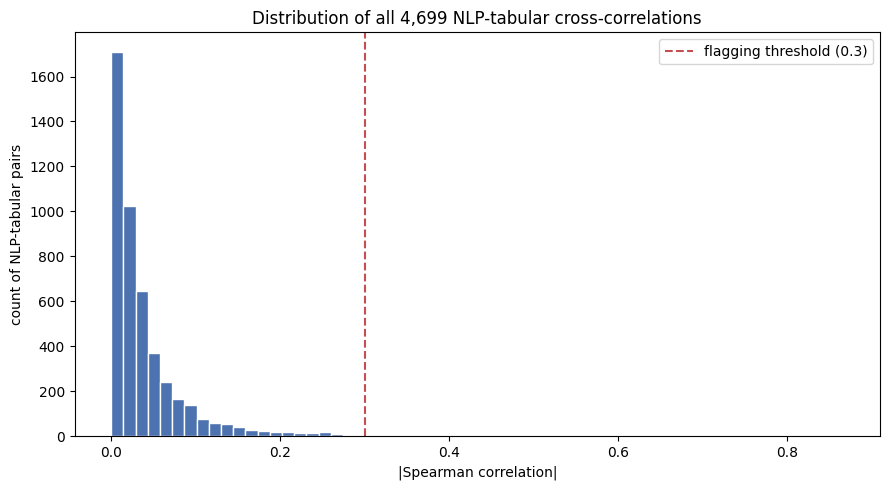

In [136]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(cross_corr_table['spearman_corr'].abs(), bins=60, color='#4c72b0', edgecolor='white')
ax.axvline(CROSS_CORR_THRESHOLD, color='#c44e52', linestyle='--', linewidth=1.5,
           label=f'flagging threshold ({CROSS_CORR_THRESHOLD})')
ax.set_xlabel('|Spearman correlation|')
ax.set_ylabel('count of NLP-tabular pairs')
ax.set_title(f'Distribution of all {len(cross_corr_table):,} NLP-tabular cross-correlations')
ax.legend()
plt.tight_layout()
plt.show()

In [137]:
extended_length_check = listings_nlp[['review_word_count', 'review_sentence_count_log', 'median_review_length']].corr()
display(extended_length_check.round(3))

,review_word_count,review_sentence_count_log,median_review_length
review_word_count,1.000,0.840,0.905
review_sentence_count_log,0.840,1.000,0.742
median_review_length,0.905,0.742,1.000


22 of 4,699 cross-corpus pairs cross the |0.30| threshold.

`review_word_count` and `review_sentence_count_log` correlate with `median_review_length` almost as strongly as the length-cluster variables, and a direct check confirms all three measure the same underlying length at different granularities. `median_review_length` and `review_sentence_count_log` are both kept, `review_word_count` is dropped, as sentence count correlates more weakly with median length and captures how a review is broken up, not just how much content it has.

A substantive limitation: `embedding_pc4` (0.532) and `embedding_pc3` (-0.302) both correlate with `median_review_length`, meaning part of the embedding space encodes how much text a listing's reviews contain, not purely semantic content — consistent with §6's own PCA components carrying no guaranteed clean interpretation, but worth flagging.

The remaining pairs are content-plausible relationships: `review_family_density_log` rising with unit size (`accommodates` 0.481, `beds_log` 0.429, `bedrooms_binned` 0.417, `bathroom_count` 0.321) is a sensible real-world pattern (families book bigger units, and reviews mention it), not two measurements of the same thing. `desc_topic_vatican_museums_weight` vs. `longitude` (-0.400) and `desc_topic_neighborhood_liveliness_weight` vs. `distance_to_center_km_log` (0.322) echo the same kind of independent geographic validation already established for the landmark gazetteer.
`desc_topic_room_type_private_shared_weight` vs. `bath_private_info`/`accommodates` and `desc_topic_multi_bedroom_large_weight` vs. `bedrooms_binned` are the topic model correctly picking up on genuinely related property characteristics. None of these are dropped.

In [138]:
listings_nlp_features = listings_nlp_features.drop(columns=['review_word_count'])
print(f"working frame: {listings_nlp_features.shape[1]} columns")

working frame: 249 columns


#### 7.5.4 Categorical Scan: Nominal Tabular vs. NLP

The ordinal scan deliberately excluded both nominal groups (six tabular categoricals with no natural order and six NLP categoricals (three language fields, three model-derived topic/persona labels)). Spearman correlation is meaningless for either, so this closing check uses Cramér's V, the standard association measure for two nominal categorical variables, computed pairwise across all 36 combinations rather than the thousands scanned for the ordinal side.

,nlp_col,tabular_col,cramers_v
7,host_about_lang,host_neighbourhood,0.382
23,desc_dominant_topic,room_type,0.269
18,desc_dominant_topic,geo_sector,0.254
22,desc_dominant_topic,property_type_grouped,0.207
33,text_persona,neighbourhood_cleansed,0.191
21,desc_dominant_topic,neighbourhood_cleansed,0.149
19,desc_dominant_topic,host_neighbourhood,0.140
13,neighborhood_overview_lang,host_neighbourhood,0.116
29,review_dominant_topic,room_type,0.106
31,text_persona,host_neighbourhood,0.103


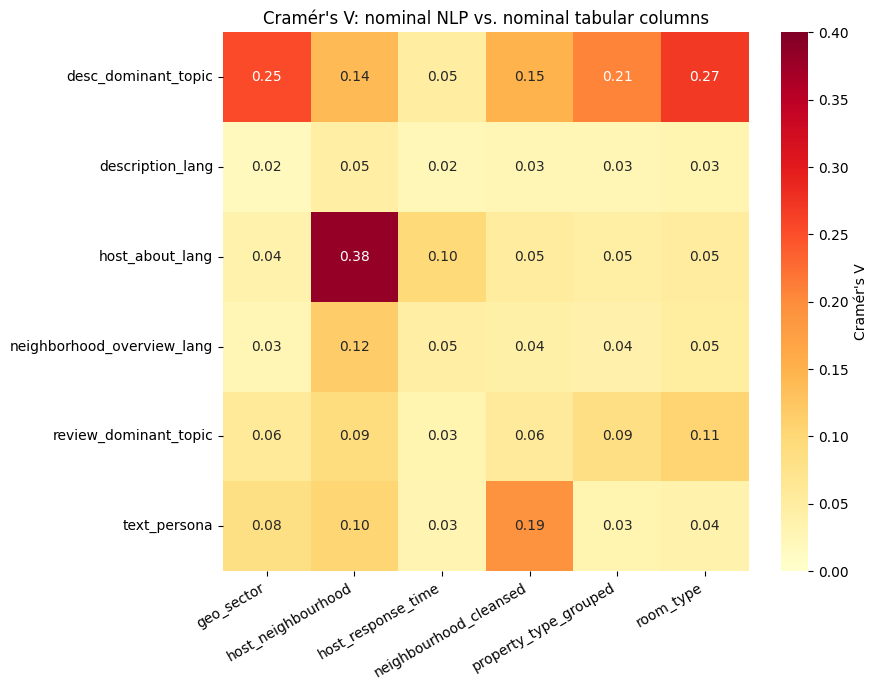

In [139]:
from scipy.stats import chi2_contingency

def cramers_v(col1, col2):
    """Standard association measure for two nominal categoricals, based on the
    chi-squared statistic. 0 = no association, 1 = one variable fully determines
    the other's category. Unlike Spearman, no ordering assumption is made."""
    df = pd.DataFrame({'a': col1, 'b': col2}).dropna()
    if len(df) == 0 or df['a'].nunique() < 2 or df['b'].nunique() < 2:
        return np.nan
    contingency = pd.crosstab(df['a'], df['b'])
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cramers_rows = []
for nlp_col in nlp_nominal_cols:
    for tab_col in tabular_nominal_cols:
        v = cramers_v(listings_nlp_features[nlp_col], listings_nlp_features[tab_col])
        if pd.notna(v):
            cramers_rows.append({'nlp_col': nlp_col, 'tabular_col': tab_col, 'cramers_v': round(v, 3)})

cramers_table = pd.DataFrame(cramers_rows).sort_values('cramers_v', ascending=False)
display(cramers_table)

cramers_matrix = cramers_table.pivot(index='nlp_col', columns='tabular_col', values='cramers_v')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cramers_matrix, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=0.4,
            cbar_kws={'label': "Cramér's V"}, ax=ax)
ax.set_title("Cramér's V: nominal NLP vs. nominal tabular columns")
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

No pair approaches genuine redundancy. The strongest association in the table (Cramér's V=0.382, `host_about_lang` vs. `host_neighbourhood`) is far below the thresholds, so all 36 pairs are kept.

`host_about_lang`↔`host_neighbourhood` is the one substantive finding: the language a host writes their bio in tracks where in Rome they're based, plausibly reflecting how foreign hosts/management companies concentrate in certain neighborhoods versus local Italian hosts in others. These are not the two measurements of the same thing (neighborhood doesn't reveal language, or vice versa, with any reliability at V=0.38).

`desc_dominant_topic` shows the broadest set of moderate associations, occupying 4 of the top 7 pairs (`room_type` 0.269, `geo_sector` 0.254, `property_type_grouped` 0.207, `host_neighbourhood` 0.140). It is expected, since several of its 14 constituent topics (`room_type_private_shared`, `multi_bedroom_large`, `building_character`) are explicitly about physical unit characteristics. This is the topic model correctly recovering structure that tabular features already capture from a different angle.

`text_persona`↔`neighbourhood_cleansed` (0.191) confirms, at a moderate rather than dominant level, the Ostia/Acilia geographic identity already established and validated through neighborhood, distance, and price, consistent with that earlier finding.

### 7.6 Price Sensitivity: The Leak Diagnostic

`price` has been deliberately excluded from every redundancy check and held back specifically for this question: does any feature, NLP or tabular, track price closely enough that feeding it into clusterisation algorithm would mean re-deriving a price-based split rather than finding structure orthogonal to it. Tabular features are checked first, because their correlation strengths set the natural scale NLP's own numbers need to be judged against.

#### 7.6.1 Setup & Scope

In [140]:
price = listings_nlp_features['price']

nlp_final_cols = [c for c in listings_nlp_features.columns
                   if c in classification.index and classification[c].startswith('nlp_candidate')]
nlp_ordinal_cols = [c for c in nlp_final_cols if c not in NLP_NOMINAL_COLS]
nlp_nominal_cols = [c for c in nlp_final_cols if c in NLP_NOMINAL_COLS]

print(f"price: n={price.notna().sum():,}, range=[{price.min():.0f}, {price.max():.0f}], "
      f"median={price.median():.0f}")
print(f"\ntabular ordinal candidates: {len(tabular_ordinal_cols)}")
print(f"tabular nominal candidates: {len(tabular_nominal_cols)}")
print(f"NLP ordinal candidates: {len(nlp_ordinal_cols)}")
print(f"NLP nominal candidates: {len(nlp_nominal_cols)}")

price: n=32,081, range=[8, 1005], median=131

tabular ordinal candidates: 43
tabular nominal candidates: 6
NLP ordinal candidates: 110
NLP nominal candidates: 6


#### 7.6.2 Tabular Baseline

,column,spearman_corr
15,distance_to_center_km_log,-0.587
0,accommodates,0.414
9,bathroom_count,0.375
11,bedrooms_binned,0.373
12,beds_log,0.309
8,bath_shared_info,-0.213
33,instant_bookable,0.210
36,latitude,0.209
14,calculated_host_listings_count_log,0.196
24,host_acceptance_rate_binned,0.129


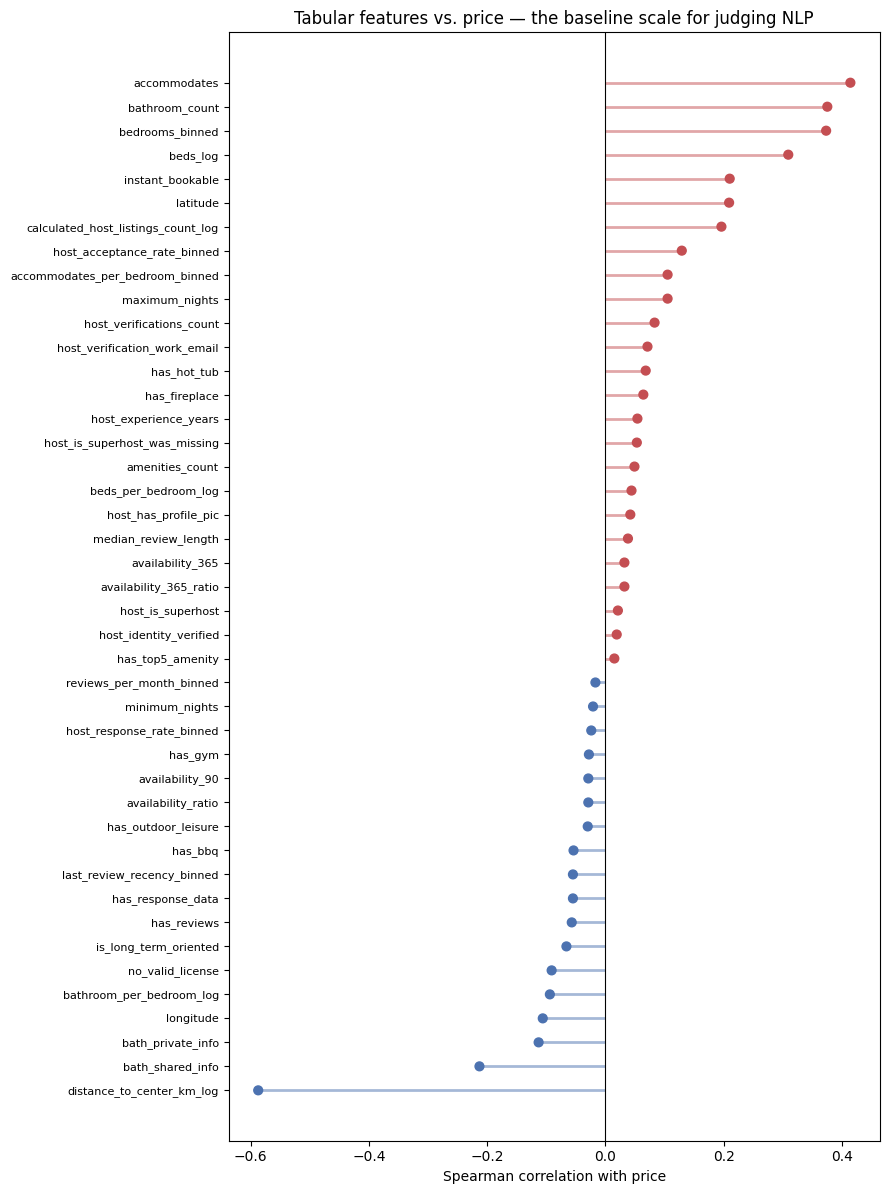

In [141]:
tabular_price_rows = []
for col in tabular_ordinal_cols:
    s = to_ordinal(listings_nlp_features[col])
    corr = s.corr(price, method='spearman')
    if pd.notna(corr):
        tabular_price_rows.append({'column': col, 'spearman_corr': round(corr, 3)})

tabular_price_corr = pd.DataFrame(tabular_price_rows).sort_values('spearman_corr', key=abs, ascending=False)
display(tabular_price_corr)

plot_data = tabular_price_corr.sort_values('spearman_corr')
colors = ['#c44e52' if v > 0 else '#4c72b0' for v in plot_data['spearman_corr']]

fig, ax = plt.subplots(figsize=(9, max(6, len(plot_data) * 0.28)))
ax.hlines(y=range(len(plot_data)), xmin=0, xmax=plot_data['spearman_corr'], color=colors, alpha=0.5, linewidth=2)
ax.scatter(plot_data['spearman_corr'], range(len(plot_data)), color=colors, s=40, zorder=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data['column'], fontsize=8)
ax.set_xlabel('Spearman correlation with price')
ax.set_title('Tabular features vs. price — the baseline scale for judging NLP')
plt.tight_layout()
plt.show()

`distance_to_center_km_log` sets the ceiling at -0.587, the strongest tabular correlate with price by a clear margin, an expected reflection of central-Rome location premiums. A second tier clusters around unit size (`accommodates` 0.414, `bathroom_count` 0.375, `bedrooms_binned` 0.373, `beds_log` 0.309), equally unsurprising: larger units cost more. Everything else sits below |0.22|, a long tail of weak or negligible associations (amenity flags, host verification, availability).

This sets the scale the NLP block needs to be judged against: even the most direct, physical price determinants in this dataset don't exceed 0.6. If any NLP feature approaches or exceeds that level, it's a genuine signal worth scrutinizing, not an assumed-benign moderate correlation.

#### 7.6.3 NLP Ordinal/Continuous Block

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


strongest NLP-price correlation: embedding_pc1 (0.399) vs. tabular ceiling of -0.587


,column,spearman_corr
98,embedding_pc1,0.399
104,embedding_pc7,-0.307
75,review_family_density_log,0.294
102,embedding_pc5,0.290
92,desc_topic_neighborhood_liveliness_weight,-0.269
62,review_we_ref_density_log,0.267
95,desc_topic_termini_train_airport_weight,-0.247
14,review_readability,-0.242
93,desc_topic_piazza_spagna_trevi_weight,0.211
66,description_luxury_density_log,0.204


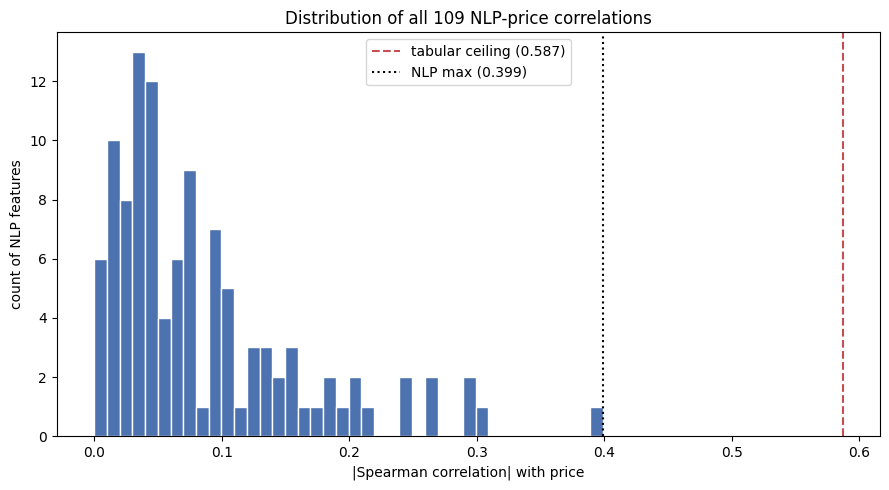

In [142]:
nlp_price_rows = []
for col in nlp_ordinal_cols:
    s = to_ordinal(listings_nlp_features[col])
    corr = s.corr(price, method='spearman')
    if pd.notna(corr):
        nlp_price_rows.append({'column': col, 'spearman_corr': round(corr, 3)})

nlp_price_corr = pd.DataFrame(nlp_price_rows).sort_values('spearman_corr', key=abs, ascending=False)
print(f"strongest NLP-price correlation: {nlp_price_corr.iloc[0]['column']} "
      f"({nlp_price_corr.iloc[0]['spearman_corr']}) vs. tabular ceiling of -0.587")
display(nlp_price_corr.head(20))

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(nlp_price_corr['spearman_corr'].abs(), bins=40, color='#4c72b0', edgecolor='white')
ax.axvline(0.587, color='#c44e52', linestyle='--', linewidth=1.5, label='tabular ceiling (0.587)')
ax.axvline(nlp_price_corr['spearman_corr'].abs().max(), color='black', linestyle=':', linewidth=1.5,
           label=f"NLP max ({nlp_price_corr['spearman_corr'].abs().max():.3f})")
ax.set_xlabel('|Spearman correlation| with price')
ax.set_ylabel('count of NLP features')
ax.set_title(f'Distribution of all {len(nlp_price_corr)} NLP-price correlations')
ax.legend()
plt.tight_layout()
plt.show()

The NLP block's overall shape is reassuring: most correlations cluster near zero, with a thin, sparse tail extending out to the maximum. That maximum (`embedding_pc1` at 0.399) sits meaningfully below the tabular ceiling, and no NLP variable approaches a level anywhere near what would constitute a leak.

Two embedding components (`embedding_pc1` 0.399, `embedding_pc7` -0.307) extend the same limitation already flagged previously: part of the PCA space tracks price-adjacent structure, consistent with the earlier `median_review_length` finding for `embedding_pc3`/`pc4`. `review_family_density_log` plausibly inherits its price correlation transitively through unit size, the same relationship already established before (families in bigger units), rather than reflecting a direct price signal in the text itself. The description-topic pairs at the top of the list (`piazza_spagna_trevi`, `termini_train_airport`) echo the same center/periphery price gradient already established for `distance_to_center_km_log`, seen here through what hosts choose to write about rather than raw geography.

#### 7.6.4 Categorical Block: Correlation Ratio

Both nominal groups (6 tabular, 6 NLP) need a different measure than Spearman here: price is continuous, but these columns have no natural order, so what's needed is correlation ratio η, the share of price's variance explained by category membership. η ranges 0 (no association) to 1 (group membership fully determines price), the same logic as Cramér's V but for a categorical-vs-continuous pair rather than categorical-vs-categorical.

In [143]:
def correlation_ratio(categories, values):
    """Eta: share of a continuous variable's variance explained by group
    membership in a categorical variable. 0 = no association, 1 = group
    membership fully determines the value."""
    df = pd.DataFrame({'cat': categories, 'val': values}).dropna()
    if df['cat'].nunique() < 2:
        return np.nan
    overall_mean = df['val'].mean()
    ss_between = df.groupby('cat', observed=True)['val'].apply(lambda g: len(g) * (g.mean() - overall_mean) ** 2).sum()
    ss_total = ((df['val'] - overall_mean) ** 2).sum()
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else np.nan

eta_rows = []
for col in tabular_nominal_cols:
    eta = correlation_ratio(listings_nlp_features[col], price)
    eta_rows.append({'column': col, 'source': 'tabular', 'eta': round(eta, 3)})
for col in nlp_nominal_cols:
    eta = correlation_ratio(listings_nlp_features[col], price)
    eta_rows.append({'column': col, 'source': 'NLP', 'eta': round(eta, 3)})

eta_table = pd.DataFrame(eta_rows).sort_values('eta', ascending=False)
display(eta_table)

,column,source,eta
3,neighbourhood_cleansed,tabular,0.382
1,host_neighbourhood,tabular,0.281
9,desc_dominant_topic,NLP,0.260
0,geo_sector,tabular,0.244
4,property_type_grouped,tabular,0.161
5,room_type,tabular,0.151
10,review_dominant_topic,NLP,0.140
7,host_about_lang,NLP,0.096
2,host_response_time,tabular,0.074
11,text_persona,NLP,0.046


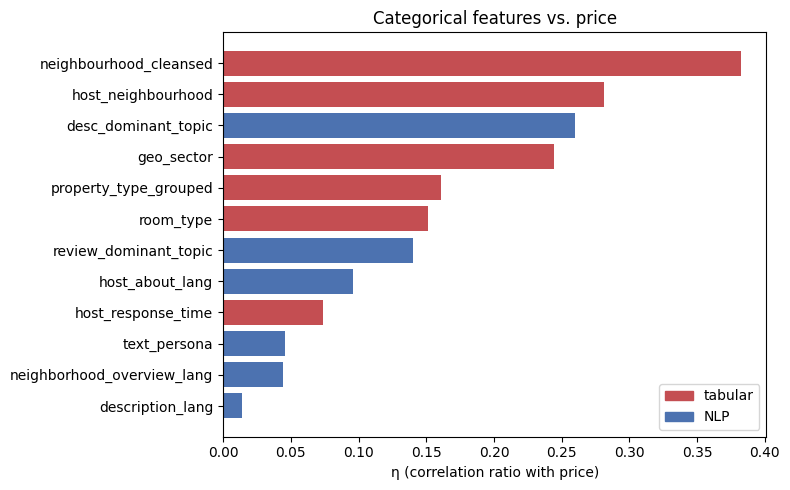

In [144]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#c44e52' if s == 'tabular' else '#4c72b0' for s in eta_table['source']]
ax.barh(eta_table['column'], eta_table['eta'], color=colors)
ax.set_xlabel('η (correlation ratio with price)')
ax.set_title('Categorical features vs. price')
ax.legend(handles=[Patch(color='#c44e52', label='tabular'), Patch(color='#4c72b0', label='NLP')],
          loc='lower right')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

`desc_dominant_topic` is the strongest NLP categorical association with price and third overall behind `neighbourhood_cleansed` and `host_neighbourhood`, ahead of `geo_sector`, `property_type_grouped`, and `room_type`. This extends the same pattern already seen in Cramér's V results: several of its 14 constituent topics code for both unit characteristics and location, both of which drive price. The topic model correctly recovering structure that several tabular features already capture from different angles.

`text_persona` looks at odds with §6.6's price finding (Ostia/Acilia 25% below corpus median), but the two aren't in tension. η measures variance explained *across all categories at once*, while the Ostia effect is concentrated in one small cluster. The large majority (`persona_6`, 82.8% of listings) doesn't deviate from baseline price at all, which pulls the aggregate η down even though the Ostia-specific relationship remains real and strong.

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_19198/3277422563.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=listings_nlp_features, x='desc_dominant_topic', y='price', order=order1, ax=axes[0], showfliers=False, palette='viridis')
/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_19198/3277422563.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=listings_nlp_features, x='text_persona', y='price', order=order2, ax=axes[1], showfliers=False, palette='magma')


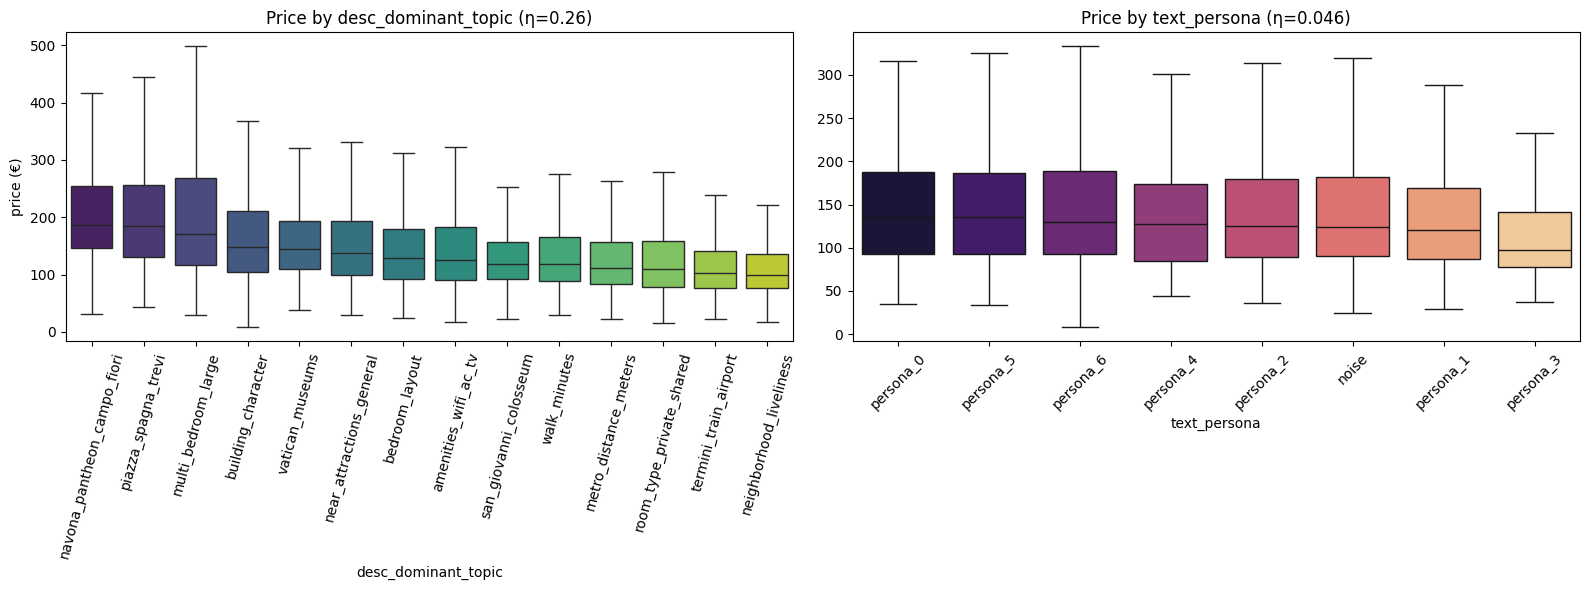

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order1 = listings_nlp_features.groupby('desc_dominant_topic', observed=True)['price'].median().sort_values(ascending=False).index
sns.boxplot(data=listings_nlp_features, x='desc_dominant_topic', y='price', order=order1, ax=axes[0], showfliers=False, palette='viridis')
axes[0].set_title(f'Price by desc_dominant_topic (η={eta_table.set_index("column").loc["desc_dominant_topic","eta"]})')
axes[0].tick_params(axis='x', rotation=75)
axes[0].set_ylabel('price (€)')

order2 = listings_nlp_features.groupby('text_persona', observed=True)['price'].median().sort_values(ascending=False).index
sns.boxplot(data=listings_nlp_features, x='text_persona', y='price', order=order2, ax=axes[1], showfliers=False, palette='magma')
axes[1].set_title(f'Price by text_persona (η={eta_table.set_index("column").loc["text_persona","eta"]})')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

The `desc_dominant_topic` boxplot visually confirms the dual mechanism behind its η=0.26: the top price tier mixes genuinely different kinds of theme. `navona_pantheon_campo_fiori` and `piazza_spagna_trevi` are pure location topics (central, prestige neighborhoods), while `multi_bedroom_large`, sitting right alongside them at a comparable median, is a pure unit-size topic with no geographic content at all. The association isn't one clean mechanism. It's two independent price drivers (location and size) both leaking into which topic a description's NMF weights land on.

#### 7.6.5 Cross-Check: NLP vs. Tabular Leak Profiles

In [146]:
LEAK_THRESHOLD = 0.50 

leak_summary = pd.DataFrame([
    {
        'group': 'Tabular (ordinal)',
        'n': len(tabular_price_corr),
        'median_abs': tabular_price_corr['spearman_corr'].abs().median(),
        'max_abs': tabular_price_corr['spearman_corr'].abs().max(),
        'pct_above_threshold': (tabular_price_corr['spearman_corr'].abs() >= LEAK_THRESHOLD).mean() * 100,
    },
    {
        'group': 'NLP (ordinal)',
        'n': len(nlp_price_corr),
        'median_abs': nlp_price_corr['spearman_corr'].abs().median(),
        'max_abs': nlp_price_corr['spearman_corr'].abs().max(),
        'pct_above_threshold': (nlp_price_corr['spearman_corr'].abs() >= LEAK_THRESHOLD).mean() * 100,
    },
    {
        'group': 'Tabular (nominal, η)',
        'n': (eta_table['source'] == 'tabular').sum(),
        'median_abs': eta_table.loc[eta_table['source'] == 'tabular', 'eta'].median(),
        'max_abs': eta_table.loc[eta_table['source'] == 'tabular', 'eta'].max(),
        'pct_above_threshold': (eta_table.loc[eta_table['source'] == 'tabular', 'eta'] >= LEAK_THRESHOLD).mean() * 100,
    },
    {
        'group': 'NLP (nominal, η)',
        'n': (eta_table['source'] == 'NLP').sum(),
        'median_abs': eta_table.loc[eta_table['source'] == 'NLP', 'eta'].median(),
        'max_abs': eta_table.loc[eta_table['source'] == 'NLP', 'eta'].max(),
        'pct_above_threshold': (eta_table.loc[eta_table['source'] == 'NLP', 'eta'] >= LEAK_THRESHOLD).mean() * 100,
    },
]).round(3)

display(leak_summary)

,group,n,median_abs,max_abs,pct_above_threshold
0,Tabular (ordinal),43,0.057,0.587,2.326
1,NLP (ordinal),109,0.061,0.399,0.000
2,"Tabular (nominal, η)",6,0.202,0.382,0.000
3,"NLP (nominal, η)",6,0.071,0.260,0.000


/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_19198/107038371.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dist_data, labels=labels, patch_artist=True, showmeans=True,


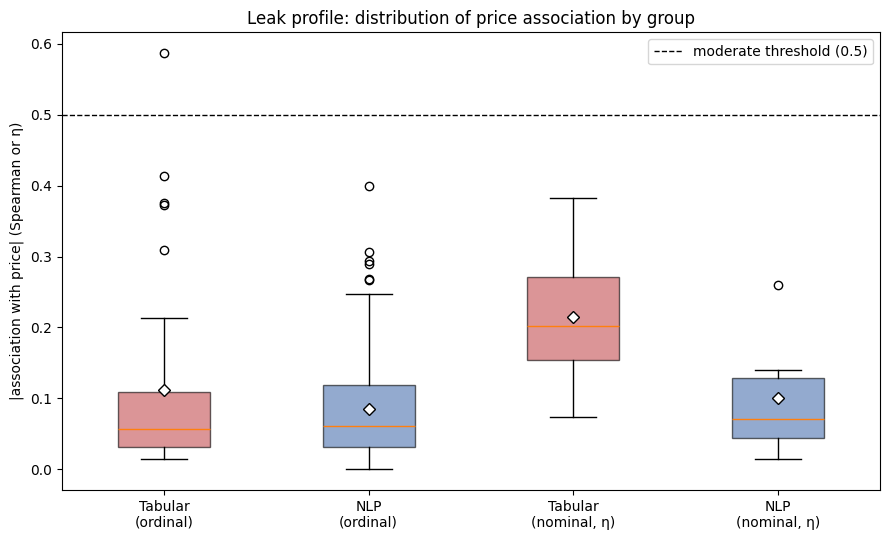

In [147]:
fig, ax = plt.subplots(figsize=(9, 5.5))

dist_data = [
    tabular_price_corr['spearman_corr'].abs().values,
    nlp_price_corr['spearman_corr'].abs().values,
    eta_table.loc[eta_table['source'] == 'tabular', 'eta'].values,
    eta_table.loc[eta_table['source'] == 'NLP', 'eta'].values,
]
labels = ['Tabular\n(ordinal)', 'NLP\n(ordinal)', 'Tabular\n(nominal, η)', 'NLP\n(nominal, η)']
colors = ['#c44e52', '#4c72b0', '#c44e52', '#4c72b0']

bp = ax.boxplot(dist_data, labels=labels, patch_artist=True, showmeans=True,
                 meanprops={'marker': 'D', 'markerfacecolor': 'white', 'markeredgecolor': 'black', 'markersize': 6})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.axhline(LEAK_THRESHOLD, color='black', linestyle='--', linewidth=1, label=f'moderate threshold ({LEAK_THRESHOLD})')
ax.set_ylabel('|association with price| (Spearman or η)')
ax.set_title('Leak profile: distribution of price association by group')
ax.legend()
plt.tight_layout()
plt.show()

At the threshold 0.50 only one variable in the entire dataset crosses it: `distance_to_center_km_log` (2.3% of the tabular ordinal group). No NLP variable, ordinal or nominal, comes close.

The ordinal boxplots don't show what might be expected (NLP sitting uniformly lower and tighter than tabular). Median association is nearly identical between the two, and interquartile spread is comparable. The real difference is in the tail: tabular has five variables in the 0.31-0.59 range (`distance_to_center_km_log`, `accommodates`, `bathroom_count`, `bedrooms_binned`, `beds_log`), which are direct, physical price determinants. NLP has only one comparable outlier (`embedding_pc1`, 0.399). The typical NLP feature is no less price-associated than the typical tabular one. There just isn't an NLP equivalent to the handful of strong, direct predictors physical characteristics provide.

The nominal side shows a clearer, genuine gap: tabular categorical median η (0.202) sits nearly three times NLP's (0.071), visible directly in the boxes' relative position. Tabular categoricals (neighborhood, geo-sector, property type) track price far more centrally than NLP categoricals typically do. `desc_dominant_topic`'s 0.260 is the one NLP exception, already explained previously.

#### 7.6.6 Price Leak Conclusion

No leak. Across 4,699 ordinal pairs and 12 categorical comparisons, the strongest NLP-price association anywhere is 0.399 (`embedding_pc1`), comfortably below the tabular ceiling of 0.587. Where NLP features do track price moderately, each traces to an identified, sensible mechanism: `embedding_pc1`/`pc7` inherit the length-adjacent PCA limitation, `review_family_density_log` transmits price association transitively through unit size, and `desc_dominant_topic` mixes two legitimate price drivers (location and size) within its 14 constituent themes. The full NLP feature set proceeds to final assembly unchanged by this diagnostic and nothing is dropped on price-leak grounds.

### 7.7 Final Feature Set Assembly

#### 7.7.1 Final Inventory

In [155]:
leaked_scaffolding = [c for c in listings_nlp_features.columns
                       if c in scaffolding_cols or c in source_text_cols]
listings_nlp_features = listings_nlp_features.drop(columns=leaked_scaffolding)

final feature set: 206 columns

nlp_candidate (stylometry/lexicon)    105
tabular                                53
nlp_candidate (model-based)            46
identifier/target                       2
Name: count, dtype: int64


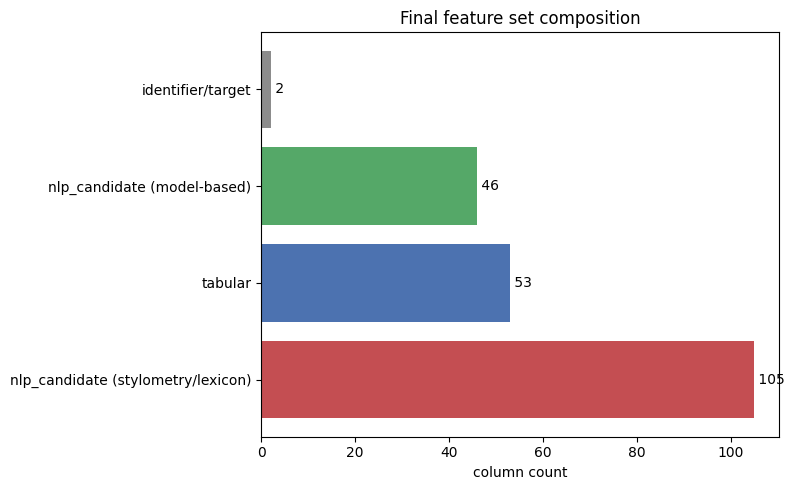

In [156]:
# classify every surviving column
def classify_final_column(col):
    if col in ('id', 'price'):
        return 'identifier/target'
    if col in {'is_all_positive_sentiment', 'has_no_neutral_sentiment'}: 
        return 'nlp_candidate (model-based)'
    if col in NLP_MODEL_EXPLICIT or col.startswith(NLP_MODEL_PREFIXES):
        return 'nlp_candidate (model-based)'
    if col in MISSINGNESS_FLAGS or col.startswith(NLP_HAS_FLAG_PREFIXES) or col.startswith(NLP_TEXT_PREFIXES):
        return 'nlp_candidate (stylometry/lexicon)'
    return 'tabular'

final_categories = pd.Series({col: classify_final_column(col) for col in listings_nlp_features.columns})
print(f"final feature set: {listings_nlp_features.shape[1]} columns\n")
print(final_categories.value_counts())

fig, ax = plt.subplots(figsize=(8, 5))
counts = final_categories.value_counts()
ax.barh(counts.index, counts.values, color=['#c44e52', '#4c72b0', '#55a868', '#8c8c8c'][:len(counts)])
for i, v in enumerate(counts.values):
    ax.text(v, i, f' {v}', va='center', fontsize=10)
ax.set_xlabel('column count')
ax.set_title('Final feature set composition')
plt.tight_layout()
plt.show()

206 columns survive to the final set: 151 NLP candidates (105 stylometry/lexicon, 46 model-based), 53 tabular, and the 2 identifier/target columns (`id`, `price`) carried through for the modeling stage.

#### 7.7.2 Completeness Check & Open Items

In [157]:
# a last missingness check
null_pct = listings_nlp_features.isna().mean().mul(100).sort_values(ascending=False)
print(f"columns with >0% missing: {(null_pct > 0).sum()} / {listings_nlp_features.shape[1]}")
display(null_pct[null_pct > 0].to_frame('pct_missing'))

missingness_by_cat = pd.DataFrame({'pct_missing': null_pct, 'category': final_categories})

columns with >0% missing: 134 / 206


,pct_missing
host_about_mtld_log,65.106929
host_about_readability,60.260204
neighborhood_overview_mtld_log,57.577196
has_host_about_romantic,57.342677
has_host_about_luxury,57.342677
host_about_family_density_binned,57.342677
host_about_direct_address_density_log,57.342677
has_host_about_professionalism,57.342677
has_host_about_atmosphere_lively,57.342677
has_host_about_budget,57.342677


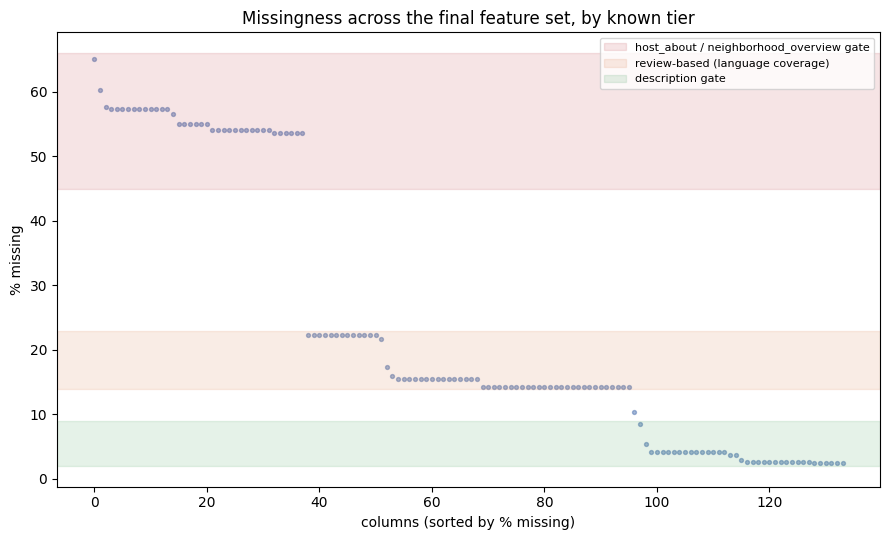

In [151]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sorted_null = null_pct[null_pct > 0].sort_values(ascending=False)
ax.scatter(range(len(sorted_null)), sorted_null.values, s=8, alpha=0.5, color='#4c72b0')

# annotate the known missingness tiers directly
tier_bands = [(45, 66, '#c44e52', 'host_about / neighborhood_overview gate'),
              (14, 23, '#dd8452', 'review-based (language coverage)'),
              (2, 9, '#55a868', 'description gate')]
for low, high, color, label in tier_bands:
    ax.axhspan(low, high, alpha=0.15, color=color, label=label)

ax.set_xlabel('columns (sorted by % missing)')
ax.set_ylabel('% missing')
ax.set_title('Missingness across the final feature set, by known tier')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

Missingness now traces cleanly to three already-documented causes, in descending order of magnitude: `host_about`/`neighborhood_overview` stylometry (45-65% missing, gated by whether a host filled in that field at all), review-based model outputs — sentiment, topics, embeddings (14-22%, the language-coverage combinations mapped previously), and `description`-based features (3-9%, the smallest gap, since `description` is filled for 97.5% of listings). No column's missingness is unexplained.

These gaps aren't handled here, as which algorithm the modeling stage uses, and what it expects from missing values, isn't decided yet, so imputing or dropping rows now would be premature. What matters at this point is that every missing value's origin is known and traceable to a specific cause. `price` (10.4% missing) sits outside all three tiers for the same reason, as it's not an NLP-coverage artifact, and its gaps stem from whatever caused it to be unrecorded for those listings in the original scrape.

In [152]:
# save listings dataset
listings_nlp_features.to_csv(BASE_PATH / 'data' / 'processed' / 'listings_nlp.csv')

In [154]:
# save reviews dataset
reviews_final = reviews_sampled[[
    'listing_id', 'review_lang', 'date', 'comments_clean',
    'sentiment_star_score', 'sentiment_category', 'sentiment_lang_covered',
]].copy()
reviews_final['review_index'] = reviews_sampled.index

dominant_topic_map = reviews_en.set_index(reviews_en.index)['dominant_topic'] if 'dominant_topic' in reviews_en.columns else None
if dominant_topic_map is not None:
    reviews_final['review_dominant_topic'] = reviews_final.index.map(
        lambda i: dominant_topic_map.get(i, np.nan) if i in reviews_en.index else np.nan
    )

reviews_final.to_csv(BASE_PATH / 'data' / 'processed' / 'reviews_nlp.csv')

### 7.8 Full NLP Feature Set Conclusion

This section closed every loop, working through five stages:

- **Inventory & missingness**: the full NLP candidate registry was assembled from column-naming conventions, separating 204 genuine feature candidates from scaffolding and raw source text. Joint coverage across all four model-based methods (sentiment, review topics, description topics, embeddings) was mapped for the first time, showing 75.5% of listings carry a complete profile, with every partial-coverage combination tracing to a specific, language-driven cause.

- **Zero-inflation & skew audit**: model-based features, never formally audited before, went through the same empirical process as Part 1's stylometry block. log1p checked directly with visual inspection catching cases where a numeric skew improvement masked an unresolved zero-spike, overriding the formal threshold where the two disagreed.

- **Redundancy, within and against tabular**: mechanical raw/derived pairs (84 families) were resolved by keeping the transformed version everywhere. Substantive overlaps across independently-built methods were checked directly, catching two genuine near-duplicates (a length-measurement cluster, a paired review-count metric) among mostly-orthogonal signal. A systematic scan against the full tabular feature set, split by variable type and using the appropriate association measure for each (Spearman for ordinal, Cramér's V and correlation ratio for nominal), found every flagged pair traced to a sensible, named mechanism.

- **Price-leak diagnostic**: `price` showed no NLP feature approaching the tabular block's own strongest predictors. The highest NLP-price association anywhere (0.399) sat well below the tabular ceiling (0.587), and every moderate association traced to an identified, non-leaking mechanism.

The result is a feature set whose provenance is fully accounted for: no redundant signal, no unexplained missingness and no price leak.

## 8. Summary

This notebook asked one question three different ways: does the text hosts and guests write carry structure the tabular feature set can't already see?

**Sentiment analysis** found the numeric rating's ceiling effect was hiding real variation. Text sentiment kept separating listings the star rating had already flattened to identical.

**Topic modeling**, run separately on host descriptions and guest reviews, recovered genuine content, confirmed by an independent geographic ground truth built entirely without reference to the topics themselves.

**Multilingual embeddings**, free of every language restriction the earlier methods carried, surfaced one small but real sub-market, a coastal district identifiable from review text alone, later confirmed economically through price.

None of these findings were taken at face value. Each method was validated on its own terms as it was built, and the final section held the entire feature set to a harder standard still: checked for redundancy against itself and against everything built in Part 1 and at the Feature Engineering stage, screened for whether any of it was secretly just re-deriving price, and assembled only once every open question had an answer.